# Projet Deep Learning — Reconnaissance d'expressions faciales

Notebook complet du projet : les neuf parties dans l'ordre de l'énoncé.

| Partie | Contenu | Durée (GPU T4) |
|---|---|---|
| 1 | Recherche, compréhension et préparation des données | ≈ 3 min |
| 2 | Modèle de référence (réseau dense) | ≈ 3 min |
| 3 | Construction d'un CNN avec Keras | < 1 min |
| 4 | Entraînement du réseau | ≈ 5 min |
| 5 | Évaluation et analyse des erreurs | < 1 min |
| 6 | Expérimentation et amélioration | ≈ 30–45 min |
| 7 | Enrichissement : Transfer Learning et régularisation | ≈ 30–40 min |
| 8 | Extension : détection de plusieurs visages (YOLO) | ≈ 1 min |
| 9 | Extension à la vidéo | ≈ 1–3 min |

**Exécution**
- Colab : `Exécution > Modifier le type d'exécution > GPU (T4)`, puis `Exécution > Tout exécuter`.
- Durée totale ≈ 1 h 30 à 2 h, surtout due aux Parties 6 et 7.
- Avant chaque partie, une cellule **libère la mémoire** (sinon la RAM de Colab sature et la session plante).
- Chaque partie **sauvegarde ses résultats dans Google Drive** (`MyDrive/projet_dl/`) et la suivante les relit.
  Conséquence pratique : si Colab se déconnecte, il suffit de **relancer à partir de la partie interrompue**
  (cliquer sur la cellule « Libère la mémoire » de cette partie, puis `Exécution > Exécuter après`) ; les parties déjà faites n'ont pas à être refaites.
  La Partie 6 reprend même automatiquement là où elle s'était arrêtée.
- **Le notebook s'arrête volontairement après la Partie 7** : il faut redémarrer la session avant les Parties 8–9
  (YOLO et TensorFlow ne peuvent pas tourner ensemble). Les instructions sont juste avant la Partie 8.
- Pour la démonstration : déposer des photos dans `MyDrive/projet_dl/images_test/` (Partie 8) et des vidéos dans
  `MyDrive/projet_dl/videos_test/` (Partie 9) avant d'exécuter ces parties.


---
## Partie 1 — Recherche, compréhension et préparation des données

**Objectif de cette partie :** choisir un jeu de données public d'expressions faciales, le décrire précisément
(source, classes, volumes, dimensions, format, déséquilibre), visualiser des exemples, puis préparer les données
pour l'entraînement (normalisation, encodage des labels, découpage train / validation / test).

> ⚙️ Exécuter dans Google Colab : `Exécution > Tout exécuter`. Un GPU n'est pas nécessaire pour cette partie.

### 1.0 Configuration et imports

On fixe une **graine aléatoire** (`SEED`) pour que le découpage train/validation et les exemples affichés soient
**reproductibles** : relancer le notebook donne exactement les mêmes résultats.

In [1]:
import os, glob, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 48          # taille d'entrée retenue pour le CNN (taille native de FER-2013)
VAL_RATIO = 0.15       # part du train réservée à la validation

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

### 1.1 Choix du jeu de données : FER-2013

Nous avons comparé plusieurs datasets publics d'expressions faciales :

| Dataset | Images | Classes | Format | Accès |
|---|---|---|---|---|
| **FER-2013** | ≈ 35 900 | 7 | 48×48, niveaux de gris | Libre (Kaggle) |
| CK+ | ≈ 600 séquences | 7–8 | 640×490, posé en laboratoire | Sur demande |
| RAF-DB | ≈ 15 000 | 7 | 100×100, couleur | Sur demande (accord de licence) |
| AffectNet | ≈ 400 000 | 8 | Couleur, taille variable | Sur demande, très volumineux |

**Choix : FER-2013**, pour les raisons suivantes :
- accès immédiat et libre, téléchargement direct dans Colab ;
- volume suffisant pour entraîner un CNN depuis zéro (≈ 36 000 images) ;
- visages **déjà extraits, centrés et recadrés** : correspond exactement au point de départ du projet
  (« visage déjà extrait → CNN → expression ») ;
- images petites (48×48, niveaux de gris) : entraînement rapide sur le GPU gratuit de Colab ;
- les 7 classes correspondent aux 7 émotions de l'énoncé ;
- dataset de référence : nos résultats pourront être comparés à la littérature (précision humaine ≈ 65 %).

**Source**
- Créé par **Pierre-Luc Carrier et Aaron Courville** pour la compétition Kaggle
  *« Challenges in Representation Learning: Facial Expression Recognition Challenge »* (ICML 2013).
- Référence : I. Goodfellow *et al.*, *Challenges in Representation Learning: A report on three machine learning contests*, 2013.
- Version utilisée : réorganisation en dossiers d'images publiée sur Kaggle :
  https://www.kaggle.com/datasets/msambare/fer2013

**Limites connues** (utiles pour l'analyse d'erreurs de la Partie 5) : images collectées automatiquement via
Google Images, donc **labels bruités** (certaines images mal étiquetées, quelques images sans visage),
faible résolution, variations de pose, d'éclairage, d'âge et d'occlusion (mains, lunettes).

### 1.2 Téléchargement du dataset

On utilise `kagglehub` (préinstallé dans Colab), qui télécharge les datasets Kaggle publics sans configuration.
Les fichiers sont organisés ainsi :
```
fer2013/
├── train/  angry/ disgust/ fear/ happy/ neutral/ sad/ surprise/
└── test/   angry/ disgust/ fear/ happy/ neutral/ sad/ surprise/
```
*Si le téléchargement échoue : télécharger le zip depuis Kaggle, le déposer dans Colab, le décompresser
et renseigner son chemin dans la variable d'environnement `FER_DIR`.*

In [2]:
def find_root(path):
    # Renvoie le dossier qui contient à la fois train/ et test/
    for root, dirs, _ in os.walk(path):
        if "train" in dirs and "test" in dirs:
            return root
    raise FileNotFoundError(f"Aucun dossier train/ + test/ trouvé dans {path}")

if os.environ.get("FER_DIR"):                  # chemin local fourni manuellement
    DATA_DIR = find_root(os.environ["FER_DIR"])
else:
    import kagglehub
    DATA_DIR = find_root(kagglehub.dataset_download("msambare/fer2013"))

print("Dossier du dataset :", DATA_DIR)
print("Contenu :", sorted(os.listdir(DATA_DIR)))

Using Colab cache for faster access to the 'fer2013' dataset.
Dossier du dataset : /kaggle/input/fer2013
Contenu : ['test', 'train']


### 1.3 Inventaire : nombre d'images, classes, répartition

On parcourt les dossiers pour construire un tableau `(chemin, classe, split)` : le nom du sous-dossier
**est** le label de l'image.

In [ ]:
EXTS = (".jpg", ".jpeg", ".png")
records = []
for split in ["train", "test"]:
    for cls in sorted(os.listdir(os.path.join(DATA_DIR, split))):
        cls_dir = os.path.join(DATA_DIR, split, cls)
        if not os.path.isdir(cls_dir):
            continue
        for f in os.listdir(cls_dir):
            if f.lower().endswith(EXTS):
                records.append((os.path.join(cls_dir, f), cls, split))

df = pd.DataFrame(records, columns=["path", "label", "split"])
CLASSES = sorted(df["label"].unique())
NUM_CLASSES = len(CLASSES)

print(f"Nombre total d'images : {len(df):,}".replace(",", " "))
print(f"Nombre de classes     : {NUM_CLASSES} -> {CLASSES}")

counts = df.pivot_table(index="label", columns="split", aggfunc="size", fill_value=0)[["train", "test"]]
counts["total"] = counts.sum(axis=1)
counts["% du total"] = (100 * counts["total"] / counts["total"].sum()).round(1)
counts.loc["TOTAL"] = counts.sum(numeric_only=True)
counts.loc["TOTAL", "% du total"] = 100.0
counts

Nombre total d'images : 35 887
Nombre de classes     : 7 -> ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


split,train,test,total,% du total
label,,,,
angry,3995.0,958.0,4953.0,13.8
disgust,436.0,111.0,547.0,1.5
fear,4097.0,1024.0,5121.0,14.3
happy,7215.0,1774.0,8989.0,25.0
neutral,4965.0,1233.0,6198.0,17.3
sad,4830.0,1247.0,6077.0,16.9
surprise,3171.0,831.0,4002.0,11.2
TOTAL,28709.0,7178.0,35887.0,100.0


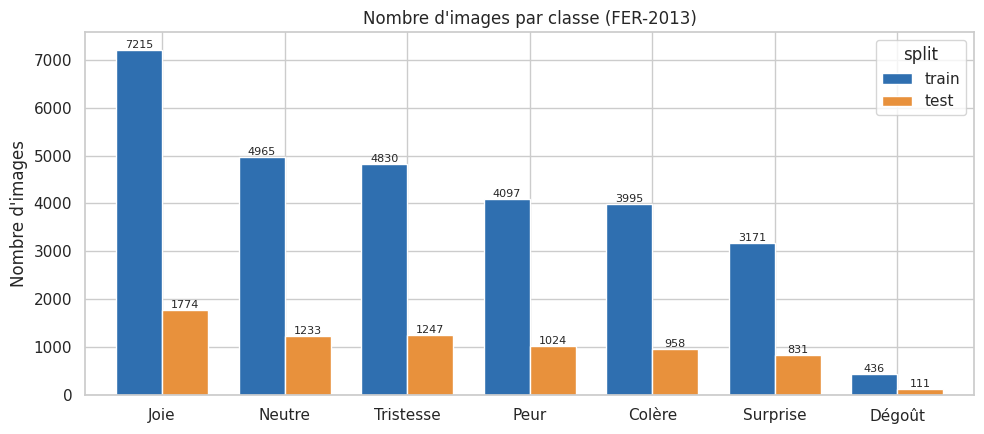

In [ ]:
# Traduction française des classes, utilisée pour tous les affichages
FR = {"angry": "Colère", "disgust": "Dégoût", "fear": "Peur", "happy": "Joie",
      "neutral": "Neutre", "sad": "Tristesse", "surprise": "Surprise"}
fr = lambda c: FR.get(c, c)

c = counts.drop("TOTAL")[["train", "test"]].sort_values("train", ascending=False)
ax = c.rename(index=fr).plot(kind="bar", figsize=(10, 4.5), color=["#2f6fb0", "#e8913c"], width=0.75)
ax.set_title("Nombre d'images par classe (FER-2013)")
ax.set_xlabel(""); ax.set_ylabel("Nombre d'images")
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

### 1.4 Analyse du déséquilibre entre les classes

On mesure le **ratio de déséquilibre** : effectif de la classe majoritaire / effectif de la classe minoritaire.

In [ ]:
train_counts = df[df.split == "train"]["label"].value_counts()
maj, mino = train_counts.idxmax(), train_counts.idxmin()
print(f"Classe majoritaire : {fr(maj)} ({train_counts[maj]} images)")
print(f"Classe minoritaire : {fr(mino)} ({train_counts[mino]} images)")
print(f"Ratio de déséquilibre : {train_counts[maj] / train_counts[mino]:.1f} : 1")
print(f"Accuracy d'un modèle qui prédit toujours '{fr(maj)}' : {train_counts[maj] / train_counts.sum():.1%}")

Classe majoritaire : Joie (7215 images)
Classe minoritaire : Dégoût (436 images)
Ratio de déséquilibre : 16.5 : 1
Accuracy d'un modèle qui prédit toujours 'Joie' : 25.1%


**Interprétation.** Le dataset est **fortement déséquilibré** : la classe *Joie* est la plus représentée,
tandis que *Dégoût* est très minoritaire (environ 16 fois moins d'images). Conséquences pour la suite :
- un modèle naïf qui prédit toujours *Joie* obtient déjà ≈ 25 % d'accuracy : c'est le **seuil minimal** à dépasser ;
- l'accuracy globale ne suffira pas : il faudra une **matrice de confusion** et des métriques **par classe**
  (précision, rappel, F1) en Partie 5 ;
- le modèle risque d'ignorer *Dégoût* : on prépare dès maintenant des **poids de classes** (section 1.10),
  qui pourront être testés en Partie 6, ainsi que la Data Augmentation ;
- le découpage train/validation sera **stratifié** pour conserver ces proportions dans chaque ensemble.

### 1.5 Dimensions et format des images

On vérifie sur l'ensemble des fichiers : taille (largeur × hauteur), mode couleur et type de fichier.

In [ ]:
sizes, modes = Counter(), Counter()
for p in df["path"]:
    with Image.open(p) as im:        # lecture de l'en-tête seulement, rapide
        sizes[im.size] += 1
        modes[im.mode] += 1

exts = Counter(os.path.splitext(p)[1].lower() for p in df["path"])
print("Dimensions (largeur, hauteur) :", dict(sizes))
print("Modes couleur                 :", dict(modes), "  (L = niveaux de gris, 1 canal)")
print("Types de fichiers             :", dict(exts))

sample = np.array(Image.open(df["path"].iloc[0]))
print(f"\nExemple de tableau de pixels : shape={sample.shape}, dtype={sample.dtype}, "
      f"min={sample.min()}, max={sample.max()}")

Dimensions (largeur, hauteur) : {(48, 48): 35887}
Modes couleur                 : {'L': 35887}   (L = niveaux de gris, 1 canal)
Types de fichiers             : {'.jpg': 35887}

Exemple de tableau de pixels : shape=(48, 48), dtype=uint8, min=0, max=255


**Bilan :** toutes les images font **48 × 48 pixels**, en **niveaux de gris** (1 seul canal, mode `L`),
au format **JPEG**. Chaque pixel est un entier entre 0 (noir) et 255 (blanc), de type `uint8`.
Une image est donc une matrice 48 × 48, soit **2 304 valeurs** en entrée du réseau.

### 1.6 Exemples d'images par classe

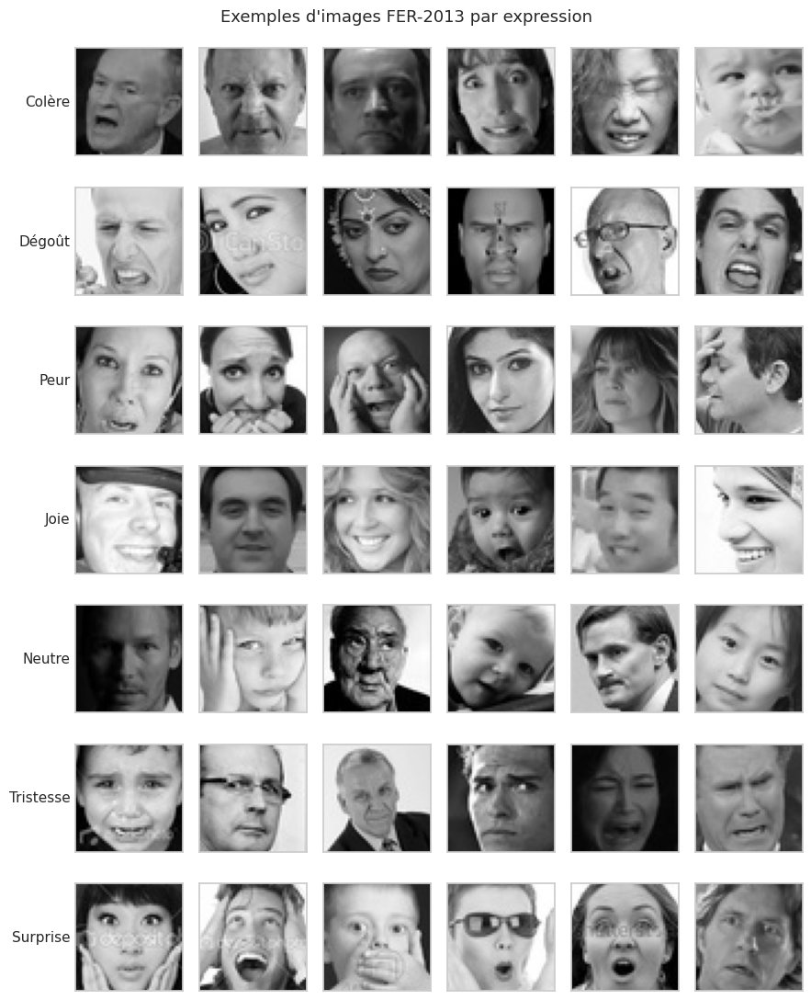

In [ ]:
N_EX = 6
fig, axes = plt.subplots(NUM_CLASSES, N_EX, figsize=(N_EX * 1.5, NUM_CLASSES * 1.6))
for i, cls in enumerate(CLASSES):
    paths = df[(df.split == "train") & (df.label == cls)]["path"].sample(N_EX, random_state=SEED)
    for j, p in enumerate(paths):
        ax = axes[i, j]
        ax.imshow(Image.open(p), cmap="gray", vmin=0, vmax=255)
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(fr(cls), rotation=0, ha="right", va="center", fontsize=11)
fig.suptitle("Exemples d'images FER-2013 par expression", fontsize=13)
plt.tight_layout(); plt.show()

**Observations :** les visages sont centrés et cadrés de façon homogène, mais on observe une grande variabilité
(âge, pose, éclairage, lunettes, mains devant le visage, filigranes). Certaines classes sont visuellement proches
(*Peur* / *Surprise* : bouche et yeux ouverts ; *Tristesse* / *Neutre* ; *Colère* / *Dégoût* : sourcils froncés),
ce qui laisse prévoir des confusions entre ces classes.

### 1.7 « Visage moyen » par classe et distribution des pixels

Moyenner toutes les images d'une classe fait ressortir les traits caractéristiques de chaque expression
(ce que le CNN devra apprendre à détecter).

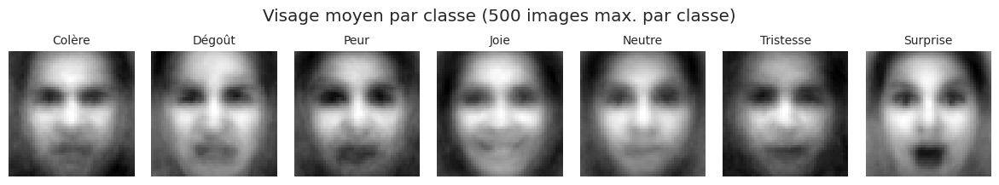

In [ ]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 1.7, 2.2))
for ax, cls in zip(axes, CLASSES):
    paths = df[(df.split == "train") & (df.label == cls)]["path"]
    paths = paths.sample(min(500, len(paths)), random_state=SEED)
    mean_img = np.mean([np.array(Image.open(p).convert("L"), dtype=np.float32) for p in paths], axis=0)
    ax.imshow(mean_img, cmap="gray"); ax.set_title(fr(cls), fontsize=10); ax.axis("off")
fig.suptitle("Visage moyen par classe (500 images max. par classe)")
plt.tight_layout(); plt.show()

---
## Préparation des données

Étapes, dans l'ordre :
1. chargement des images en tableaux NumPy + **redimensionnement** (si nécessaire) ;
2. **normalisation** des pixels ;
3. **préparation et encodage** des labels ;
4. constitution des ensembles **train / validation / test**.

### 1.8 Chargement, redimensionnement et normalisation

**Redimensionnement.** Un réseau de neurones attend des entrées de **taille fixe**. Les images FER-2013 font déjà
48 × 48 : on garde cette taille (aucune perte d'information, entraînement rapide). Le code redimensionne
quand même toute image qui n'aurait pas cette taille, par sécurité. *(Pour le Transfer Learning de la Partie 7,
on agrandira les images à la taille attendue par le réseau pré-entraîné.)*

**Ajout d'un axe canal.** Keras attend des images de forme `(hauteur, largeur, canaux)`. Une image en niveaux
de gris a 1 canal : on passe de `(48, 48)` à `(48, 48, 1)`.

**Normalisation.** On divise les pixels par 255 pour passer de [0, 255] à **[0, 1]**. Rôle :
- des entrées de petite amplitude évitent des activations et des gradients trop grands au début de l'entraînement ;
- toutes les entrées sont sur la même échelle : la descente de gradient converge plus vite et plus stablement ;
- le même pas d'apprentissage (learning rate) convient à tous les poids.

⚠️ **Ce prétraitement exact (niveaux de gris, 48×48, /255) devra être réappliqué à chaque visage détecté**
lors des extensions YOLO / vidéo (Parties 8–9), sinon les prédictions n'auront pas de sens.

In [ ]:
def preprocess_image(img, size=IMG_SIZE):
    # Prétraitement unique, réutilisé plus tard pour les visages détectés par YOLO.
    # img : image PIL ou tableau NumPy -> tableau float32 (size, size, 1) dans [0, 1]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(np.asarray(img))
    img = img.convert("L")                                   # niveaux de gris
    if img.size != (size, size):
        img = img.resize((size, size), Image.BILINEAR)       # redimensionnement
    arr = np.asarray(img, dtype=np.float32) / 255.0          # normalisation [0, 1]
    return arr[..., np.newaxis]                              # (size, size, 1)

def load_split(split):
    sub = df[df.split == split].reset_index(drop=True)
    X = np.stack([preprocess_image(Image.open(p)) for p in sub["path"]])
    return X, sub["label"].to_numpy()

X_train_full, y_train_full_str = load_split("train")
X_test, y_test_str = load_split("test")

print("X_train_full :", X_train_full.shape, X_train_full.dtype)
print("X_test       :", X_test.shape, X_test.dtype)
print(f"Pixels après normalisation : min={X_train_full.min():.2f}, max={X_train_full.max():.2f}, "
      f"moyenne={X_train_full.mean():.3f}")

X_train_full : (28709, 48, 48, 1) float32
X_test       : (7178, 48, 48, 1) float32
Pixels après normalisation : min=0.00, max=1.00, moyenne=0.508


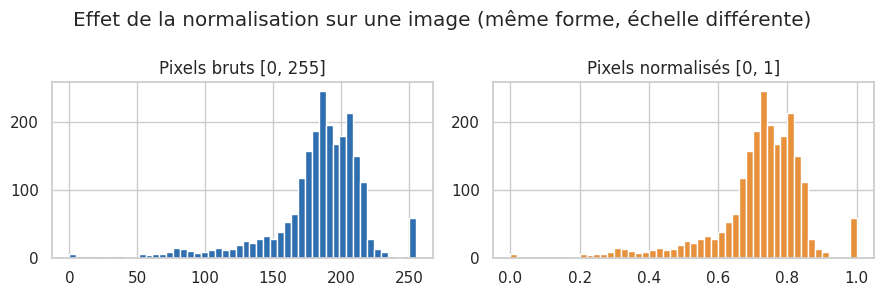

In [ ]:
idx = 0
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
raw = np.array(Image.open(df[df.split == "train"]["path"].iloc[idx]))
axes[0].hist(raw.ravel(), bins=50, color="#2f6fb0"); axes[0].set_title("Pixels bruts [0, 255]")
axes[1].hist(X_train_full[idx].ravel(), bins=50, color="#e8913c"); axes[1].set_title("Pixels normalisés [0, 1]")
plt.suptitle("Effet de la normalisation sur une image (même forme, échelle différente)")
plt.tight_layout(); plt.show()

### 1.9 Préparation et encodage des labels

Les labels sont des chaînes de caractères (`"happy"`, `"sad"`…), inutilisables directement par le réseau.

1. **Encodage entier** : chaque classe reçoit un indice (ordre alphabétique fixe, conservé dans `CLASSES`).
2. **Encodage one-hot** : l'indice `k` devient un vecteur de longueur 7 contenant un 1 en position `k`
   et des 0 ailleurs.

Pourquoi le one-hot ? La couche de sortie `Dense(7, activation="softmax")` produit **7 probabilités**.
La perte `categorical_crossentropy` compare ce vecteur de probabilités au vecteur one-hot de la vraie classe.
Garder un simple entier (0 à 6) suggérerait à tort un ordre entre les émotions (« Tristesse > Joie »), ce qui n'a pas de sens.

*(Équivalent : garder les labels entiers et utiliser `sparse_categorical_crossentropy` ; on conserve les deux versions.)*

In [ ]:
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

y_train_full = np.array([class_to_idx[c] for c in y_train_full_str])
y_test = np.array([class_to_idx[c] for c in y_test_str])

def to_one_hot(y, n=NUM_CLASSES):
    # équivalent de keras.utils.to_categorical
    return np.eye(n, dtype=np.float32)[y]

print("Correspondance classe -> indice :")
for c, i in class_to_idx.items():
    print(f"  {i} : {c:9s} {'('+fr(c)+')':12s} one-hot = {to_one_hot(np.array([i]))[0].astype(int)}")

Correspondance classe -> indice :
  0 : angry     (Colère)     one-hot = [1 0 0 0 0 0 0]
  1 : disgust   (Dégoût)     one-hot = [0 1 0 0 0 0 0]
  2 : fear      (Peur)       one-hot = [0 0 1 0 0 0 0]
  3 : happy     (Joie)       one-hot = [0 0 0 1 0 0 0]
  4 : neutral   (Neutre)     one-hot = [0 0 0 0 1 0 0]
  5 : sad       (Tristesse)  one-hot = [0 0 0 0 0 1 0]
  6 : surprise  (Surprise)   one-hot = [0 0 0 0 0 0 1]


### 1.10 Constitution des ensembles train / validation / test

| Ensemble | Rôle | Utilisé pour |
|---|---|---|
| **Train** | apprendre les poids | rétropropagation, mise à jour des poids |
| **Validation** | régler le modèle | suivre l'entraînement, détecter le surapprentissage, choisir les hyperparamètres, Early Stopping |
| **Test** | évaluation finale | **une seule fois**, sur le modèle final choisi |

Le dataset fournit déjà un dossier `test/` (≈ 7 200 images) : il est **mis de côté** et ne servira qu'à
l'évaluation finale. Le jeu de test ne doit jamais servir de validation, sinon nos choix de modèle seraient
biaisés en faveur de ce jeu et la performance annoncée serait optimiste.

La **validation** est extraite du dossier `train/` (15 %), avec un découpage **stratifié** : chaque classe garde
la même proportion dans train et validation, ce qui est important vu le déséquilibre (la classe *Dégoût* doit
être présente dans les deux ensembles).

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=VAL_RATIO, stratify=y_train_full, random_state=SEED)

y_train_oh, y_val_oh, y_test_oh = to_one_hot(y_train), to_one_hot(y_val), to_one_hot(y_test)

print(f"{'Ensemble':<11}{'X':<22}{'y (one-hot)':<16}")
for name, X, Y in [("Train", X_train, y_train_oh), ("Validation", X_val, y_val_oh), ("Test", X_test, y_test_oh)]:
    print(f"{name:<11}{str(X.shape):<22}{str(Y.shape):<16}")

split_tab = pd.DataFrame({
    name: pd.Series(y).map(idx_to_class).map(fr).value_counts(normalize=True).mul(100).round(1)
    for name, y in [("Train %", y_train), ("Validation %", y_val), ("Test %", y_test)]})
split_tab

Ensemble   X                     y (one-hot)     
Train      (24402, 48, 48, 1)    (24402, 7)      
Validation (4307, 48, 48, 1)     (4307, 7)       
Test       (7178, 48, 48, 1)     (7178, 7)       


,Train %,Validation %,Test %
Colère,13.9,13.9,13.3
Dégoût,1.5,1.5,1.5
Joie,25.1,25.1,24.7
Neutre,17.3,17.3,17.2
Peur,14.3,14.3,14.3
Surprise,11.0,11.1,11.6
Tristesse,16.8,16.8,17.4


Les proportions de chaque classe sont quasi identiques dans les trois ensembles : le découpage stratifié
a bien conservé la distribution d'origine.

### 1.11 Poids des classes (préparation pour la Partie 6)

Pour compenser le déséquilibre, on peut donner plus d'importance aux erreurs commises sur les classes rares
pendant l'entraînement (`model.fit(..., class_weight=class_weights)`). Formule utilisée (« balanced ») :

$$w_k = \frac{N_{\text{total}}}{K \times N_k}$$

Une classe rare a un poids > 1, une classe fréquente un poids < 1. Cette option sera **testée comme
expérience** en Partie 6 (avec / sans poids), pour mesurer son effet sur le rappel de *Dégoût*.

In [ ]:
weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = {i: float(w) for i, w in enumerate(weights)}
pd.DataFrame({"classe": [fr(idx_to_class[i]) for i in class_weights],
              "nb images (train)": np.bincount(y_train, minlength=NUM_CLASSES),
              "poids": np.round(list(class_weights.values()), 2)})

,classe,nb images (train),poids
0,Colère,3396,1.03
1,Dégoût,371,9.40
2,Peur,3482,1.00
3,Joie,6133,0.57
4,Neutre,4220,0.83
5,Tristesse,4105,0.85
6,Surprise,2695,1.29


### 1.12 Sauvegarde des données préparées

On enregistre les tableaux prêts à l'emploi pour ne pas refaire le chargement dans les parties suivantes.
Dans Colab, monter Google Drive (`from google.colab import drive; drive.mount('/content/drive')`) et
choisir un dossier du Drive pour que le fichier survive à la fin de la session.

In [ ]:
try:
    from google.colab import drive          # uniquement dans Colab
    drive.mount("/content/drive")
except Exception:
    pass                                     # hors Colab : sauvegarde locale
SAVE_DIR = "/content/drive/MyDrive/projet_dl" if os.path.isdir("/content/drive/MyDrive") else "."
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, "fer2013_prepared.npz")
np.savez_compressed(SAVE_PATH,
                    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
                    X_test=X_test, y_test=y_test, classes=np.array(CLASSES))
print(f"Données sauvegardées dans {SAVE_PATH} ({os.path.getsize(SAVE_PATH) / 1e6:.0f} Mo)")

Mounted at /content/drive
Données sauvegardées dans /content/drive/MyDrive/projet_dl/fer2013_prepared.npz (107 Mo)


### 1.13 Synthèse de la Partie 1

| Élément | Valeur |
|---|---|
| Dataset | FER-2013 (Kaggle, ICML 2013) |
| Classes | 7 : Colère, Dégoût, Peur, Joie, Neutre, Tristesse, Surprise |
| Format | JPEG, niveaux de gris (1 canal), 48 × 48 px |
| Prétraitement | niveaux de gris → 48×48 → /255 → forme `(48, 48, 1)` |
| Labels | encodage entier (0–6) + one-hot (vecteurs de taille 7) |
| Découpage | train 85 % / validation 15 % du dossier train (stratifié), test officiel séparé |
| Déséquilibre | fort (Joie ≫ Dégoût) → métriques par classe, poids de classes, augmentation |

**Conséquence pour la suite :** entrée du réseau `(48, 48, 1)`, couche de sortie `Dense(7, activation="softmax")`,
perte `categorical_crossentropy`. Ligne de base à battre : ≈ 25 % (toujours prédire la classe majoritaire).

In [ ]:
# Libère la mémoire avant la Partie 2 : sans cela, les données et modèles des parties précédentes
# s'accumulent en RAM et Colab finit par planter. Aucune perte : chaque partie relit ce dont elle a besoin dans le Drive.
# Après un plantage, reprendre ici avec « Exécution > Exécuter après ».
%reset -f
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()
print("Mémoire libérée — début de la Partie 2")

Mémoire libérée — début de la Partie 2


---
## Partie 2 — Modèle de référence (réseau dense)

**Architecture retenue :**

$$\text{Image } (48{\times}48{\times}1) \;\rightarrow\; \text{Flatten} \;\rightarrow\; \text{Dense}(256) + \text{ReLU}
\;\rightarrow\; \text{Dense}(7) \;\rightarrow\; \text{Softmax}$$

L'objectif n'est **pas** d'obtenir d'excellentes performances : ce réseau simple sert de **point de comparaison**
pour le CNN de la Partie 3. Il permet aussi d'illustrer concrètement les notions de base : poids, biais,
propagation avant, activation, fonction de perte, rétropropagation et descente de gradient.

> ⚙️ Colab : `Exécution > Modifier le type d'exécution > GPU (T4)`, puis `Tout exécuter`.
> Ce notebook réutilise les données préparées et sauvegardées par la Partie 1.

### 2.0 Configuration et chargement des données préparées

In [ ]:
import os, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

try:
    from google.colab import drive          # uniquement dans Colab
    drive.mount("/content/drive")
except Exception:
    pass
SAVE_DIR = "/content/drive/MyDrive/projet_dl" if os.path.isdir("/content/drive/MyDrive") else "."
os.makedirs(SAVE_DIR, exist_ok=True)

data = np.load(os.path.join(SAVE_DIR, "fer2013_prepared.npz"))
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
CLASSES = list(data["classes"])
NUM_CLASSES = len(CLASSES)

FR = {"angry": "Colère", "disgust": "Dégoût", "fear": "Peur", "happy": "Joie",
      "neutral": "Neutre", "sad": "Tristesse", "surprise": "Surprise"}
CLASSES_FR = [FR.get(c, c) for c in CLASSES]

y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh = keras.utils.to_categorical(y_val, NUM_CLASSES)

print("TensorFlow", tf.__version__, "| GPU :", tf.config.list_physical_devices("GPU") or "aucun")
print("Train :", X_train.shape, "| Validation :", X_val.shape)
print("Classes :", CLASSES_FR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow 2.21.0 | GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train : (24402, 48, 48, 1) | Validation : (4307, 48, 48, 1)
Classes : ['Colère', 'Dégoût', 'Peur', 'Joie', 'Neutre', 'Tristesse', 'Surprise']


> Le jeu de **test n'est pas chargé ici** : il est réservé à l'évaluation finale (Partie 5), où le modèle de
> référence et le CNN seront comparés sur les mêmes images. Toutes les décisions de cette partie se font sur la **validation**.

### 2.1 Comment une image devient l'entrée du réseau

Une image FER-2013 normalisée est un tableau de forme `(48, 48, 1)` : 48 lignes × 48 colonnes de pixels
dans [0, 1]. Une couche **Dense** attend un **vecteur**. La couche **Flatten** « déroule » donc l'image
ligne après ligne en un vecteur de $48 \times 48 \times 1 = 2\,304$ valeurs :

$$x = (x_1, x_2, \dots, x_{2304})$$

Flatten n'a **aucun paramètre** : elle ne fait que réorganiser les données.

**Limite importante :** après Flatten, le réseau ne « sait » plus que le pixel $x_{50}$ est juste en dessous
du pixel $x_2$. La **structure spatiale** de l'image (voisinage des pixels, formes locales comme un œil
ou un coin de bouche) est perdue. C'est précisément ce que le CNN corrigera.

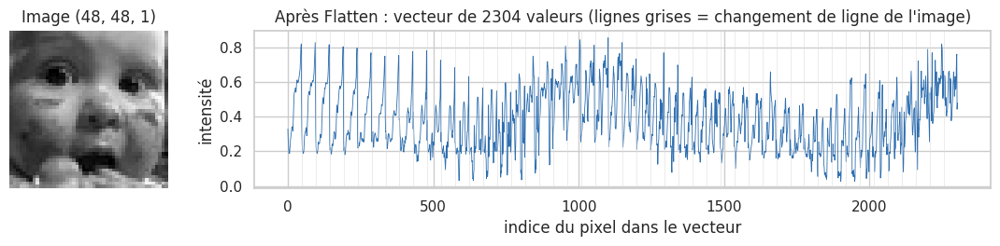

In [ ]:
img = X_train[0]
vec = img.reshape(-1)
fig, axes = plt.subplots(1, 2, figsize=(11, 2.8), gridspec_kw={"width_ratios": [1, 4]})
axes[0].imshow(img[..., 0], cmap="gray"); axes[0].set_title(f"Image {img.shape}"); axes[0].axis("off")
axes[1].plot(vec, lw=0.6, color="#2f6fb0")
for r in range(1, 48):
    axes[1].axvline(r * 48, color="#ddd", lw=0.4)
axes[1].set_title(f"Après Flatten : vecteur de {vec.size} valeurs (lignes grises = changement de ligne de l'image)")
axes[1].set_xlabel("indice du pixel dans le vecteur"); axes[1].set_ylabel("intensité")
plt.tight_layout(); plt.show()

### 2.2 Poids, biais et propagation avant

Chaque neurone d'une couche Dense calcule une **somme pondérée** de toutes ses entrées, plus un **biais**,
puis applique une **fonction d'activation** :

$$z_j = \sum_{i} w_{ij}\, x_i + b_j \qquad\qquad a_j = f(z_j)$$

- les **poids** $w_{ij}$ mesurent l'importance de l'entrée $i$ pour le neurone $j$ (positif : l'entrée
  « excite » le neurone ; négatif : elle l'inhibe) ;
- le **biais** $b_j$ décale le seuil d'activation du neurone, indépendamment des entrées ;
- poids et biais sont les **paramètres appris** pendant l'entraînement (initialisés aléatoirement).

Sous forme matricielle, pour toute la couche : $\;a = f(W^\top x + b)$.

La **propagation avant** (*forward pass*) consiste à enchaîner ces calculs couche après couche, de l'image
jusqu'aux probabilités de sortie :

$$x \in \mathbb{R}^{2304}
\;\xrightarrow{\;W_1,\,b_1,\;\text{ReLU}\;}\; h \in \mathbb{R}^{256}
\;\xrightarrow{\;W_2,\,b_2\;}\; z \in \mathbb{R}^{7}
\;\xrightarrow{\;\text{Softmax}\;}\; \hat{y} \in [0,1]^{7}$$

### 2.3 Fonctions d'activation

**ReLU** (couche cachée) : $\;\text{ReLU}(z) = \max(0, z)$
- introduit la **non-linéarité** : sans elle, enchaîner des couches Dense reviendrait à une seule
  transformation linéaire, incapable d'apprendre des frontières de décision complexes ;
- très simple à calculer, et sa dérivée vaut 1 pour $z>0$ : le gradient se propage bien (contrairement à
  la sigmoïde qui sature et « écrase » les gradients).

**Softmax** (sortie) : transforme les 7 scores bruts $z_k$ (appelés *logits*) en probabilités :

$$\hat{y}_k = \text{Softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^{7} e^{z_j}}$$

Toutes les valeurs sont entre 0 et 1 et leur somme vaut 1. La classe prédite est celle de probabilité maximale.

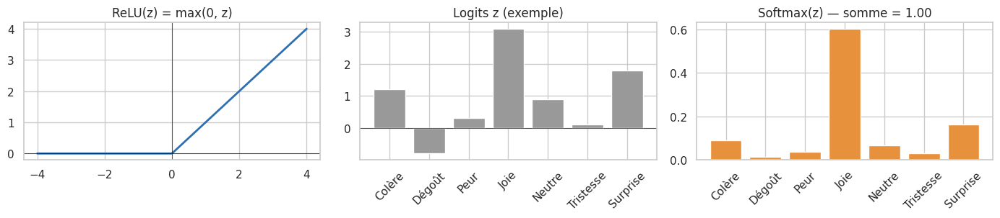

In [ ]:
z = np.linspace(-4, 4, 200)
logits_ex = np.array([1.2, -0.8, 0.3, 3.1, 0.9, 0.1, 1.8])
softmax_ex = np.exp(logits_ex) / np.exp(logits_ex).sum()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
axes[0].plot(z, np.maximum(0, z), color="#2f6fb0", lw=2); axes[0].set_title("ReLU(z) = max(0, z)")
axes[0].axhline(0, color="k", lw=0.5); axes[0].axvline(0, color="k", lw=0.5)
axes[1].bar(CLASSES_FR, logits_ex, color="#999"); axes[1].set_title("Logits z (exemple)")
axes[1].axhline(0, color="k", lw=0.5)
axes[2].bar(CLASSES_FR, softmax_ex, color="#e8913c"); axes[2].set_title(f"Softmax(z) — somme = {softmax_ex.sum():.2f}")
for ax in axes[1:]:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### 2.4 Construction du modèle avec Keras

Choix :
- **256 neurones** dans la couche cachée : assez pour apprendre des combinaisons de pixels, sans exploser
  le nombre de paramètres ;
- **7 neurones de sortie** = nombre de classes du dataset ;
- Softmax écrite comme une couche séparée pour suivre exactement le schéma *Dense → Softmax*
  (équivalent à `Dense(7, activation="softmax")`).

In [ ]:
def build_baseline(hidden_units=256, input_shape=(48, 48, 1), num_classes=NUM_CLASSES):
    return keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Flatten(name="flatten"),
        layers.Dense(hidden_units, activation="relu", name="dense_relu"),
        layers.Dense(num_classes, name="dense_logits"),
        layers.Softmax(name="softmax"),
    ], name="modele_reference")

baseline = build_baseline()
baseline.summary()

Model: "modele_reference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu (Dense)              │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 7)              │         1,799 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,879 (2.26 MB)

 Trainable params: 591,879 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

#### Évolution des dimensions et nombre de paramètres

Pour une couche Dense : $\;\text{paramètres} = n_{\text{entrées}} \times n_{\text{neurones}} + n_{\text{neurones}}$
(un poids par connexion + un biais par neurone).

| Couche | Sortie | Calcul des paramètres | Paramètres |
|---|---|---|---|
| Entrée | (48, 48, 1) | — | 0 |
| Flatten | (2304) | réorganisation seulement | 0 |
| Dense + ReLU | (256) | 2304 × 256 + 256 | 590 080 |
| Dense | (7) | 256 × 7 + 7 | 1 799 |
| Softmax | (7) | normalisation seulement | 0 |
| **Total** | | | **591 879** |

**99,7 % des paramètres sont dans la première couche Dense** : chaque pixel est connecté à chaque neurone.
Ce grand nombre de paramètres, sans aucune notion de voisinage entre pixels, rend ce modèle à la fois
peu efficace et sujet au **surapprentissage**.

In [ ]:
manual = {"flatten": 0,
          "dense_relu": 48 * 48 * 1 * 256 + 256,
          "dense_logits": 256 * NUM_CLASSES + NUM_CLASSES,
          "softmax": 0}
for layer in baseline.layers:
    print(f"{layer.name:13s} sortie={str(layer.output.shape):12s} "
          f"params Keras={layer.count_params():>7,}  calcul manuel={manual[layer.name]:>7,}")
print(f"{'TOTAL':13s} {'':19s} {baseline.count_params():>19,}")

flatten       sortie=(None, 2304) params Keras=      0  calcul manuel=      0
dense_relu    sortie=(None, 256)  params Keras=590,080  calcul manuel=590,080
dense_logits  sortie=(None, 7)    params Keras=  1,799  calcul manuel=  1,799
softmax       sortie=(None, 7)    params Keras=      0  calcul manuel=      0
TOTAL                                         591,879


### 2.5 Propagation avant « à la main » sur une image

Pour vérifier qu'on a bien compris ce que fait le réseau, on refait le calcul avec NumPy, en utilisant les
poids (encore aléatoires) du modèle, et on compare avec `model.predict`.

In [ ]:
W1, b1 = baseline.get_layer("dense_relu").get_weights()     # W1 : (2304, 256), b1 : (256,)
W2, b2 = baseline.get_layer("dense_logits").get_weights()   # W2 : (256, 7),    b2 : (7,)

x = X_train[0].reshape(-1)                 # Flatten        -> (2304,)
h = np.maximum(0, x @ W1 + b1)             # Dense + ReLU   -> (256,)
z = h @ W2 + b2                            # Dense          -> (7,) logits
p = np.exp(z - z.max()); p /= p.sum()      # Softmax (- max pour la stabilité numérique)

p_keras = baseline.predict(X_train[:1], verbose=0)[0]
print("Formes :", x.shape, "->", h.shape, "->", z.shape)
print("Neurones cachés actifs (ReLU > 0) :", int((h > 0).sum()), "/ 256")
print(pd.DataFrame({"logit z": z.round(3), "proba (NumPy)": p.round(4), "proba (Keras)": p_keras.round(4)},
                   index=CLASSES_FR))
print("Écart max NumPy / Keras :", float(np.abs(p - p_keras).max()))

Formes : (2304,) -> (256,) -> (7,)
Neurones cachés actifs (ReLU > 0) : 117 / 256
           logit z  proba (NumPy)  proba (Keras)
Colère       0.269         0.2162         0.2162
Dégoût      -1.031         0.0589         0.0589
Peur        -0.129         0.1452         0.1452
Joie         0.435         0.2552         0.2552
Neutre      -1.533         0.0357         0.0357
Tristesse    0.057         0.1748         0.1748
Surprise    -0.370         0.1141         0.1141
Écart max NumPy / Keras : 5.960464477539063e-08


Avant entraînement, les poids sont **aléatoires** : les probabilités obtenues n'ont aucun lien avec la vraie
expression (le réseau ne sait encore rien). Le calcul manuel donne exactement le même résultat que Keras
(écart de l'ordre de $10^{-7}$, dû aux arrondis des nombres flottants).

### 2.6 Fonction de perte : entropie croisée catégorielle

Pour mesurer l'erreur d'une prédiction $\hat{y}$ par rapport au vrai label one-hot $y$ :

$$\mathcal{L}(y, \hat{y}) = -\sum_{k=1}^{7} y_k \log \hat{y}_k = -\log \hat{y}_{\text{vraie classe}}$$

Comme $y$ est one-hot, seule la probabilité donnée à la **vraie classe** compte :
- proba de la vraie classe = 0,9 → perte = 0,11 (bonne prédiction, faible pénalité) ;
- proba = 0,14 (hasard) → perte = 1,95 ;
- proba = 0,01 → perte = 4,6 (prédiction confiante et fausse, forte pénalité).

Sur un lot (*batch*), on prend la **moyenne** des pertes. Un modèle qui répondrait au hasard (1/7 pour chaque
classe) aurait une perte de $\log 7 \approx 1{,}95$ : c'est l'ordre de grandeur attendu en début d'entraînement
(souvent un peu plus, car l'initialisation aléatoire donne des prédictions plus tranchées que 1/7).

Vraie classe : Peur  | proba prédite : 0.145
Perte (manuelle) = 1.9297 | Perte (Keras) = 1.9297 | log(7) = 1.9459


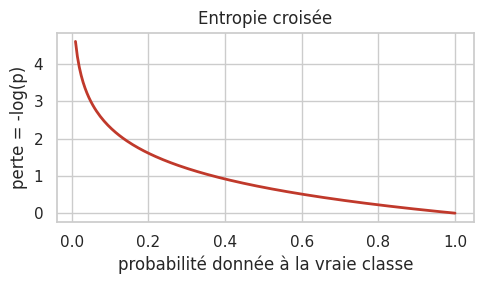

In [ ]:
y_true = keras.utils.to_categorical(y_train[:1], NUM_CLASSES)[0]
loss_manual = -np.sum(y_true * np.log(p))
loss_keras = keras.losses.CategoricalCrossentropy()(y_true[None], p_keras[None]).numpy()
print(f"Vraie classe : {CLASSES_FR[y_train[0]]}  | proba prédite : {p[y_train[0]]:.3f}")
print(f"Perte (manuelle) = {loss_manual:.4f} | Perte (Keras) = {loss_keras:.4f} | log(7) = {np.log(7):.4f}")

q = np.linspace(0.01, 1, 200)
plt.figure(figsize=(5, 3))
plt.plot(q, -np.log(q), color="#c0392b", lw=2)
plt.xlabel("probabilité donnée à la vraie classe"); plt.ylabel("perte = -log(p)")
plt.title("Entropie croisée"); plt.tight_layout(); plt.show()

### 2.7 Rétropropagation et descente de gradient

**Descente de gradient.** L'entraînement cherche les poids qui minimisent la perte. Le **gradient**
$\partial \mathcal{L} / \partial w$ indique dans quelle direction la perte augmente quand on modifie $w$.
On fait donc un petit pas dans la direction **opposée** :

$$w \;\leftarrow\; w - \eta \, \frac{\partial \mathcal{L}}{\partial w}$$

où $\eta$ est le **taux d'apprentissage** (*learning rate*) : trop grand, l'entraînement diverge ;
trop petit, il est très lent.

**Rétropropagation.** Le réseau a ≈ 592 000 paramètres : il faut calculer efficacement la dérivée de la perte
par rapport à chacun. La rétropropagation applique la **règle de dérivation en chaîne** en partant de la
sortie et en remontant couche par couche :

$$\frac{\partial \mathcal{L}}{\partial W_1}
= \frac{\partial \mathcal{L}}{\partial z}\cdot\frac{\partial z}{\partial h}\cdot\frac{\partial h}{\partial W_1}$$

Résultat remarquable pour Softmax + entropie croisée : $\;\dfrac{\partial \mathcal{L}}{\partial z} = \hat{y} - y\;$
(probabilités prédites moins le one-hot). L'erreur est ensuite renvoyée vers la couche cachée par $W_2$, et
la dérivée de ReLU (1 si $z>0$, 0 sinon) ne laisse passer le gradient que par les neurones actifs.

**En pratique :**
- **mini-batch** : on calcule le gradient sur un lot de 64 images (et non une seule, ni tout le dataset) :
  compromis entre stabilité et rapidité ;
- **une époque** = un passage complet sur toutes les images d'entraînement ;
- **optimiseur Adam** : variante de la descente de gradient qui adapte automatiquement le pas pour chaque
  poids (moyennes mobiles des gradients et de leurs carrés) ; il converge plus vite et demande moins de réglages.

La cellule ci-dessous montre une étape de descente de gradient « à la main » avec `tf.GradientTape`,
exactement ce que `model.fit` répète des milliers de fois.

In [ ]:
demo = build_baseline()
demo.set_weights(baseline.get_weights())
xb, yb = X_train[:64], y_train_oh[:64]
loss_fn = keras.losses.CategoricalCrossentropy()
eta = 0.01

with tf.GradientTape() as tape:
    loss_before = loss_fn(yb, demo(xb, training=True))          # propagation avant
grads = tape.gradient(loss_before, demo.trainable_variables)     # rétropropagation

for var, g in zip(demo.trainable_variables, grads):              # descente de gradient
    var.assign_sub(eta * g)
loss_after = loss_fn(yb, demo(xb, training=False))

for var, g in zip(demo.trainable_variables, grads):
    print(f"{var.path:30s} forme={str(tuple(var.shape)):12s} norme du gradient={tf.norm(g).numpy():.4f}")
print(f"\nPerte du batch : {loss_before.numpy():.4f} -> {loss_after.numpy():.4f} après UNE étape de gradient")

modele_reference/dense_relu/kernel forme=(2304, 256)  norme du gradient=6.6079
modele_reference/dense_relu/bias forme=(256,)       norme du gradient=0.2631
modele_reference/dense_logits/kernel forme=(256, 7)     norme du gradient=2.1344
modele_reference/dense_logits/bias forme=(7,)         norme du gradient=0.2852

Perte du batch : 2.2734 -> 1.9637 après UNE étape de gradient


### 2.8 Entraînement

| Choix | Valeur | Justification |
|---|---|---|
| Perte | `categorical_crossentropy` | classification multiclasse, labels one-hot, sortie Softmax |
| Optimiseur | Adam, lr = 1e-3 | valeur par défaut robuste, convergence rapide |
| Batch size | 64 | bon compromis stabilité du gradient / vitesse / mémoire |
| Époques | 40 max + Early Stopping | on arrête quand la perte de validation ne s'améliore plus pendant 5 époques, et on garde les meilleurs poids |
| Métrique | accuracy | lisible ; complétée par l'accuracy par classe (déséquilibre) |

In [ ]:
baseline = build_baseline()
baseline.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                 loss="categorical_crossentropy",
                 metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                           restore_best_weights=True, verbose=1)

history = baseline.fit(X_train, y_train_oh,
                       validation_data=(X_val, y_val_oh),
                       epochs=40, batch_size=64,
                       callbacks=[early_stop], verbose=2)

Epoch 1/40
382/382 - 6s - 17ms/step - accuracy: 0.2773 - loss: 1.8118 - val_accuracy: 0.3053 - val_loss: 1.7276
Epoch 2/40
382/382 - 1s - 3ms/step - accuracy: 0.3244 - loss: 1.7096 - val_accuracy: 0.3392 - val_loss: 1.6884
Epoch 3/40
382/382 - 1s - 3ms/step - accuracy: 0.3360 - loss: 1.6862 - val_accuracy: 0.3522 - val_loss: 1.6679
Epoch 4/40
382/382 - 1s - 3ms/step - accuracy: 0.3448 - loss: 1.6668 - val_accuracy: 0.3511 - val_loss: 1.6703
Epoch 5/40
382/382 - 1s - 3ms/step - accuracy: 0.3561 - loss: 1.6497 - val_accuracy: 0.3555 - val_loss: 1.6477
Epoch 6/40
382/382 - 1s - 3ms/step - accuracy: 0.3600 - loss: 1.6378 - val_accuracy: 0.3599 - val_loss: 1.6422
Epoch 7/40
382/382 - 1s - 3ms/step - accuracy: 0.3656 - loss: 1.6253 - val_accuracy: 0.3548 - val_loss: 1.6370
Epoch 8/40
382/382 - 1s - 3ms/step - accuracy: 0.3712 - loss: 1.6121 - val_accuracy: 0.3648 - val_loss: 1.6362
Epoch 9/40
382/382 - 2s - 4ms/step - accuracy: 0.3769 - loss: 1.5996 - val_accuracy: 0.3706 - val_loss: 1.6107


### 2.9 Courbes d'apprentissage

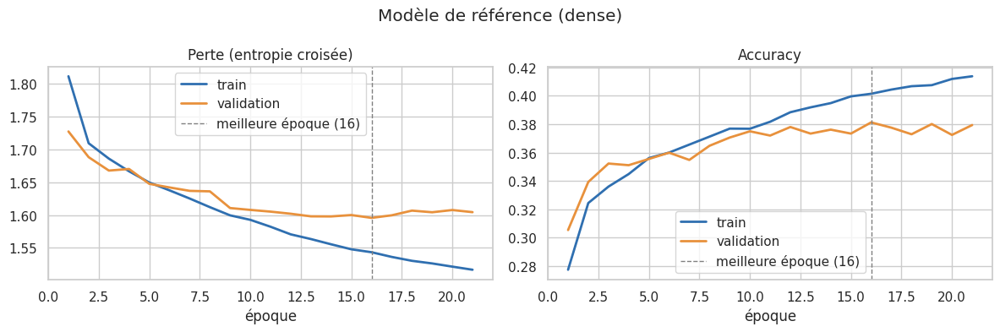

Meilleure époque : 16
  accuracy train = 0.401 | validation = 0.381
  perte    train = 1.543 | validation = 1.596


In [ ]:
h = history.history
ep = np.arange(1, len(h["loss"]) + 1)
best = int(np.argmin(h["val_loss"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ep, h["loss"], label="train", color="#2f6fb0", lw=2)
axes[0].plot(ep, h["val_loss"], label="validation", color="#e8913c", lw=2)
axes[0].set_title("Perte (entropie croisée)"); axes[0].set_xlabel("époque")
axes[1].plot(ep, h["accuracy"], label="train", color="#2f6fb0", lw=2)
axes[1].plot(ep, h["val_accuracy"], label="validation", color="#e8913c", lw=2)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("époque")
for ax in axes:
    ax.axvline(best, color="grey", ls="--", lw=1, label=f"meilleure époque ({best})")
    ax.legend()
plt.suptitle("Modèle de référence (dense)")
plt.tight_layout(); plt.show()

print(f"Meilleure époque : {best}")
print(f"  accuracy train = {h['accuracy'][best-1]:.3f} | validation = {h['val_accuracy'][best-1]:.3f}")
print(f"  perte    train = {h['loss'][best-1]:.3f} | validation = {h['val_loss'][best-1]:.3f}")

### 2.10 Résultats sur la validation, par classe

In [ ]:
val_loss, val_acc = baseline.evaluate(X_val, y_val_oh, verbose=0)
y_pred = baseline.predict(X_val, verbose=0).argmax(axis=1)

majority_acc = np.mean(y_val == np.bincount(y_train).argmax())
per_class = pd.DataFrame({
    "nb images (val)": np.bincount(y_val, minlength=NUM_CLASSES),
    "accuracy par classe (rappel)": [np.mean(y_pred[y_val == k] == k) if np.any(y_val == k) else np.nan
                                     for k in range(NUM_CLASSES)],
    "nb prédictions": np.bincount(y_pred, minlength=NUM_CLASSES),
}, index=CLASSES_FR).round(3)

print(f"Accuracy validation : {val_acc:.3f}   (hasard : {1/NUM_CLASSES:.3f} | toujours la classe majoritaire : {majority_acc:.3f})")
per_class

Accuracy validation : 0.381   (hasard : 0.143 | toujours la classe majoritaire : 0.251)


,nb images (val),accuracy par classe (rappel),nb prédictions
Colère,599,0.129,229
Dégoût,65,0.000,0
Peur,615,0.128,282
Joie,1082,0.691,1651
Neutre,745,0.290,633
Tristesse,725,0.408,1081
Surprise,476,0.475,431


### 2.11 Sauvegarde (pour la comparaison avec le CNN en Partie 5)

In [ ]:
baseline.save(os.path.join(SAVE_DIR, "modele_reference.keras"))
with open(os.path.join(SAVE_DIR, "historique_reference.json"), "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f)
print("Modèle et historique sauvegardés dans", SAVE_DIR)

Modèle et historique sauvegardés dans /content/drive/MyDrive/projet_dl


### 2.12 Analyse du modèle de référence

**Résultats obtenus**
- Accuracy de validation : **38,1 %** (meilleure époque : 16 ; arrêt par Early Stopping à l'époque 21).
  C'est nettement mieux que le hasard (14,3 %) et que la prédiction constante de la classe majoritaire (25,1 %) :
  le réseau a appris quelque chose des pixels.
- Sur le jeu de test (Partie 5) : **39,1 %** d'accuracy, F1 macro **0,30**.
- À la meilleure époque, l'accuracy d'entraînement n'est que de 40,1 % (perte 1,54 contre 1,60 en validation) :
  le modèle **plafonne même sur ses propres données d'entraînement**. Sa limite principale n'est pas le
  surapprentissage mais son incapacité à exploiter la structure de l'image.
- Rappel par classe (validation) : Joie 69,1 %, Surprise 47,5 %, Tristesse 40,8 %, Neutre 29,0 %, Colère 12,9 %,
  Peur 12,8 %, **Dégoût 0 %** (jamais prédit). Le modèle se réfugie dans les classes fréquentes : il prédit
  « Joie » 1 651 fois pour 1 082 vraies images Joie.

**Pourquoi ce modèle est limité**
1. **Perte de la structure spatiale** : Flatten traite l'image comme une liste de pixels sans voisinage ;
   le réseau ne peut pas exploiter les formes locales (contours d'un sourire, sourcils froncés).
2. **Pas d'invariance à la position** : si le visage est légèrement décalé, ce sont d'autres pixels, donc
   d'autres poids qui sont sollicités ; le réseau doit réapprendre le même motif à chaque position.
3. **Beaucoup de paramètres mal utilisés** : 590 080 poids dans la première couche, chacun lié à un pixel précis.

Seules les expressions aux signes très marqués et très fréquentes (sourire de la Joie, bouche ouverte de la
Surprise) sont reconnues correctement.

**Ce que le CNN (Partie 3) va apporter :** des filtres de convolution qui regardent de petites zones voisines,
**partagés sur toute l'image** (beaucoup moins de paramètres, détection d'un motif quelle que soit sa position),
et une extraction hiérarchique : bords → formes (yeux, bouche) → expression.

In [ ]:
# Libère la mémoire avant la Partie 3 : sans cela, les données et modèles des parties précédentes
# s'accumulent en RAM et Colab finit par planter. Aucune perte : chaque partie relit ce dont elle a besoin dans le Drive.
# Après un plantage, reprendre ici avec « Exécution > Exécuter après ».
%reset -f
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()
print("Mémoire libérée — début de la Partie 3")

Mémoire libérée — début de la Partie 3


---
## Partie 3 — Construction d'un CNN avec Keras

Le modèle de référence (Partie 2) aplatit l'image dès l'entrée et perd toute la structure spatiale.
Un **réseau de neurones convolutif (CNN)** est conçu pour les images : il commence par **extraire des
caractéristiques locales** (bords, contours, puis formes comme les yeux, la bouche, les sourcils), et seulement
ensuite **classe** l'image à partir de ces caractéristiques.

**Architecture proposée (3 blocs convolutifs) :**

$$\text{Image } 48{\times}48{\times}1
\rightarrow \underbrace{[\text{Conv } 32 + \text{ReLU} \rightarrow \text{MaxPool}]}_{\text{bloc 1}}
\rightarrow \underbrace{[\text{Conv } 64 + \text{ReLU} \rightarrow \text{MaxPool}]}_{\text{bloc 2}}
\rightarrow \underbrace{[\text{Conv } 128 + \text{ReLU} \rightarrow \text{MaxPool}]}_{\text{bloc 3}}
\rightarrow \text{Flatten} \rightarrow \text{Dense } 128 + \text{ReLU} \rightarrow \text{Dense } 7 \rightarrow \text{Softmax}$$

Ce notebook explique chaque brique (sections 3.1 à 3.8), construit le modèle (3.9), suit l'évolution des
dimensions et du nombre de paramètres (3.10), puis justifie l'architecture (3.11).
L'entraînement fait l'objet de la Partie 4.

### 3.0 Configuration

In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass
SAVE_DIR = "/content/drive/MyDrive/projet_dl" if os.path.isdir("/content/drive/MyDrive") else "."

data = np.load(os.path.join(SAVE_DIR, "fer2013_prepared.npz"))
X_train, y_train = data["X_train"], data["y_train"]
CLASSES = list(data["classes"])
NUM_CLASSES = len(CLASSES)
FR = {"angry": "Colère", "disgust": "Dégoût", "fear": "Peur", "happy": "Joie",
      "neutral": "Neutre", "sad": "Tristesse", "surprise": "Surprise"}
CLASSES_FR = [FR.get(c, c) for c in CLASSES]

# une image d'exemple pour les illustrations (de préférence un visage joyeux)
k_happy = CLASSES.index("happy") if "happy" in CLASSES else 0
face = X_train[np.where(y_train == k_happy)[0][0]]      # (48, 48, 1), valeurs dans [0, 1]
print("Image d'exemple :", face.shape, "| classe :", CLASSES_FR[k_happy])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image d'exemple : (48, 48, 1) | classe : Joie


### 3.1 Le principe de la convolution

Un **filtre** (ou **kernel**) est une petite matrice de poids, par exemple 3 × 3. La convolution consiste à
**faire glisser** ce filtre sur l'image : à chaque position, on multiplie terme à terme le filtre et la zone
de l'image qu'il recouvre, on additionne, et on ajoute un biais :

$$\text{sortie}(i, j) = \sum_{u=0}^{2}\sum_{v=0}^{2} K(u, v)\; I(i+u,\, j+v) \;+\; b$$

Le résultat est une nouvelle image appelée **feature map** (carte de caractéristiques) : elle vaut fort là où
la zone de l'image **ressemble au motif** encodé par le filtre.

Exemple à la main sur une image 5 × 5 contenant un bord vertical (gauche sombre, droite claire) :

In [ ]:
I = np.array([[0, 0, 0, 1, 1],
              [0, 0, 0, 1, 1],
              [0, 0, 0, 1, 1],
              [0, 0, 0, 1, 1],
              [0, 0, 0, 1, 1]], dtype=np.float32)
K = np.array([[-1, 0, 1],
              [-1, 0, 1],
              [-1, 0, 1]], dtype=np.float32)       # détecteur de bord vertical

def conv2d_naive(img, ker, stride=1):
    k = ker.shape[0]
    h = (img.shape[0] - k) // stride + 1
    w = (img.shape[1] - k) // stride + 1
    out = np.zeros((h, w), dtype=np.float32)
    for i in range(h):
        for j in range(w):
            zone = img[i*stride:i*stride+k, j*stride:j*stride+k]
            out[i, j] = np.sum(zone * ker)           # produit terme à terme puis somme
    return out

out_manual = conv2d_naive(I, K)
out_tf = tf.nn.conv2d(I[None, :, :, None], K[:, :, None, None], strides=1, padding="VALID")[0, :, :, 0].numpy()

print("Image 5x5 :\n", I.astype(int))
print("\nFiltre 3x3 :\n", K.astype(int))
print("\nFeature map 3x3 (calcul manuel) :\n", out_manual)
print("\nIdentique à TensorFlow :", np.allclose(out_manual, out_tf))

Image 5x5 :
 [[0 0 0 1 1]
 [0 0 0 1 1]
 [0 0 0 1 1]
 [0 0 0 1 1]
 [0 0 0 1 1]]

Filtre 3x3 :
 [[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

Feature map 3x3 (calcul manuel) :
 [[0. 3. 3.]
 [0. 3. 3.]
 [0. 3. 3.]]

Identique à TensorFlow : True


La feature map vaut **3 exactement là où se trouve le bord** et 0 dans les zones uniformes : le filtre a
**détecté** le motif « passage du sombre au clair ».

*(Remarque : en Deep Learning, l'opération calculée est en toute rigueur une corrélation croisée — le filtre
n'est pas retourné — mais on l'appelle convolution par convention.)*

### 3.2 Le rôle des filtres et les feature maps

Dans un CNN, **les valeurs des filtres ne sont pas choisies à la main : ce sont des poids appris** par
rétropropagation. Chaque couche convolutive possède plusieurs filtres, et **chaque filtre produit sa propre
feature map**. Une couche avec 32 filtres transforme donc une image en 32 feature maps empilées
(sortie de profondeur 32).

Pour illustrer, appliquons à un vrai visage quelques filtres classiques choisis à la main. Un CNN entraîné
apprend en général dans sa première couche des filtres qui ressemblent à ceux-ci.

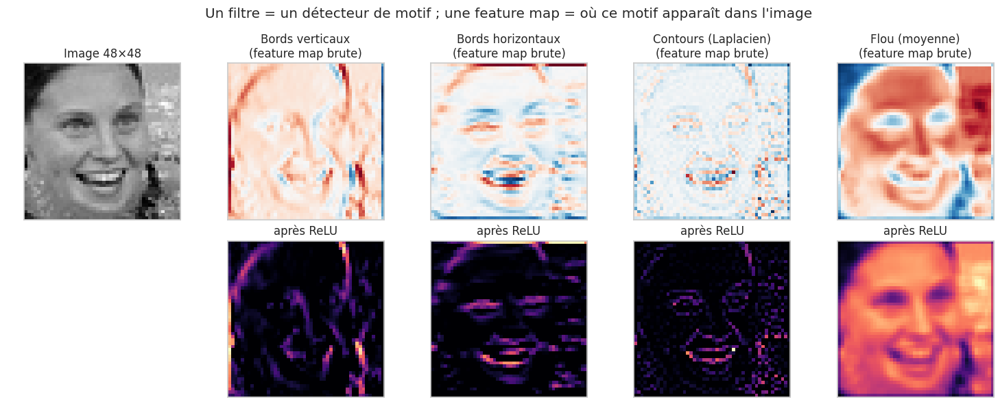

In [ ]:
filters = {
    "Bords verticaux":   np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    "Bords horizontaux": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
    "Contours (Laplacien)": np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]),
    "Flou (moyenne)":    np.ones((3, 3)) / 9,
}
img = face[..., 0]
fig, axes = plt.subplots(2, len(filters) + 1, figsize=(15, 6))
axes[0, 0].imshow(img, cmap="gray"); axes[0, 0].set_title("Image 48×48")
axes[1, 0].axis("off")
for col, (name, ker) in enumerate(filters.items(), start=1):
    fmap = tf.nn.conv2d(img[None, :, :, None].astype(np.float32),
                        ker[:, :, None, None].astype(np.float32), 1, "SAME")[0, :, :, 0].numpy()
    axes[0, col].imshow(fmap, cmap="RdBu_r"); axes[0, col].set_title(f"{name}\n(feature map brute)")
    axes[1, col].imshow(np.maximum(fmap, 0), cmap="magma"); axes[1, col].set_title("après ReLU")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Un filtre = un détecteur de motif ; une feature map = où ce motif apparaît dans l'image")
plt.tight_layout(); plt.show()

Le filtre « bords horizontaux » fait ressortir la **bouche** et les **sourcils**, le filtre « bords verticaux »
les contours du nez et du visage : exactement les zones qui portent l'expression. Les couches suivantes
combinent ces bords simples en motifs plus complexes (coin de bouche relevé, sourcil froncé…).

### 3.3 Taille du kernel, stride et padding

**Taille du kernel** ($k$) : taille de la zone regardée par le filtre.
- 3 × 3 est le choix standard : peu de paramètres (9 par canal), et deux couches 3 × 3 successives voient
  une zone 5 × 5 (trois couches : 7 × 7) avec moins de paramètres et plus de non-linéarités qu'un seul grand filtre ;
- des kernels plus grands (5 × 5, 7 × 7) captent plus de contexte d'un coup mais coûtent plus de paramètres.

**Stride** ($s$) : pas de déplacement du filtre. Stride 1 = le filtre avance d'un pixel (sortie de même
taille, à padding près) ; stride 2 = il saute un pixel sur deux (sortie deux fois plus petite).

**Padding** ($p$) : ajout de zéros autour de l'image.
- `"valid"` : pas de padding → la sortie rétrécit de $k-1$ pixels (48 → 46 avec un kernel 3 × 3) et les
  pixels des bords sont moins « vus » par les filtres ;
- `"same"` : padding de $(k-1)/2$ → la sortie garde **la même taille** que l'entrée (avec stride 1).

**Formule de la taille de sortie :**

$$n_{\text{sortie}} = \left\lfloor \frac{n_{\text{entrée}} + 2p - k}{s} \right\rfloor + 1$$

Nous utilisons **kernel 3 × 3, stride 1, padding `same`** : la convolution extrait les caractéristiques sans
réduire la taille, et c'est le **pooling** qui se charge de réduire la résolution, de façon contrôlée.

In [ ]:
rows = []
for k in [3, 5]:
    for s in [1, 2]:
        for pad in ["valid", "same"]:
            out = layers.Conv2D(8, k, strides=s, padding=pad)(tf.zeros((1, 48, 48, 1)))
            p = (k - 1) // 2 if pad == "same" else 0
            formule = (48 + 2 * p - k) // s + 1
            rows.append({"kernel": f"{k}×{k}", "stride": s, "padding": pad,
                         "sortie Keras": f"{out.shape[1]}×{out.shape[2]}×{out.shape[3]}",
                         "formule": f"⌊(48 + 2×{p} − {k}) / {s}⌋ + 1 = {formule}"})
pd.DataFrame(rows)

,kernel,stride,padding,sortie Keras,formule
0,3×3,1,valid,46×46×8,⌊(48 + 2×0 − 3) / 1⌋ + 1 = 46
1,3×3,1,same,48×48×8,⌊(48 + 2×1 − 3) / 1⌋ + 1 = 48
2,3×3,2,valid,23×23×8,⌊(48 + 2×0 − 3) / 2⌋ + 1 = 23
3,3×3,2,same,24×24×8,⌊(48 + 2×1 − 3) / 2⌋ + 1 = 24
4,5×5,1,valid,44×44×8,⌊(48 + 2×0 − 5) / 1⌋ + 1 = 44
5,5×5,1,same,48×48×8,⌊(48 + 2×2 − 5) / 1⌋ + 1 = 48
6,5×5,2,valid,22×22×8,⌊(48 + 2×0 − 5) / 2⌋ + 1 = 22
7,5×5,2,same,24×24×8,⌊(48 + 2×2 − 5) / 2⌋ + 1 = 24


*(Pour `same` avec stride 2, Keras ajoute le padding nécessaire pour obtenir $\lceil 48/2 \rceil = 24$ ;
la formule avec $p=(k-1)/2$ donne le même résultat ici.)*

### 3.4 ReLU après chaque convolution

Chaque convolution est suivie de **ReLU** : $\max(0, z)$.
- elle ne garde que les **réponses positives** du filtre (« le motif est présent ») et met à zéro le reste
  (voir la 2ᵉ ligne de la figure 3.2) ;
- elle apporte la **non-linéarité** indispensable : sans elle, empiler des convolutions reviendrait à
  une seule convolution linéaire ;
- elle évite la saturation des gradients (dérivée = 1 pour les valeurs positives).

### 3.5 Le pooling

Le **MaxPooling 2 × 2** découpe chaque feature map en carrés de 2 × 2 pixels et ne garde que la **valeur
maximale** de chaque carré. Il n'a **aucun paramètre**.

Rôles :
- **divise par 2 la hauteur et la largeur** (48 → 24 → 12 → 6) : 4 fois moins de valeurs, donc moins de
  calculs et moins de paramètres dans les couches Dense ;
- garde l'information essentielle (« le motif est-il présent dans cette zone ? ») en oubliant sa position exacte :
  **petite invariance aux translations** (un visage décalé d'un pixel donne presque la même sortie) ;
- **agrandit le champ récepteur** des couches suivantes : après pooling, un filtre 3 × 3 couvre une zone
  deux fois plus grande de l'image d'origine, ce qui permet de détecter des motifs de plus en plus globaux.

Entrée 4x4 :
 [[1 3 2 0]
 [4 6 1 2]
 [0 2 5 7]
 [1 1 3 4]]

MaxPooling 2x2 -> 2x2 :
 [[6 2]
 [2 7]]


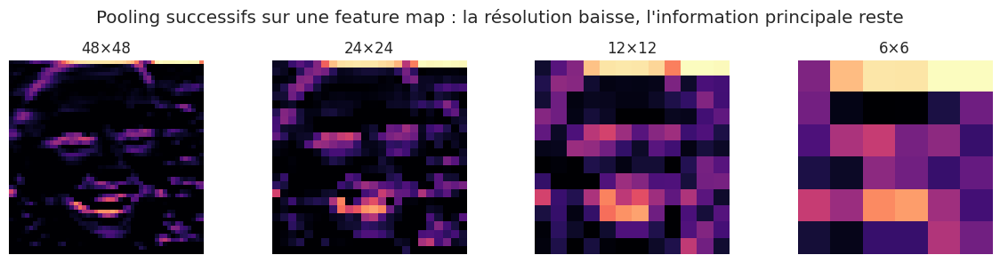

In [ ]:
x = np.array([[1, 3, 2, 0],
              [4, 6, 1, 2],
              [0, 2, 5, 7],
              [1, 1, 3, 4]], dtype=np.float32)
pooled = layers.MaxPooling2D(2)(x[None, :, :, None])[0, :, :, 0].numpy()
print("Entrée 4x4 :\n", x.astype(int))
print("\nMaxPooling 2x2 -> 2x2 :\n", pooled.astype(int))

fmap = np.maximum(tf.nn.conv2d(face[None].astype(np.float32),
                               filters["Bords horizontaux"][:, :, None, None].astype(np.float32), 1, "SAME")[0, :, :, 0], 0)
p1 = layers.MaxPooling2D(2)(fmap[None, :, :, None])
p2 = layers.MaxPooling2D(2)(p1)
p3 = layers.MaxPooling2D(2)(p2)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, m, t in zip(axes, [fmap, p1[0, ..., 0], p2[0, ..., 0], p3[0, ..., 0]], ["48×48", "24×24", "12×12", "6×6"]):
    ax.imshow(np.asarray(m), cmap="magma"); ax.set_title(t); ax.axis("off")
plt.suptitle("Pooling successifs sur une feature map : la résolution baisse, l'information principale reste")
plt.tight_layout(); plt.show()

### 3.6 Profondeur croissante : 32 → 64 → 128 filtres

Les blocs successifs construisent une **hiérarchie de caractéristiques** :
- **bloc 1** (32 filtres, voit des zones de 3 × 3 pixels) : bords, contrastes, petites textures ;
- **bloc 2** (64 filtres, champ récepteur ≈ 8 × 8) : combinaisons de bords → coins de bouche, contours d'yeux ;
- **bloc 3** (128 filtres, champ récepteur ≈ 18 × 18, soit une grande partie du visage) : motifs propres aux
  expressions → bouche ouverte, sourire, sourcils froncés.

On **double le nombre de filtres** à chaque fois que le pooling divise la résolution par 2 : on échange de
la résolution spatiale contre de la richesse de description, et le coût de calcul reste équilibré entre les blocs.

**Paramètres d'une couche convolutive :** chaque filtre a $k \times k \times C_{\text{entrée}}$ poids (il
traverse toute la profondeur de l'entrée) plus 1 biais :

$$\text{params} = (k \times k \times C_{\text{entrée}} + 1) \times C_{\text{sortie}}$$

Ces poids sont **partagés** : le même filtre est appliqué à toutes les positions de l'image. C'est la
différence fondamentale avec une couche Dense, et la raison pour laquelle les convolutions ont si peu de paramètres.

### 3.7 Flatten et couches Dense : la partie classification

Après le 3ᵉ bloc, on obtient 128 feature maps de 6 × 6 : une **description compacte et de haut niveau** du visage.
- **Flatten** déroule ce volume `(6, 6, 128)` en un vecteur de 4 608 valeurs (sans paramètre). Contrairement à la
  Partie 2, ce vecteur ne contient plus des pixels bruts mais des **caractéristiques déjà extraites** ;
- **Dense(128) + ReLU** combine ces caractéristiques pour raisonner sur l'expression
  (ex. « bouche ouverte » + « sourcils levés » → plutôt surprise) ;
- c'est la même mécanique que le modèle de référence, mais appliquée à de meilleures entrées.

### 3.8 La couche de sortie

**Dense(7)** puis **Softmax** : un neurone par classe, et Softmax transforme les 7 scores en probabilités
positives de somme 1. La classe prédite est celle de probabilité maximale. Le nombre de neurones de sortie
correspond au nombre de classes de FER-2013 (7).

### 3.9 Construction du modèle

On écrit une **fonction paramétrable** : elle sera réutilisée en Partie 6 pour faire varier le nombre de
blocs, de filtres, la taille des kernels ou ajouter du Dropout, sans réécrire le modèle.

In [ ]:
def build_cnn(filters=(32, 64, 128), kernel_size=3, dense_units=128, dropout=0.0,
              batch_norm=False, input_shape=(48, 48, 1), num_classes=NUM_CLASSES, name="cnn"):
    model = keras.Sequential(name=name)
    model.add(keras.Input(shape=input_shape))
    for i, f in enumerate(filters, start=1):
        model.add(layers.Conv2D(f, kernel_size, strides=1, padding="same", name=f"conv{i}"))
        if batch_norm:
            model.add(layers.BatchNormalization(name=f"bn{i}"))
        model.add(layers.ReLU(name=f"relu{i}"))
        model.add(layers.MaxPooling2D(pool_size=2, name=f"pool{i}"))
        if dropout:
            model.add(layers.Dropout(dropout / 2, name=f"drop{i}"))
    model.add(layers.Flatten(name="flatten"))
    model.add(layers.Dense(dense_units, activation="relu", name="dense"))
    if dropout:
        model.add(layers.Dropout(dropout, name="drop_dense"))
    model.add(layers.Dense(num_classes, name="logits"))
    model.add(layers.Softmax(name="softmax"))
    return model

cnn = build_cnn()          # version de base : sans Dropout ni BatchNorm (ils seront testés en Partie 6)
cnn.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 7)              │           903 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

### 3.10 Évolution des dimensions et nombre de paramètres, couche par couche

Le tableau ci-dessous est **calculé avec les formules** (sections 3.3 et 3.6) puis comparé automatiquement
à ce que donne Keras.

In [ ]:
def analyse_layers(model, input_shape=(48, 48, 1)):
    h, w, c = input_shape
    rows = [{"couche": "Entrée", "type": "image", "sortie": f"{h}×{w}×{c}",
             "valeurs en sortie": h * w * c, "calcul des paramètres": "—", "paramètres (formule)": 0,
             "paramètres (Keras)": 0, "sortie (Keras)": f"{h}×{w}×{c}"}]
    for layer in model.layers:
        name, t = layer.name, type(layer).__name__
        if t == "Conv2D":
            k = layer.kernel_size[0]
            calc, params = f"({k}×{k}×{c} + 1) × {layer.filters}", (k * k * c + 1) * layer.filters
            c = layer.filters
        elif t == "MaxPooling2D":
            h, w = h // 2, w // 2
            calc, params = "aucun (max)", 0
        elif t == "Flatten":
            h, w, c = 1, 1, h * w * c
            calc, params = "aucun (réorganisation)", 0
        elif t == "Dense":
            calc, params = f"{c} × {layer.units} + {layer.units}", c * layer.units + layer.units
            c = layer.units
        elif t == "BatchNormalization":
            calc, params = f"4 × {c}", 4 * c
        else:                                   # ReLU, Softmax, Dropout
            calc, params = "aucun", 0
        shape = f"{h}×{w}×{c}" if t not in ("Flatten", "Dense", "Softmax", "Dropout") or h > 1 else f"{c}"
        rows.append({"couche": name, "type": t, "sortie": shape, "valeurs en sortie": h * w * c,
                     "calcul des paramètres": calc, "paramètres (formule)": params,
                     "paramètres (Keras)": layer.count_params(),
                     "sortie (Keras)": "×".join(str(d) for d in layer.output.shape[1:])})
    df = pd.DataFrame(rows)
    return df

table = analyse_layers(cnn)
ok = all(int(a) == int(b) for a, b in zip(table["paramètres (formule)"][1:], table["paramètres (Keras)"][1:]))
print(f"Total des paramètres : {cnn.count_params():,}".replace(",", " "),
      "| formules == Keras :", ok)
table

Total des paramètres : 683 527 | formules == Keras : True


,couche,type,sortie,valeurs en sortie,calcul des paramètres,paramètres (formule),paramètres (Keras),sortie (Keras)
0,Entrée,image,48×48×1,2304,—,0,0,48×48×1
1,conv1,Conv2D,48×48×32,73728,(3×3×1 + 1) × 32,320,320,48×48×32
2,relu1,ReLU,48×48×32,73728,aucun,0,0,48×48×32
3,pool1,MaxPooling2D,24×24×32,18432,aucun (max),0,0,24×24×32
4,conv2,Conv2D,24×24×64,36864,(3×3×32 + 1) × 64,18496,18496,24×24×64
5,relu2,ReLU,24×24×64,36864,aucun,0,0,24×24×64
6,pool2,MaxPooling2D,12×12×64,9216,aucun (max),0,0,12×12×64
7,conv3,Conv2D,12×12×128,18432,(3×3×64 + 1) × 128,73856,73856,12×12×128
8,relu3,ReLU,12×12×128,18432,aucun,0,0,12×12×128
9,pool3,MaxPooling2D,6×6×128,4608,aucun (max),0,0,6×6×128


                              Modèle de référence (dense)  \
paramètres des convolutions                             0   
paramètres des couches Dense                       591879   
total                                              591879   
entrée de la 1ʳᵉ couche Dense        pixels bruts (2 304)   

                                                              CNN  
paramètres des convolutions                                 92672  
paramètres des couches Dense                               590855  
total                                                      683527  
entrée de la 1ʳᵉ couche Dense  caractéristiques extraites (4 608)  


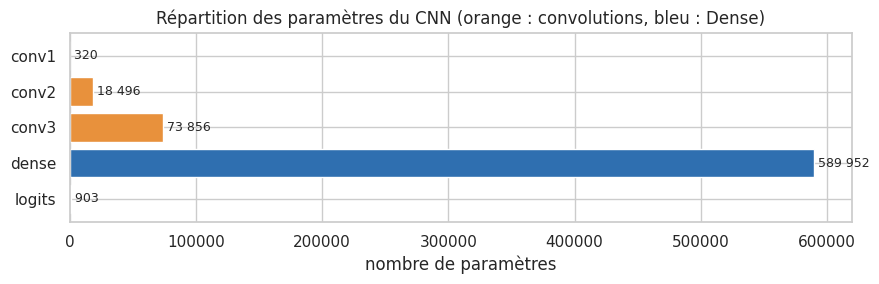

In [ ]:
# Où sont les paramètres ?  Comparaison avec le modèle de référence
conv_params = sum(l.count_params() for l in cnn.layers if isinstance(l, layers.Conv2D))
dense_params = sum(l.count_params() for l in cnn.layers if isinstance(l, layers.Dense))
baseline_params = 48 * 48 * 256 + 256 + 256 * 7 + 7

comp = pd.DataFrame({
    "Modèle de référence (dense)": [0, baseline_params, baseline_params, "pixels bruts (2 304)"],
    "CNN": [conv_params, dense_params, conv_params + dense_params, "caractéristiques extraites (4 608)"],
}, index=["paramètres des convolutions", "paramètres des couches Dense", "total", "entrée de la 1ʳᵉ couche Dense"])
display(comp) if "display" in globals() else print(comp)

fig, ax = plt.subplots(figsize=(9, 3))
names = [l.name for l in cnn.layers if l.count_params() > 0]
vals = [l.count_params() for l in cnn.layers if l.count_params() > 0]
ax.barh(names[::-1], vals[::-1], color=["#e8913c" if n.startswith("conv") else "#2f6fb0" for n in names[::-1]])
for i, v in enumerate(vals[::-1]):
    ax.text(v, i, f" {v:,}".replace(",", " "), va="center", fontsize=9)
ax.set_xlabel("nombre de paramètres"); ax.set_title("Répartition des paramètres du CNN (orange : convolutions, bleu : Dense)")
plt.tight_layout(); plt.show()

**Lecture du tableau :**
- les trois convolutions n'ont que **≈ 93 000 paramètres** au total, alors qu'elles font l'essentiel du travail
  d'extraction : c'est l'effet du **partage des poids** ;
- la hauteur et la largeur sont divisées par 2 à chaque pooling (48 → 24 → 12 → 6) pendant que la profondeur
  augmente (1 → 32 → 64 → 128) ;
- la majorité des paramètres se trouve dans la couche **Dense après Flatten** (4 608 × 128). C'est le principal
  risque de surapprentissage du modèle : nous le surveillerons en Partie 4 et testerons en Partie 6 du
  **Dropout** à cet endroit (ou un 4ᵉ bloc / un `GlobalAveragePooling` pour réduire ce nombre).

### 3.11 Justification de l'architecture

| Choix | Justification |
|---|---|
| Entrée 48 × 48 × 1 | taille et format natifs de FER-2013 (niveaux de gris) |
| 3 blocs Conv + Pool | 3 poolings ramènent 48 à 6 : assez pour obtenir un champ récepteur couvrant l'essentiel du visage ; un 4ᵉ bloc donnerait 3 × 3 (testé en Partie 6) |
| Kernels 3 × 3 | standard ; peu de paramètres ; empilés, ils couvrent de grandes zones avec plus de non-linéarités |
| Stride 1, padding `same` | aucune perte d'information aux bords ; la réduction de taille est confiée au pooling |
| 32 → 64 → 128 filtres | plus de motifs à décrire quand ils deviennent complexes ; coût équilibré entre les blocs |
| ReLU | non-linéarité simple, gradients stables |
| MaxPooling 2 × 2 | réduit la taille par 4, invariance aux petits décalages, élargit le champ récepteur |
| Dense(128) + ReLU | combine les caractéristiques extraites ; taille modérée pour limiter le surapprentissage |
| Dense(7) + Softmax | une probabilité par expression |
| Pas de Dropout / BatchNorm ici | version **de base volontairement simple**, pour mesurer ensuite l'effet de chaque amélioration une à une (Partie 6) |

**Résultat obtenu (Partie 4) :** 52,3 % d'accuracy en validation pour ce CNN, contre 38,1 % pour le réseau dense (+14 points), avec seulement 15 % de paramètres en plus.

### 3.12 Vérification et sauvegarde de l'architecture

On vérifie que le modèle (non entraîné) produit bien, pour un lot d'images, une distribution de probabilités
sur les 7 classes, puis on sauvegarde l'architecture pour la Partie 4.

In [ ]:
probs = cnn.predict(X_train[:4], verbose=0)
print("Forme de la sortie :", probs.shape, " | sommes des probabilités :", probs.sum(axis=1).round(4))
print(pd.DataFrame(probs.round(3), columns=CLASSES_FR))

cnn.save(os.path.join(SAVE_DIR, "cnn_architecture.keras"))
print("\nArchitecture sauvegardée :", os.path.join(SAVE_DIR, "cnn_architecture.keras"))

Forme de la sortie : (4, 7)  | sommes des probabilités : [1. 1. 1. 1.]
   Colère  Dégoût   Peur   Joie  Neutre  Tristesse  Surprise
0   0.142   0.141  0.140  0.139   0.150      0.147     0.141
1   0.142   0.141  0.140  0.139   0.150      0.146     0.142
2   0.143   0.141  0.136  0.140   0.152      0.148     0.140
3   0.141   0.142  0.141  0.140   0.149      0.146     0.142

Architecture sauvegardée : /content/drive/MyDrive/projet_dl/cnn_architecture.keras


In [ ]:
# Libère la mémoire avant la Partie 4 : sans cela, les données et modèles des parties précédentes
# s'accumulent en RAM et Colab finit par planter. Aucune perte : chaque partie relit ce dont elle a besoin dans le Drive.
# Après un plantage, reprendre ici avec « Exécution > Exécuter après ».
%reset -f
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()
print("Mémoire libérée — début de la Partie 4")

Mémoire libérée — début de la Partie 4


---
## Partie 4 — Entraînement du réseau

On entraîne le CNN de la Partie 3 (version de base, **sans** Dropout ni BatchNorm) et on étudie l'évolution
de la perte et de l'accuracy, en entraînement et en validation, pour **détecter le surapprentissage**.

Le jeu de **test reste inutilisé** : toutes les décisions (nombre d'époques, meilleur modèle) sont prises sur
la **validation**. L'évaluation sur le test se fera en Partie 5.

> ⚙️ Colab : `Exécution > Modifier le type d'exécution > GPU (T4)`. Durée d'entraînement : quelques minutes.
> Prérequis : avoir exécuté les Parties 1 et 3 (données préparées + architecture sauvegardées dans le Drive).

### 4.0 Configuration et chargement

In [ ]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass
SAVE_DIR = "/content/drive/MyDrive/projet_dl" if os.path.isdir("/content/drive/MyDrive") else "."

data = np.load(os.path.join(SAVE_DIR, "fer2013_prepared.npz"))
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
CLASSES = list(data["classes"]); NUM_CLASSES = len(CLASSES)
FR = {"angry": "Colère", "disgust": "Dégoût", "fear": "Peur", "happy": "Joie",
      "neutral": "Neutre", "sad": "Tristesse", "surprise": "Surprise"}
CLASSES_FR = [FR.get(c, c) for c in CLASSES]

y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh = keras.utils.to_categorical(y_val, NUM_CLASSES)

print("GPU :", tf.config.list_physical_devices("GPU") or "aucun (l'entraînement sera lent)")
print("Train :", X_train.shape, "| Validation :", X_val.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train : (24402, 48, 48, 1) | Validation : (4307, 48, 48, 1)


In [ ]:
# Architecture définie et justifiée en Partie 3 (poids encore aléatoires)
arch_path = os.path.join(SAVE_DIR, "cnn_architecture.keras")
cnn = keras.models.load_model(arch_path)
cnn.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 7)              │           903 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

### 4.1 Choix d'entraînement et justification

| Élément | Choix | Justification |
|---|---|---|
| **Fonction de perte** | `categorical_crossentropy` | problème **multiclasse** (7 classes exclusives), sortie Softmax et labels one-hot. Elle pénalise fortement une prédiction confiante et fausse ($-\log p$), et son gradient avec Softmax est simple ($\hat{y} - y$). L'erreur quadratique (MSE) serait moins adaptée : gradients faibles quand la prédiction est très fausse. |
| **Optimiseur** | **Adam**, learning rate = 1e-3 | adapte le pas de chaque poids à partir de l'historique des gradients (momentum + normalisation) : converge plus vite et demande moins de réglages que la SGD simple. 1e-3 est la valeur de référence ; un learning rate plus faible sera testé en Partie 6. |
| **Batch size** | 64 | compromis : un gradient moyenné sur 64 images est assez stable, tout en faisant ≈ 380 mises à jour par époque. Un petit batch est plus bruité (effet régularisant mais lent) ; un très gros batch demande plus de mémoire GPU et généralise souvent moins bien. |
| **Nombre d'époques** | 50 maximum + **Early Stopping** (patience 8) | on ne fixe pas un nombre « au hasard » : on arrête quand la perte de validation ne s'améliore plus depuis 8 époques, et on **récupère les poids de la meilleure époque**. Patience volontairement assez longue pour **voir le surapprentissage** sur les courbes. |
| **Métriques** | accuracy + top-2 accuracy | l'accuracy est la plus lisible ; la top-2 (la vraie classe est-elle dans les 2 plus probables ?) indique si les erreurs sont des **hésitations entre expressions proches**. Comme les classes sont déséquilibrées, l'accuracy sera complétée en Partie 5 par la matrice de confusion et les métriques par classe. |

On ajoute aussi un **ModelCheckpoint** : le meilleur modèle est enregistré dans le Drive à chaque amélioration,
ce qui protège contre une déconnexion de Colab.

In [ ]:
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3

cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss="categorical_crossentropy",
            metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")])

best_path = os.path.join(SAVE_DIR, "cnn_base.keras")
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(best_path, monitor="val_loss", save_best_only=True, verbose=0),
    keras.callbacks.CSVLogger(os.path.join(SAVE_DIR, "entrainement_cnn_base.csv")),
]
print(f"Mises à jour des poids par époque : {int(np.ceil(len(X_train) / BATCH_SIZE))}")

Mises à jour des poids par époque : 382


### 4.2 Entraînement

In [ ]:
t0 = time.time()
history = cnn.fit(X_train, y_train_oh,
                  validation_data=(X_val, y_val_oh),
                  epochs=EPOCHS, batch_size=BATCH_SIZE,
                  callbacks=callbacks, shuffle=True, verbose=2)
train_time = time.time() - t0
print(f"\nDurée d'entraînement : {train_time / 60:.1f} min pour {len(history.history['loss'])} époques")

Epoch 1/50
382/382 - 17s - 43ms/step - accuracy: 0.3441 - loss: 1.6653 - top2_accuracy: 0.5321 - val_accuracy: 0.4135 - val_loss: 1.5137 - val_top2_accuracy: 0.6208
Epoch 2/50
382/382 - 3s - 8ms/step - accuracy: 0.4625 - loss: 1.4106 - top2_accuracy: 0.6622 - val_accuracy: 0.4813 - val_loss: 1.3605 - val_top2_accuracy: 0.6849
Epoch 3/50
382/382 - 3s - 9ms/step - accuracy: 0.5220 - loss: 1.2633 - top2_accuracy: 0.7196 - val_accuracy: 0.5120 - val_loss: 1.2814 - val_top2_accuracy: 0.7077
Epoch 4/50
382/382 - 3s - 8ms/step - accuracy: 0.5598 - loss: 1.1675 - top2_accuracy: 0.7541 - val_accuracy: 0.5229 - val_loss: 1.2512 - val_top2_accuracy: 0.7225
Epoch 5/50
382/382 - 3s - 7ms/step - accuracy: 0.5938 - loss: 1.0838 - top2_accuracy: 0.7834 - val_accuracy: 0.5164 - val_loss: 1.2564 - val_top2_accuracy: 0.7198
Epoch 6/50
382/382 - 3s - 7ms/step - accuracy: 0.6282 - loss: 1.0052 - top2_accuracy: 0.8076 - val_accuracy: 0.5173 - val_loss: 1.2891 - val_top2_accuracy: 0.7186
Epoch 7/50
382/382 -

### 4.3 Courbes d'apprentissage

On trace, au fil des époques, la perte et l'accuracy en entraînement et en validation.
La **ligne pointillée** marque la meilleure époque (perte de validation minimale), dont les poids sont conservés.

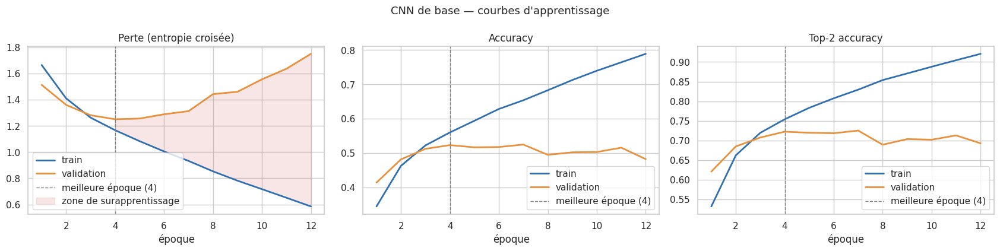

In [ ]:
h = history.history
ep = np.arange(1, len(h["loss"]) + 1)
best = int(np.argmin(h["val_loss"])) + 1

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
for ax, key, title in zip(axes, ["loss", "accuracy", "top2_accuracy"],
                          ["Perte (entropie croisée)", "Accuracy", "Top-2 accuracy"]):
    ax.plot(ep, h[key], label="train", color="#2f6fb0", lw=2)
    ax.plot(ep, h["val_" + key], label="validation", color="#e8913c", lw=2)
    ax.axvline(best, color="grey", ls="--", lw=1, label=f"meilleure époque ({best})")
    ax.set_title(title); ax.set_xlabel("époque"); ax.legend()
axes[0].fill_between(ep[best - 1:], h["loss"][best - 1:], h["val_loss"][best - 1:],
                     color="#c0392b", alpha=0.12, label="zone de surapprentissage")
axes[0].legend()
plt.suptitle("CNN de base — courbes d'apprentissage", fontsize=13)
plt.tight_layout(); plt.show()

### 4.4 Diagnostic automatique du surapprentissage

Le **surapprentissage** (*overfitting*) se produit quand le réseau apprend des particularités des images
d'entraînement (bruit, détails propres à chaque photo) au lieu de règles générales. Signes sur les courbes :
- la perte d'entraînement **continue de baisser** ;
- la perte de validation **arrête de baisser puis remonte** ;
- l'écart entre accuracy d'entraînement et de validation **se creuse**.

   époque                    moment  loss train  loss val  acc train  acc val  \
0       1                     début       1.665     1.514      0.344    0.414   
1       4  meilleure (val_loss min)       1.167     1.251      0.560    0.523   
2      12     fin de l'entraînement       0.585     1.751      0.789    0.482   

   écart acc (train - val)  
0                   -0.069  
1                    0.037  
2                    0.307  
La perte de validation est minimale à l'époque 4 (1.251), puis remonte de +0.499 jusqu'à la fin.
Pendant ce temps, la perte d'entraînement passe de 1.167 à 0.585.
=> SURAPPRENTISSAGE après l'époque 4 : le réseau continue de progresser sur le train mais se dégrade sur la validation.


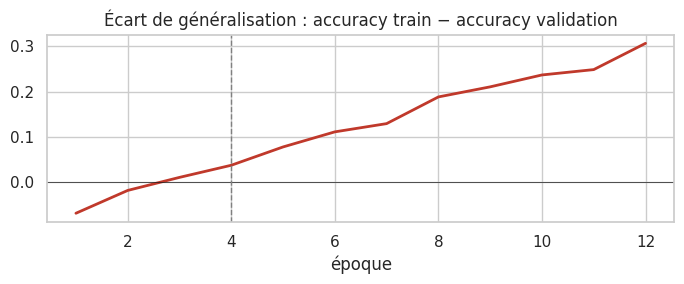

In [ ]:
gap_acc = np.array(h["accuracy"]) - np.array(h["val_accuracy"])
diag = pd.DataFrame({
    "époque": [1, best, len(ep)],
    "moment": ["début", "meilleure (val_loss min)", "fin de l'entraînement"],
    "loss train": [h["loss"][i] for i in (0, best - 1, len(ep) - 1)],
    "loss val": [h["val_loss"][i] for i in (0, best - 1, len(ep) - 1)],
    "acc train": [h["accuracy"][i] for i in (0, best - 1, len(ep) - 1)],
    "acc val": [h["val_accuracy"][i] for i in (0, best - 1, len(ep) - 1)],
    "écart acc (train - val)": [gap_acc[i] for i in (0, best - 1, len(ep) - 1)],
}).round(3)
display(diag) if "display" in globals() else print(diag)

rise = h["val_loss"][-1] - min(h["val_loss"])
print(f"La perte de validation est minimale à l'époque {best} ({min(h['val_loss']):.3f}), "
      f"puis remonte de {rise:+.3f} jusqu'à la fin.")
print(f"Pendant ce temps, la perte d'entraînement passe de {h['loss'][best-1]:.3f} à {h['loss'][-1]:.3f}.")
if rise > 0.05 and h["loss"][-1] < h["loss"][best - 1]:
    print("=> SURAPPRENTISSAGE après l'époque", best,
          ": le réseau continue de progresser sur le train mais se dégrade sur la validation.")
else:
    print("=> Pas de surapprentissage marqué sur cette durée d'entraînement.")

plt.figure(figsize=(7, 3))
plt.plot(ep, gap_acc, color="#c0392b", lw=2)
plt.axhline(0, color="k", lw=0.5); plt.axvline(best, color="grey", ls="--", lw=1)
plt.title("Écart de généralisation : accuracy train − accuracy validation"); plt.xlabel("époque")
plt.tight_layout(); plt.show()

### 4.5 Comparaison avec le modèle de référence (validation)

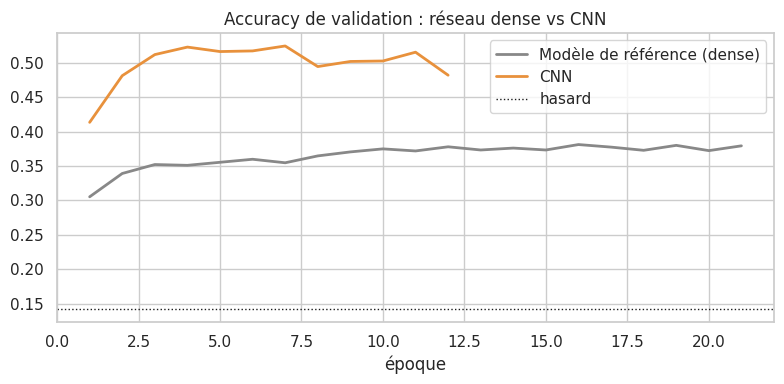

                             paramètres  meilleure val_loss  \
Modèle de référence (dense)      591879               1.596   
CNN de base                      683527               1.251   

                             val accuracy (meilleure époque)  
Modèle de référence (dense)                            0.381  
CNN de base                                            0.523  


In [ ]:
ref_path = os.path.join(SAVE_DIR, "historique_reference.json")
best_cnn_acc = h["val_accuracy"][best - 1]
if os.path.exists(ref_path):
    with open(ref_path) as f:
        href = json.load(f)
    best_ref = int(np.argmin(href["val_loss"]))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.arange(1, len(href["val_accuracy"]) + 1), href["val_accuracy"], color="#888", lw=2,
            label="Modèle de référence (dense)")
    ax.plot(ep, h["val_accuracy"], color="#e8913c", lw=2, label="CNN")
    ax.axhline(1 / NUM_CLASSES, color="k", ls=":", lw=1, label="hasard")
    ax.set_title("Accuracy de validation : réseau dense vs CNN"); ax.set_xlabel("époque"); ax.legend()
    plt.tight_layout(); plt.show()
    comp = pd.DataFrame({
        "paramètres": [48*48*256 + 256 + 256*7 + 7, cnn.count_params()],
        "meilleure val_loss": [href["val_loss"][best_ref], min(h["val_loss"])],
        "val accuracy (meilleure époque)": [href["val_accuracy"][best_ref], best_cnn_acc],
    }, index=["Modèle de référence (dense)", "CNN de base"]).round(3)
    display(comp) if "display" in globals() else print(comp)
else:
    print("Historique du modèle de référence introuvable : exécuter la Partie 2 pour la comparaison.")

### 4.6 Ce que le réseau a appris : filtres et feature maps

Après entraînement, on peut observer :
1. les **32 filtres 3 × 3 de la première couche** (des poids appris, et non choisis à la main comme en Partie 3) ;
2. les **feature maps** produites par chaque bloc pour un visage : de plus en plus petites et abstraites.

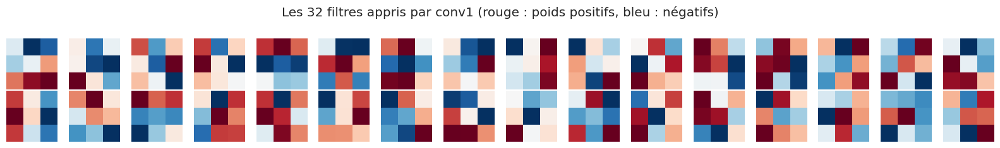

In [ ]:
W = cnn.get_layer("conv1").get_weights()[0][:, :, 0, :]      # (3, 3, 32)
fig, axes = plt.subplots(2, 16, figsize=(16, 2.4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(W[:, :, i], cmap="RdBu_r"); ax.axis("off")
plt.suptitle("Les 32 filtres appris par conv1 (rouge : poids positifs, bleu : négatifs)")
plt.tight_layout(); plt.show()

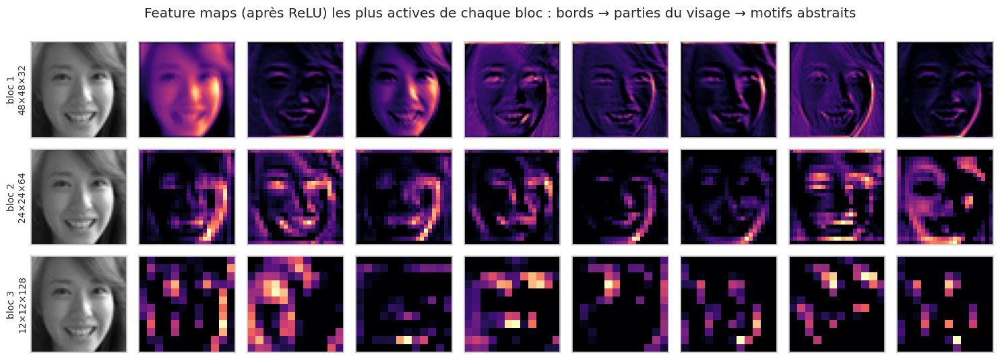

In [ ]:
k_happy = CLASSES.index("happy") if "happy" in CLASSES else 0
face = X_val[np.where(y_val == k_happy)[0][0]]
extractor = keras.Model(cnn.inputs, [cnn.get_layer(n).output for n in ["relu1", "relu2", "relu3"]])
maps = extractor.predict(face[None], verbose=0)

fig, axes = plt.subplots(3, 9, figsize=(15, 5.5))
for row, (fm, name) in enumerate(zip(maps, ["bloc 1", "bloc 2", "bloc 3"])):
    fm = fm[0]
    axes[row, 0].imshow(face[..., 0], cmap="gray")
    axes[row, 0].set_ylabel(f"{name}\n{fm.shape[0]}×{fm.shape[1]}×{fm.shape[2]}", fontsize=10)
    strongest = np.argsort(fm.mean(axis=(0, 1)))[::-1][:8]      # les 8 feature maps les plus actives
    for col, k in enumerate(strongest, start=1):
        axes[row, col].imshow(fm[:, :, k], cmap="magma")
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Feature maps (après ReLU) les plus actives de chaque bloc : bords → parties du visage → motifs abstraits")
plt.tight_layout(); plt.show()

### 4.7 Sauvegarde

In [ ]:
cnn.save(best_path)          # poids de la meilleure époque (restore_best_weights=True)
with open(os.path.join(SAVE_DIR, "historique_cnn_base.json"), "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in h.items()}, f)
print("Modèle :", best_path)
print("Historique :", os.path.join(SAVE_DIR, "historique_cnn_base.json"))

Modèle : /content/drive/MyDrive/projet_dl/cnn_base.keras
Historique : /content/drive/MyDrive/projet_dl/historique_cnn_base.json


### 4.8 Interprétation des courbes

**Résultats obtenus**
- Entraînement très rapide sur GPU : **0,8 min pour 12 époques**. L'Early Stopping s'est arrêté à l'époque 12
  et a restauré les poids de l'**époque 4**, la meilleure.
- À l'époque 4 : accuracy **56,0 % (train) / 52,3 % (validation)**, perte de validation minimale **1,251**.
- Comparé au réseau dense : **52,3 % contre 38,1 %** d'accuracy de validation (+14 points), et une perte de
  validation de 1,251 contre 1,596, avec seulement 15 % de paramètres en plus.

**Déroulement observé sur les courbes**
1. **Époques 1 à 4** : les deux pertes baissent ensemble ; le réseau apprend des caractéristiques utiles à toutes
   les images. Dès l'époque 1, la validation (41,4 %) dépasse déjà le meilleur résultat du réseau dense.
2. **Époque 4** : la perte de validation atteint son minimum (1,251).
3. **Époques 5 à 12 : surapprentissage net.** La perte d'entraînement continue de chuter (1,167 → 0,585) et
   l'accuracy d'entraînement monte à **78,9 %**, tandis que la perte de validation **remonte de +0,50**
   (jusqu'à 1,751) et que l'accuracy de validation **redescend à 48,2 %**. L'écart train − validation passe de
   3,7 points à **30,7 points** : le réseau **mémorise** les images d'entraînement.

**Pourquoi ce surapprentissage, et si tôt ?**
- ≈ 680 000 paramètres pour 24 402 images d'entraînement, dont ≈ 590 000 dans la seule couche Dense après Flatten ;
- aucune régularisation (pas de Dropout, pas d'augmentation de données) ;
- labels bruités dans FER-2013 : à force d'insister, le réseau apprend aussi les erreurs d'étiquetage.

**Ce qui nous protège ici :** l'Early Stopping conserve les poids de l'époque 4, et non ceux de l'époque 12.

**Pistes pour la Partie 6** (une modification à la fois) : Dropout, Data Augmentation, BatchNormalization,
learning rate plus faible, 4ᵉ bloc convolutif, poids de classes pour *Dégoût*.

In [ ]:
# Libère la mémoire avant la Partie 5 : sans cela, les données et modèles des parties précédentes
# s'accumulent en RAM et Colab finit par planter. Aucune perte : chaque partie relit ce dont elle a besoin dans le Drive.
# Après un plantage, reprendre ici avec « Exécution > Exécuter après ».
%reset -f
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()
print("Mémoire libérée — début de la Partie 5")

Mémoire libérée — début de la Partie 5


---
## Partie 5 — Évaluation et analyse des erreurs

On évalue le CNN entraîné en Partie 4 (et le modèle de référence, pour comparaison) sur le **jeu de test**,
jamais vu pendant l'entraînement ni pendant le choix du modèle.

L'accuracy seule ne suffit pas, surtout avec des classes déséquilibrées : on produit une **matrice de
confusion**, des **métriques par classe** (précision, rappel, F1), et on analyse des exemples de prédictions
correctes et incorrectes.

> **Règle respectée :** aucune décision n'est prise à partir de ces résultats de test. Les améliorations de la
> Partie 6 seront choisies sur la **validation** ; le modèle final sera évalué sur le test une seule fois, à la fin.
>
> Prérequis : Parties 1, 2 et 4 exécutées (données, `modele_reference.keras`, `cnn_base.keras` dans le Drive).

### 5.0 Configuration et chargement

In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_recall_fscore_support, f1_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
sns.set_theme(style="white")

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass
SAVE_DIR = "/content/drive/MyDrive/projet_dl" if os.path.isdir("/content/drive/MyDrive") else "."

data = np.load(os.path.join(SAVE_DIR, "fer2013_prepared.npz"))
X_test, y_test = data["X_test"], data["y_test"]
y_train = data["y_train"]
CLASSES = list(data["classes"]); NUM_CLASSES = len(CLASSES)
FR = {"angry": "Colère", "disgust": "Dégoût", "fear": "Peur", "happy": "Joie",
      "neutral": "Neutre", "sad": "Tristesse", "surprise": "Surprise"}
CLASSES_FR = [FR.get(c, c) for c in CLASSES]

cnn = keras.models.load_model(os.path.join(SAVE_DIR, "cnn_base.keras"))
ref_path = os.path.join(SAVE_DIR, "modele_reference.keras")
baseline = keras.models.load_model(ref_path) if os.path.exists(ref_path) else None

print("Jeu de test :", X_test.shape, "| modèles chargés : CNN", "+ référence" if baseline else "(référence absente)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jeu de test : (7178, 48, 48, 1) | modèles chargés : CNN + référence


### 5.1 Prédictions et accuracy globale

Pour chaque image, le réseau renvoie 7 probabilités (Softmax). La **classe prédite** est celle de probabilité
maximale (`argmax`), et la **confiance** est cette probabilité maximale.

In [ ]:
proba_cnn = cnn.predict(X_test, batch_size=256, verbose=0)
y_pred = proba_cnn.argmax(axis=1)
conf = proba_cnn.max(axis=1)

rows = {"Toujours la classe majoritaire": np.full_like(y_test, np.bincount(y_train).argmax())}
if baseline is not None:
    proba_ref = baseline.predict(X_test, batch_size=256, verbose=0)
    rows["Modèle de référence (dense)"] = proba_ref.argmax(axis=1)
rows["CNN de base"] = y_pred

summary = pd.DataFrame({
    "accuracy": [accuracy_score(y_test, p) for p in rows.values()],
    "F1 macro": [f1_score(y_test, p, average="macro", zero_division=0) for p in rows.values()],
    "F1 pondéré": [f1_score(y_test, p, average="weighted", zero_division=0) for p in rows.values()],
}, index=list(rows.keys())).round(3)
top2 = np.mean([y in np.argsort(p)[-2:] for y, p in zip(y_test, proba_cnn)])
print(f"CNN — top-2 accuracy sur le test : {top2:.3f}")
summary

CNN — top-2 accuracy sur le test : 0.724


,accuracy,F1 macro,F1 pondéré
Toujours la classe majoritaire,0.247,0.057,0.098
Modèle de référence (dense),0.391,0.300,0.364
CNN de base,0.530,0.447,0.528


- **F1 macro** : moyenne simple des F1 des 7 classes → chaque classe compte autant, quelle que soit sa taille.
  C'est la métrique qui révèle si les classes rares (*Dégoût*) sont négligées.
- **F1 pondéré** : moyenne pondérée par le nombre d'images de chaque classe → proche de l'accuracy.

Un grand écart entre accuracy et F1 macro signifie que le modèle réussit surtout sur les classes fréquentes.

### 5.2 Matrice de confusion

Ligne = **vraie** classe, colonne = classe **prédite**. La diagonale contient les bonnes réponses.
- version en **nombres** : volumes réels d'erreurs ;
- version **normalisée par ligne** : pour chaque vraie classe, la part des images envoyées dans chaque
  classe prédite. La diagonale est alors le **rappel** de la classe ; c'est la version à commenter, car elle
  n'est pas faussée par le déséquilibre.

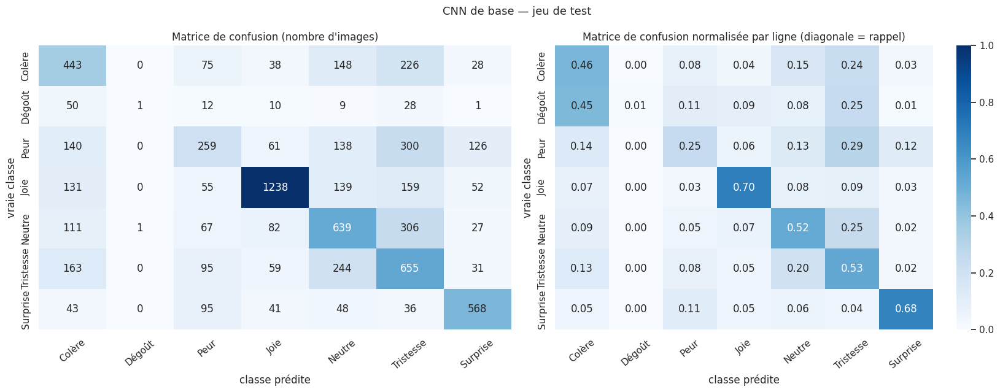

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=range(NUM_CLASSES))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES_FR, yticklabels=CLASSES_FR,
            cbar=False, ax=axes[0])
axes[0].set_title("Matrice de confusion (nombre d'images)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=CLASSES_FR, yticklabels=CLASSES_FR, ax=axes[1])
axes[1].set_title("Matrice de confusion normalisée par ligne (diagonale = rappel)")
for ax in axes:
    ax.set_xlabel("classe prédite"); ax.set_ylabel("vraie classe")
    ax.tick_params(axis="x", rotation=40)
plt.suptitle("CNN de base — jeu de test", fontsize=13)
plt.tight_layout(); plt.show()

### 5.3 Performances par expression

- **Précision** : parmi les images que le modèle a classées « Joie », quelle part est vraiment « Joie » ?
  (une précision faible = la classe sert de « fourre-tout ») ;
- **Rappel** : parmi les vraies images « Joie », quelle part a été retrouvée ?
  (un rappel faible = la classe est souvent manquée) ;
- **F1** : moyenne harmonique des deux.

              precision    recall  f1-score   support

      Colère      0.410     0.462     0.435       958
      Dégoût      0.500     0.009     0.018       111
        Peur      0.394     0.253     0.308      1024
        Joie      0.810     0.698     0.750      1774
      Neutre      0.468     0.518     0.492      1233
   Tristesse      0.383     0.525     0.443      1247
    Surprise      0.682     0.684     0.683       831

    accuracy                          0.530      7178
   macro avg      0.521     0.450     0.447      7178
weighted avg      0.545     0.530     0.528      7178



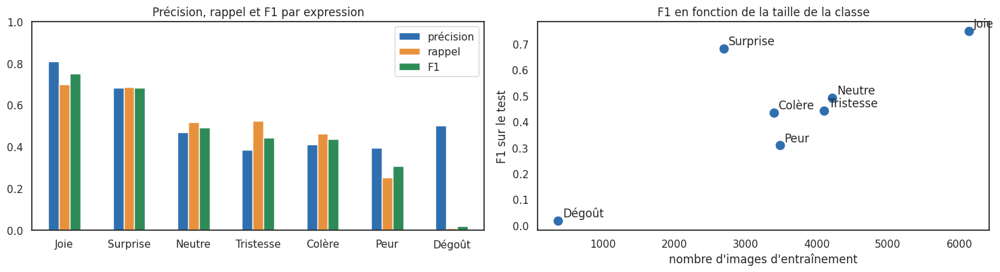

,images (test),images (train),précision,rappel,F1,nb prédictions
Joie,1774,6133,0.810,0.698,0.750,1529
Surprise,831,2695,0.682,0.684,0.683,833
Neutre,1233,4220,0.468,0.518,0.492,1365
Tristesse,1247,4105,0.383,0.525,0.443,1710
Colère,958,3396,0.410,0.462,0.435,1081
Peur,1024,3482,0.394,0.253,0.308,658
Dégoût,111,371,0.500,0.009,0.018,2


In [ ]:
print(classification_report(y_test, y_pred, target_names=CLASSES_FR, digits=3, zero_division=0))

p, r, f, s = precision_recall_fscore_support(y_test, y_pred, labels=range(NUM_CLASSES), zero_division=0)
per_class = pd.DataFrame({"images (test)": s, "images (train)": np.bincount(y_train, minlength=NUM_CLASSES),
                          "précision": p, "rappel": r, "F1": f,
                          "nb prédictions": np.bincount(y_pred, minlength=NUM_CLASSES)},
                         index=CLASSES_FR).round(3).sort_values("F1", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
per_class[["précision", "rappel", "F1"]].plot(kind="bar", ax=axes[0], color=["#2f6fb0", "#e8913c", "#2e8b57"])
axes[0].set_title("Précision, rappel et F1 par expression"); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=0)
axes[1].scatter(per_class["images (train)"], per_class["F1"], s=80, color="#2f6fb0")
for name, row in per_class.iterrows():
    axes[1].annotate(name, (row["images (train)"], row["F1"]), xytext=(5, 4), textcoords="offset points")
axes[1].set_xlabel("nombre d'images d'entraînement"); axes[1].set_ylabel("F1 sur le test")
axes[1].set_title("F1 en fonction de la taille de la classe")
plt.tight_layout(); plt.show()
per_class

### 5.4 Quelles expressions sont fréquemment confondues ?

On classe les cases hors diagonale de la matrice : « vraie classe A prédite comme B ».

In [ ]:
pairs = [(CLASSES_FR[i], CLASSES_FR[j], cm[i, j], cm_norm[i, j])
         for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j]
confusions = (pd.DataFrame(pairs, columns=["vraie classe", "prédite comme", "nb images", "% de la vraie classe"])
              .sort_values("nb images", ascending=False).head(10).reset_index(drop=True))
confusions["% de la vraie classe"] = (100 * confusions["% de la vraie classe"]).round(1)
confusions

,vraie classe,prédite comme,nb images,% de la vraie classe
0,Neutre,Tristesse,306,24.8
1,Peur,Tristesse,300,29.3
2,Tristesse,Neutre,244,19.6
3,Colère,Tristesse,226,23.6
4,Tristesse,Colère,163,13.1
5,Joie,Tristesse,159,9.0
6,Colère,Neutre,148,15.4
7,Peur,Colère,140,13.7
8,Joie,Neutre,139,7.8
9,Peur,Neutre,138,13.5


### 5.5 Exemples de prédictions : image + vraie classe + classe prédite + probabilité

Titre vert = bonne prédiction, rouge = erreur. Sous chaque image, la probabilité de la classe prédite.

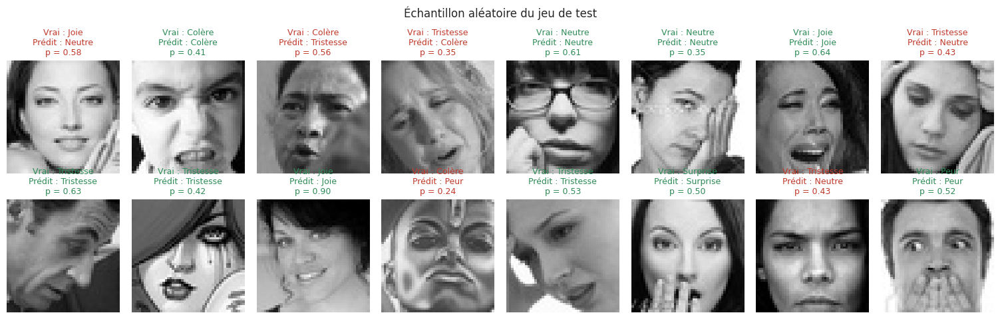

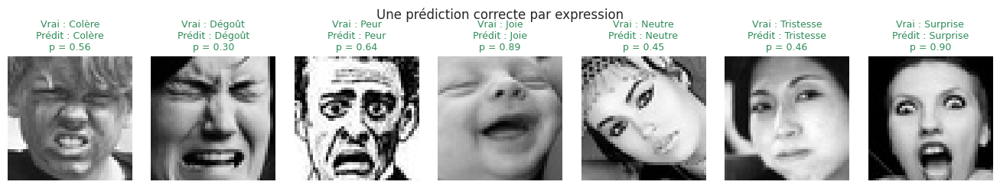

In [ ]:
def show_examples(indices, title, ncols=8):
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.9, nrows * 2.5))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for ax, i in zip(np.atleast_1d(axes).ravel(), indices):
        ok = y_pred[i] == y_test[i]
        ax.imshow(X_test[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Vrai : {CLASSES_FR[y_test[i]]}\nPrédit : {CLASSES_FR[y_pred[i]]}\np = {conf[i]:.2f}",
                     fontsize=9, color="#2e8b57" if ok else "#c0392b")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()

rng = np.random.default_rng(SEED)
show_examples(rng.choice(len(X_test), 16, replace=False), "Échantillon aléatoire du jeu de test")

correct_idx = [rng.choice(np.where((y_test == k) & (y_pred == k))[0])
               for k in range(NUM_CLASSES) if np.any((y_test == k) & (y_pred == k))]
if correct_idx:
    show_examples(correct_idx, "Une prédiction correcte par expression", ncols=len(correct_idx))

### 5.6 Analyse des prédictions incorrectes

On regarde trois types d'erreurs :
1. les **erreurs les plus confiantes** (le modèle se trompe en étant sûr de lui) : souvent des labels douteux
   ou des cas réellement ambigus ;
2. des erreurs sur la **paire la plus confondue** ;
3. le **détail des 7 probabilités** pour quelques erreurs : le modèle hésitait-il entre deux classes ?

3375 erreurs sur 7178 images (47.0%)
Confiance moyenne : 0.63 quand le modèle a raison, 0.46 quand il a tort


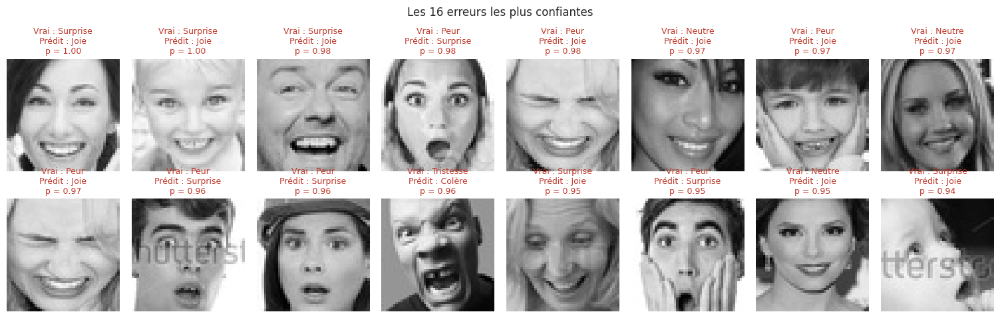

In [ ]:
wrong = np.where(y_pred != y_test)[0]
print(f"{len(wrong)} erreurs sur {len(y_test)} images ({len(wrong) / len(y_test):.1%})")
print(f"Confiance moyenne : {conf[y_pred == y_test].mean():.2f} quand le modèle a raison, "
      f"{conf[wrong].mean():.2f} quand il a tort")

most_confident_wrong = wrong[np.argsort(conf[wrong])[::-1][:16]]
show_examples(most_confident_wrong, "Les 16 erreurs les plus confiantes")

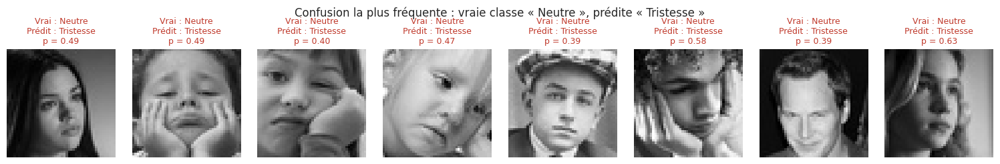

In [ ]:
a, b = confusions.loc[0, "vraie classe"], confusions.loc[0, "prédite comme"]
ia, ib = CLASSES_FR.index(a), CLASSES_FR.index(b)
idx_pair = np.where((y_test == ia) & (y_pred == ib))[0]
if len(idx_pair):
    show_examples(rng.choice(idx_pair, min(8, len(idx_pair)), replace=False),
                  f"Confusion la plus fréquente : vraie classe « {a} », prédite « {b} »")

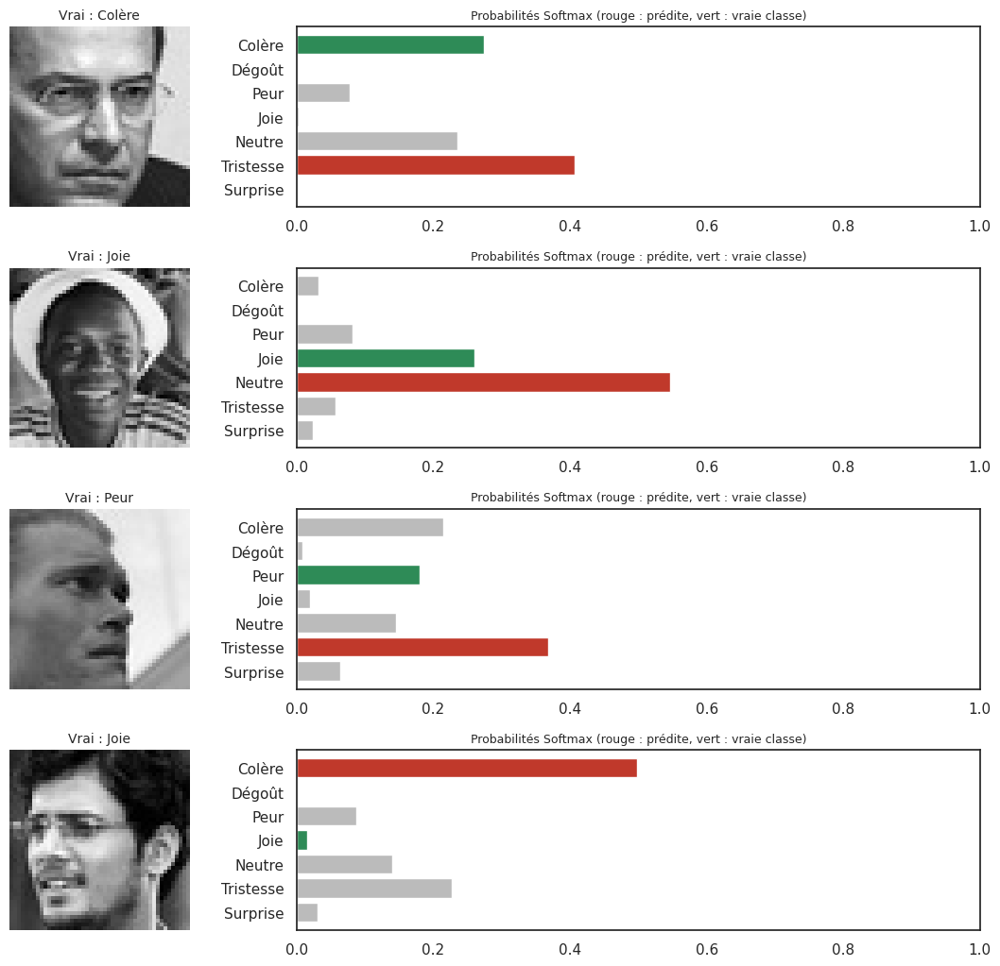

In [ ]:
sample_wrong = rng.choice(wrong, min(4, len(wrong)), replace=False)
fig, axes = plt.subplots(len(sample_wrong), 2, figsize=(11, 2.6 * len(sample_wrong)),
                         gridspec_kw={"width_ratios": [1, 3]})
axes = np.atleast_2d(axes)
for row, i in enumerate(sample_wrong):
    axes[row, 0].imshow(X_test[i, :, :, 0], cmap="gray"); axes[row, 0].axis("off")
    axes[row, 0].set_title(f"Vrai : {CLASSES_FR[y_test[i]]}", fontsize=10)
    colors = ["#c0392b" if k == y_pred[i] else "#2e8b57" if k == y_test[i] else "#bbb" for k in range(NUM_CLASSES)]
    axes[row, 1].barh(CLASSES_FR, proba_cnn[i], color=colors)
    axes[row, 1].set_xlim(0, 1); axes[row, 1].invert_yaxis()
    axes[row, 1].set_title("Probabilités Softmax (rouge : prédite, vert : vraie classe)", fontsize=9)
plt.tight_layout(); plt.show()

### 5.7 Confiance et justesse

Si le modèle est bien calibré, plus sa confiance est élevée, plus il a raison. On regroupe les prédictions par
tranche de confiance et on mesure l'accuracy dans chaque tranche. Ce point sera utile pour la démonstration
(Parties 8–9) : on pourra afficher « incertain » quand la confiance est faible.

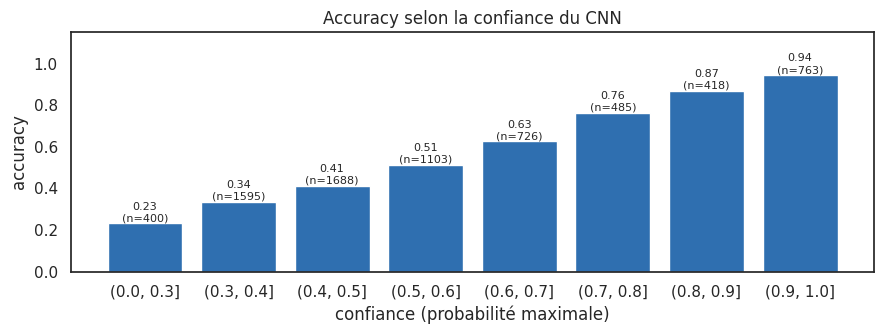

In [ ]:
bins = [0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
cut = pd.cut(conf, bins)
calib = pd.DataFrame({"correct": y_pred == y_test, "tranche": cut}).groupby("tranche", observed=True)["correct"].agg(["mean", "size"])
calib.columns = ["accuracy dans la tranche", "nb images"]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(calib.index.astype(str), calib["accuracy dans la tranche"], color="#2f6fb0")
for i, (acc, n) in enumerate(zip(calib["accuracy dans la tranche"], calib["nb images"])):
    ax.text(i, acc, f"{acc:.2f}\n(n={n})", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 1.15); ax.set_xlabel("confiance (probabilité maximale)"); ax.set_ylabel("accuracy")
ax.set_title("Accuracy selon la confiance du CNN")
plt.tight_layout(); plt.show()

### 5.8 Comparaison des matrices de confusion : réseau dense vs CNN

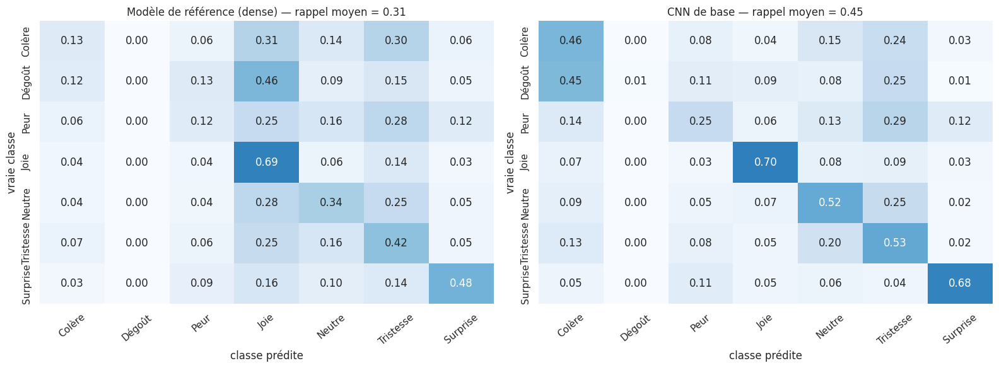

           rappel dense  rappel CNN   gain
Colère            0.128       0.462  0.334
Dégoût            0.000       0.009  0.009
Peur              0.123       0.253  0.130
Joie              0.688       0.698  0.010
Neutre            0.341       0.518  0.178
Tristesse         0.415       0.525  0.110
Surprise          0.481       0.684  0.202


In [ ]:
if baseline is not None:
    cm_ref = confusion_matrix(y_test, proba_ref.argmax(axis=1), labels=range(NUM_CLASSES))
    cm_ref = cm_ref / cm_ref.sum(axis=1, keepdims=True).clip(min=1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, m, t in zip(axes, [cm_ref, cm_norm], ["Modèle de référence (dense)", "CNN de base"]):
        sns.heatmap(m, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False,
                    xticklabels=CLASSES_FR, yticklabels=CLASSES_FR, ax=ax)
        ax.set_title(f"{t} — rappel moyen = {np.mean(np.diag(m)):.2f}")
        ax.set_xlabel("classe prédite"); ax.set_ylabel("vraie classe"); ax.tick_params(axis="x", rotation=40)
    plt.tight_layout(); plt.show()
    gain = pd.DataFrame({"rappel dense": np.diag(cm_ref), "rappel CNN": np.diag(cm_norm)}, index=CLASSES_FR)
    gain["gain"] = gain["rappel CNN"] - gain["rappel dense"]
    display(gain.round(3)) if "display" in globals() else print(gain.round(3))

### 5.9 Sauvegarde des résultats

In [ ]:
per_class.to_csv(os.path.join(SAVE_DIR, "resultats_test_par_classe_cnn_base.csv"))
summary.to_csv(os.path.join(SAVE_DIR, "resultats_test_global.csv"))
print("Résultats enregistrés dans", SAVE_DIR)

Résultats enregistrés dans /content/drive/MyDrive/projet_dl


### 5.10 Analyse

**Résultats globaux sur le test (7 178 images)**
- CNN de base : **accuracy 53,0 %**, F1 macro **0,447**, top-2 accuracy **72,4 %**.
- Réseau dense : accuracy 39,1 %, F1 macro 0,300 ; toujours « Joie » : 24,7 %.
- 3 375 erreurs (47 %). La top-2 accuracy (72,4 %) montre qu'une bonne partie des erreurs sont des
  hésitations : la bonne réponse est souvent le 2ᵉ choix du modèle.

**Expressions bien reconnues**
- **Joie** : F1 0,750 (précision 81 %, rappel 70 %). Classe la plus fréquente et signe visuel très net (sourire).
- **Surprise** : F1 0,683 (rappel 68 %) : bouche ouverte en « O », sourcils levés, yeux écarquillés.

**Expressions difficiles**
- **Peur** : F1 0,308 seulement, rappel 25,3 % : la plupart des visages apeurés sont classés ailleurs.
- **Dégoût** : F1 0,018, rappel 0,9 % : le modèle ne l'a prédit que **2 fois** sur tout le test (111 vraies
  images). Avec 371 images d'entraînement seulement (1,5 %), il a appris qu'il est « rentable » de ne jamais le
  prédire. C'est ce que la Partie 6 tente de corriger avec les poids de classes.

**Confusions les plus fréquentes** (matrice de confusion et tableau 5.4)
1. Neutre → Tristesse : 306 images (24,8 % des visages neutres) ;
2. Peur → Tristesse : 300 images (29,3 % des visages apeurés) ;
3. Tristesse → Neutre : 244 images (19,6 %) ;
4. Colère → Tristesse : 226 images (23,6 %).

**Tristesse sert de classe « refuge »** : elle est prédite 1 710 fois pour 1 247 vraies images, d'où sa faible
précision (38 %). Les expressions « fermées » ou peu marquées (neutre, peur, colère contenue) partagent des traits
avec la tristesse : bouche fermée, sourcils rapprochés, regard baissé. À 48 × 48 pixels, ces nuances sont faibles.
La confusion Tristesse ↔ Neutre est la plus naturelle : une tristesse légère ressemble à un visage neutre.

**Analyse des erreurs les plus confiantes** (figure 5.6)
- Beaucoup sont des **labels discutables** : plusieurs visages étiquetés « Surprise », « Peur » ou « Neutre »
  sourient franchement, et le modèle répond « Joie » avec une confiance de 0,94 à 1,00. Un humain donnerait
  probablement la même réponse que le modèle.
- D'autres sont des **expressions réellement ambiguës** : des visages étiquetés « Peur » (yeux écarquillés, bouche
  ouverte) prédits « Surprise » ; ces deux expressions ne diffèrent que par des détails.
- On trouve aussi des **filigranes** (« shutterstock ») et des visages très rapprochés ou coupés.

**Comparaison avec le réseau dense** : le CNN améliore le rappel de toutes les classes, surtout celles qui dépendent
de détails locaux : Colère +33 points, Surprise +20, Neutre +18, Peur +13, Tristesse +11. Joie (+1) était déjà
reconnue par le réseau dense grâce au sourire, très visible même pixel par pixel.

**Confiance et justesse** (figure 5.7) : le modèle est bien calibré. Quand sa confiance dépasse 0,9, il a raison
dans **94 %** des cas (763 images) ; sous 0,3, dans 23 % des cas seulement. Sa confiance moyenne est de 0,63 quand
il a raison et de 0,46 quand il a tort. Sous 0,4, il a raison moins d'une fois sur trois : c'est ce qui justifie le
seuil « incertain » (0,40) utilisé dans les Parties 8 et 9.

In [ ]:
# Libère la mémoire avant la Partie 6 : sans cela, les données et modèles des parties précédentes
# s'accumulent en RAM et Colab finit par planter. Aucune perte : chaque partie relit ce dont elle a besoin dans le Drive.
# Après un plantage, reprendre ici avec « Exécution > Exécuter après ».
%reset -f
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()
print("Mémoire libérée — début de la Partie 6")

Mémoire libérée — début de la Partie 6


---
## Partie 6 — Expérimentation et amélioration

**Démarche :**
1. on ré-entraîne le CNN de base (**E0**) dans exactement les mêmes conditions que les autres expériences,
   pour avoir une référence équitable ;
2. chaque expérience **E1 à E6 ne modifie qu'un seul élément** par rapport à E0, afin de pouvoir attribuer
   l'effet observé à cette modification ;
3. toutes les comparaisons se font sur la **validation** ;
4. le **modèle final** combine les modifications qui ont amélioré la validation ;
5. le modèle final est évalué **une seule fois** sur le test, à la fin.

| Exp. | Modification (une seule par rapport à E0) | Hypothèse |
|---|---|---|
| E0 | aucune (CNN de base de la Partie 3) | référence |
| E1 | + **Dropout** (0,25 après chaque bloc, 0,5 avant la sortie) | moins de surapprentissage |
| E2 | + **BatchNormalization** après chaque convolution | entraînement plus rapide et plus stable |
| E3 | + **Data Augmentation** (miroir, rotation, zoom, décalage) | meilleure généralisation |
| E4 | + **poids de classes** | meilleur rappel des classes rares (*Dégoût*) |
| E5 | **4ᵉ bloc** convolutif (256 filtres) | caractéristiques plus riches, moins de paramètres Dense |
| E6 | **learning rate** 1e-4 au lieu de 1e-3 | convergence plus douce |

**Critère principal de comparaison : le F1 macro sur la validation**, car il donne le même poids aux 7 classes
(l'accuracy favorise les classes fréquentes, cf. Partie 5). L'accuracy de validation est aussi reportée.

**Protocole commun :** Adam, batch 64, 60 époques max, Early Stopping (patience 10, meilleurs poids conservés),
même graine aléatoire. Les résultats sont enregistrés dans le Drive au fur et à mesure : si Colab se
déconnecte, relancer le notebook reprend là où il s'était arrêté.

> ⏱️ Durée totale sur GPU T4 : environ 30 à 45 minutes. Prérequis : Partie 1 exécutée (et Parties 2 et 4 pour la comparaison finale).

### 6.0 Configuration et chargement

In [ ]:
import os, json, time, random, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score, recall_score, accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)
set_seed()

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass
SAVE_DIR = "/content/drive/MyDrive/projet_dl" if os.path.isdir("/content/drive/MyDrive") else "."
EXP_DIR = os.path.join(SAVE_DIR, "experiences"); os.makedirs(EXP_DIR, exist_ok=True)

data = np.load(os.path.join(SAVE_DIR, "fer2013_prepared.npz"))
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]          # utilisé UNE fois, en 6.8
CLASSES = list(data["classes"]); NUM_CLASSES = len(CLASSES)
FR = {"angry": "Colère", "disgust": "Dégoût", "fear": "Peur", "happy": "Joie",
      "neutral": "Neutre", "sad": "Tristesse", "surprise": "Surprise"}
CLASSES_FR = [FR.get(c, c) for c in CLASSES]
K_DISGUST = CLASSES.index("disgust") if "disgust" in CLASSES else 0

y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh = keras.utils.to_categorical(y_val, NUM_CLASSES)

EPOCHS, PATIENCE, BATCH_SIZE = 60, 10, 64
print("GPU :", tf.config.list_physical_devices("GPU") or "aucun")
print("Train :", X_train.shape, "| Validation :", X_val.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train : (24402, 48, 48, 1) | Validation : (4307, 48, 48, 1)


### 6.1 Le modèle paramétrable

On reprend la fonction `build_cnn` de la Partie 3, avec en plus une option de **Data Augmentation**.
Les couches d'augmentation (`RandomFlip`, `RandomRotation`…) ne sont **actives que pendant l'entraînement** :
à la prédiction (validation, test, démonstration), elles laissent l'image inchangée.

In [ ]:
def augmentation_block():
    return keras.Sequential([
        layers.RandomFlip("horizontal"),                 # miroir : une expression est symétrique
        layers.RandomRotation(0.05),                     # ± 18° environ
        layers.RandomZoom(0.1),                          # ± 10 %
        layers.RandomTranslation(0.1, 0.1),              # décalage de ± 10 %
    ], name="augmentation")

def build_cnn(filters=(32, 64, 128), kernel_size=3, dense_units=128, dropout=0.0,
              batch_norm=False, augment=False, input_shape=(48, 48, 1),
              num_classes=NUM_CLASSES, name="cnn"):
    model = keras.Sequential(name=name)
    model.add(keras.Input(shape=input_shape))
    if augment:
        model.add(augmentation_block())
    for i, f in enumerate(filters, start=1):
        model.add(layers.Conv2D(f, kernel_size, padding="same", name=f"conv{i}"))
        if batch_norm:
            model.add(layers.BatchNormalization(name=f"bn{i}"))
        model.add(layers.ReLU(name=f"relu{i}"))
        model.add(layers.MaxPooling2D(2, name=f"pool{i}"))
        if dropout:
            model.add(layers.Dropout(dropout / 2, name=f"drop{i}"))
    model.add(layers.Flatten(name="flatten"))
    model.add(layers.Dense(dense_units, activation="relu", name="dense"))
    if dropout:
        model.add(layers.Dropout(dropout, name="drop_dense"))
    model.add(layers.Dense(num_classes, name="logits"))
    model.add(layers.Softmax(name="softmax"))
    return model

#### Aperçu de la Data Augmentation

Chaque époque, le réseau voit des **variantes légèrement différentes** des mêmes visages. Il ne peut plus
mémoriser une image pixel par pixel et doit apprendre ce qui caractérise l'expression, quelle que soit la
position exacte ou l'orientation du visage. Les transformations restent **réalistes** : pas de retournement
vertical (un visage à l'envers n'existe pas dans nos données) ni de rotation forte.

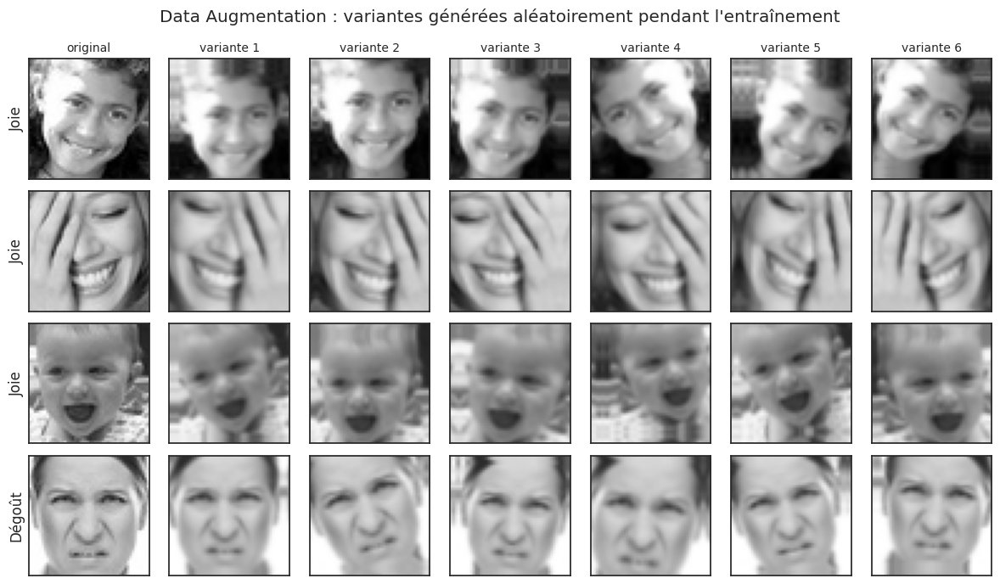

In [ ]:
aug = augmentation_block()
idx = np.random.default_rng(SEED).choice(len(X_train), 4, replace=False)
fig, axes = plt.subplots(4, 7, figsize=(12, 7))
for r, i in enumerate(idx):
    axes[r, 0].imshow(X_train[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[r, 0].set_title("original" if r == 0 else "", fontsize=10)
    axes[r, 0].set_ylabel(CLASSES_FR[y_train[i]])
    for c in range(1, 7):
        axes[r, c].imshow(aug(X_train[i:i + 1], training=True)[0, :, :, 0], cmap="gray", vmin=0, vmax=1)
        if r == 0:
            axes[r, c].set_title(f"variante {c}", fontsize=10)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Data Augmentation : variantes générées aléatoirement pendant l'entraînement")
plt.tight_layout(); plt.show()

#### Poids de classes (E4)

$w_k = \dfrac{N}{K \times N_k}$ : une erreur sur une image de *Dégoût* coûte beaucoup plus cher dans la perte
qu'une erreur sur une image de *Joie*, ce qui pousse le réseau à ne plus ignorer les classes rares.

In [ ]:
cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(cw)}
pd.DataFrame({"images (train)": np.bincount(y_train, minlength=NUM_CLASSES), "poids": cw.round(2)}, index=CLASSES_FR)

,images (train),poids
Colère,3396,1.03
Dégoût,371,9.40
Peur,3482,1.00
Joie,6133,0.57
Neutre,4220,0.83
Tristesse,4105,0.85
Surprise,2695,1.29


### 6.2 Fonction d'expérience

Une seule fonction entraîne, mesure et enregistre chaque expérience : le protocole est **identique** pour toutes.
Mesures relevées à la **meilleure époque** (perte de validation minimale) :
accuracy train / validation, écart (indicateur de surapprentissage), perte de validation, **F1 macro**
et **rappel de *Dégoût*** sur la validation, nombre de paramètres et durée.

In [ ]:
RESULTS_PATH = os.path.join(EXP_DIR, "resultats_experiences.json")
results = json.load(open(RESULTS_PATH)) if os.path.exists(RESULTS_PATH) else {}

def run_experiment(name, modification, build_kwargs=None, lr=1e-3, class_weight=None,
                   epochs=EPOCHS, patience=PATIENCE, reduce_lr=False, force=False):
    if name in results and not force:
        print(f"{name} déjà réalisée (résultats chargés depuis le Drive).")
        return results[name]
    keras.backend.clear_session(); gc.collect()      # libère la mémoire des expériences précédentes
    set_seed()
    model = build_cnn(name=name, **(build_kwargs or {}))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="categorical_crossentropy", metrics=["accuracy"])
    cbs = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)]
    if reduce_lr:
        cbs.append(keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1))
    t0 = time.time()
    hist = model.fit(X_train, y_train_oh, validation_data=(X_val, y_val_oh), epochs=epochs,
                     batch_size=BATCH_SIZE, class_weight=class_weight, callbacks=cbs, verbose=2).history
    duration = (time.time() - t0) / 60
    best = int(np.argmin(hist["val_loss"]))
    y_pred = model.predict(X_val, batch_size=256, verbose=0).argmax(axis=1)
    res = {
        "modification": modification,
        "paramètres": int(model.count_params()),
        "époques": len(hist["loss"]), "meilleure époque": best + 1,
        "acc train": hist["accuracy"][best], "acc val": hist["val_accuracy"][best],
        "écart train-val": hist["accuracy"][best] - hist["val_accuracy"][best],
        "loss val": hist["val_loss"][best],
        "F1 macro val": float(f1_score(y_val, y_pred, average="macro", zero_division=0)),
        "rappel Dégoût val": float(recall_score(y_val, y_pred, labels=[K_DISGUST], average="macro", zero_division=0)),
        "durée (min)": duration,
        "history": {k: [float(v) for v in vals] for k, vals in hist.items()},
        "config": {"build_kwargs": build_kwargs or {}, "lr": lr, "class_weight": class_weight is not None},
    }
    model.save(os.path.join(EXP_DIR, f"{name}.keras"))
    results[name] = res
    json.dump(results, open(RESULTS_PATH, "w"))
    print(f"\n{name} : acc val = {res['acc val']:.3f} | F1 macro val = {res['F1 macro val']:.3f} "
          f"| écart = {res['écart train-val']:.3f} | {duration:.1f} min")
    return res

### 6.3 Lancement des expériences

In [ ]:
EXPERIENCES = [
    ("E0", "Aucune (CNN de base)",                  dict(build_kwargs={})),
    ("E1", "+ Dropout (0,25 / 0,5)",                dict(build_kwargs={"dropout": 0.5})),
    ("E2", "+ BatchNormalization",                  dict(build_kwargs={"batch_norm": True})),
    ("E3", "+ Data Augmentation",                   dict(build_kwargs={"augment": True})),
    ("E4", "+ Poids de classes",                    dict(build_kwargs={}, class_weight=CLASS_WEIGHTS)),
    ("E5", "4ᵉ bloc convolutif (256 filtres)",      dict(build_kwargs={"filters": (32, 64, 128, 256)})),
    ("E6", "Learning rate 1e-4 (au lieu de 1e-3)",  dict(build_kwargs={}, lr=1e-4)),
]
for name, modification, kwargs in EXPERIENCES:
    print("=" * 80, f"\n{name} — {modification}\n", "=" * 80, sep="")
    run_experiment(name, modification, **kwargs)

E0 — Aucune (CNN de base)
E0 déjà réalisée (résultats chargés depuis le Drive).
E1 — + Dropout (0,25 / 0,5)
E1 déjà réalisée (résultats chargés depuis le Drive).
E2 — + BatchNormalization
E2 déjà réalisée (résultats chargés depuis le Drive).
E3 — + Data Augmentation
E3 déjà réalisée (résultats chargés depuis le Drive).
E4 — + Poids de classes
E4 déjà réalisée (résultats chargés depuis le Drive).
E5 — 4ᵉ bloc convolutif (256 filtres)
E5 déjà réalisée (résultats chargés depuis le Drive).
E6 — Learning rate 1e-4 (au lieu de 1e-3)
E6 déjà réalisée (résultats chargés depuis le Drive).


### 6.4 Tableau comparatif (validation)

Les colonnes Δ donnent la différence avec E0 (CNN de base ré-entraîné : F1 macro 0,454, accuracy 53,2 %).

**Lecture des résultats**
- **E1 Dropout** : la meilleure expérience. F1 macro **+5,5 pts** (0,509), accuracy 57,1 % (+3,9 pts), écart
  train/validation réduit de 6,3 à 3,2 pts. Meilleure époque 25 au lieu de 5 : le réseau apprend plus longtemps
  sans surapprendre.
- **E3 Data Augmentation** : **+4,9 pts** (0,503), accuracy 56,5 %, écart 3,8 pts. Meilleure époque 40 : la tâche
  devient plus difficile (images modifiées à chaque époque), donc la convergence est plus lente mais plus robuste.
- **E4 Poids de classes** : F1 macro +0,7 pt seulement et accuracy −3,7 pts, mais le rappel de *Dégoût* passe de
  1,5 % à **36,9 %** : le modèle cesse d'ignorer la classe rare, au prix d'erreurs sur les autres.
- **E6 Learning rate 1e-4** : +1,6 pt, mais apprentissage plus lent (meilleure époque 22) et surapprentissage accru
  (écart 10,1 pts).
- **E2 BatchNormalization** (−1,1 pt) et **E5 4ᵉ bloc** (−1,0 pt) : pas d'amélioration ; même niveau de
  surapprentissage que E0.

In [ ]:
def observation(r, ref):
    obs = []
    d_f1, d_acc, d_gap = r["F1 macro val"] - ref["F1 macro val"], r["acc val"] - ref["acc val"], r["écart train-val"] - ref["écart train-val"]
    obs.append(f"F1 macro {'+' if d_f1 >= 0 else ''}{100 * d_f1:.1f} pts")
    if abs(d_gap) > 0.03:
        obs.append("surapprentissage " + ("réduit" if d_gap < 0 else "accru") + f" (écart {100 * d_gap:+.0f} pts)")
    if abs(r["rappel Dégoût val"] - ref["rappel Dégoût val"]) > 0.05:
        obs.append(f"rappel Dégoût {ref['rappel Dégoût val']:.2f} → {r['rappel Dégoût val']:.2f}")
    if r["meilleure époque"] > 1.5 * ref["meilleure époque"]:
        obs.append("converge plus lentement")
    elif r["meilleure époque"] < 0.67 * ref["meilleure époque"]:
        obs.append("converge plus vite")
    return " ; ".join(obs)

def results_table(names):
    ref = results["E0"]
    rows = []
    for n in names:
        r = results[n]
        rows.append({"exp.": n, "modification": r["modification"], "paramètres": r["paramètres"],
                     "meilleure époque": r["meilleure époque"], "acc train": r["acc train"],
                     "acc val": r["acc val"], "Δ acc val": r["acc val"] - ref["acc val"],
                     "écart train-val": r["écart train-val"], "loss val": r["loss val"],
                     "F1 macro val": r["F1 macro val"], "Δ F1 macro": r["F1 macro val"] - ref["F1 macro val"],
                     "rappel Dégoût": r["rappel Dégoût val"], "durée (min)": r["durée (min)"],
                     "observation": observation(r, ref) if n != "E0" else "référence"})
    return pd.DataFrame(rows).set_index("exp.").round(3)

names = [e[0] for e in EXPERIENCES if e[0] in results]
table = results_table(names)
table.drop(columns="observation").to_csv(os.path.join(EXP_DIR, "tableau_experiences.csv"))
pd.set_option("display.max_colwidth", 80)
table

,modification,paramètres,meilleure époque,acc train,acc val,Δ acc val,écart train-val,loss val,F1 macro val,Δ F1 macro,rappel Dégoût,durée (min),observation
exp.,,,,,,,,,,,,,
E0,Aucune (CNN de base),683527,5,0.595,0.532,0.000,0.063,1.279,0.454,0.000,0.015,0.875,référence
E1,"+ Dropout (0,25 / 0,5)",683527,25,0.603,0.571,0.039,0.032,1.148,0.509,0.055,0.154,2.178,F1 macro +5.5 pts ; surapprentissage réduit (écart -3 pts) ; rappel Dégoût 0...
E2,+ BatchNormalization,684423,5,0.596,0.525,-0.007,0.071,1.282,0.443,-0.011,0.000,1.138,F1 macro -1.1 pts
E3,+ Data Augmentation,683527,40,0.604,0.565,0.033,0.038,1.159,0.503,0.049,0.154,3.756,F1 macro +4.9 pts ; rappel Dégoût 0.02 → 0.15 ; converge plus lentement
E4,+ Poids de classes,683527,5,0.523,0.495,-0.037,0.028,1.351,0.461,0.007,0.369,0.918,F1 macro +0.7 pts ; surapprentissage réduit (écart -3 pts) ; rappel Dégoût 0...
E5,4ᵉ bloc convolutif (256 filtres),683783,5,0.599,0.531,-0.000,0.068,1.256,0.444,-0.010,0.000,1.033,F1 macro -1.0 pts
E6,Learning rate 1e-4 (au lieu de 1e-3),683527,22,0.630,0.530,-0.002,0.101,1.276,0.469,0.016,0.108,1.727,F1 macro +1.6 pts ; surapprentissage accru (écart +4 pts) ; rappel Dégoût 0....


### 6.5 Visualisation des expériences

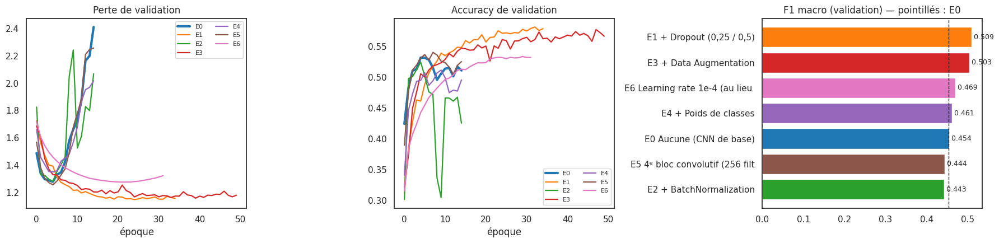

In [ ]:
colors = dict(zip(names, sns.color_palette("tab10", len(names))))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for n in names:
    hst = results[n]["history"]
    lw = 3 if n == "E0" else 1.6
    axes[0].plot(hst["val_loss"], color=colors[n], lw=lw, label=n)
    axes[1].plot(hst["val_accuracy"], color=colors[n], lw=lw, label=n)
axes[0].set_title("Perte de validation"); axes[1].set_title("Accuracy de validation")
for ax in axes[:2]:
    ax.set_xlabel("époque"); ax.legend(ncol=2, fontsize=8)
t = table.sort_values("F1 macro val")
axes[2].barh([f"{i} {m[:28]}" for i, m in zip(t.index, t["modification"])], t["F1 macro val"],
             color=[colors[i] for i in t.index])
axes[2].axvline(results["E0"]["F1 macro val"], color="k", ls="--", lw=1)
axes[2].set_title("F1 macro (validation) — pointillés : E0")
for i, v in enumerate(t["F1 macro val"]):
    axes[2].text(v, i, f" {v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

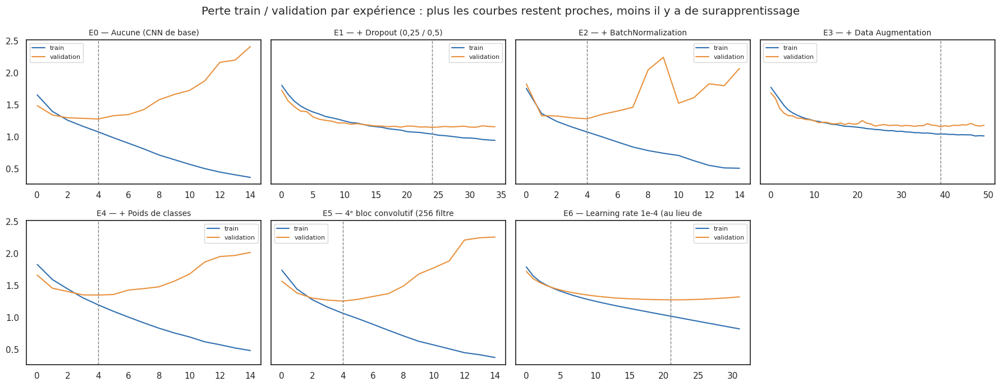

In [ ]:
# Effet sur le surapprentissage : perte train vs validation pour chaque expérience
fig, axes = plt.subplots(2, int(np.ceil(len(names) / 2)), figsize=(18, 7), sharey=True)
for ax, n in zip(axes.ravel(), names):
    hst = results[n]["history"]
    ax.plot(hst["loss"], color="#2f6fb0", label="train"); ax.plot(hst["val_loss"], color="#e8913c", label="validation")
    ax.axvline(results[n]["meilleure époque"] - 1, color="grey", ls="--", lw=1)
    ax.set_title(f"{n} — {results[n]['modification'][:30]}", fontsize=10); ax.legend(fontsize=8)
for ax in axes.ravel()[len(names):]:
    ax.axis("off")
plt.suptitle("Perte train / validation par expérience : plus les courbes restent proches, moins il y a de surapprentissage")
plt.tight_layout(); plt.show()

### 6.6 Choix du modèle final

**Règle de décision (fixée avant de voir les résultats) :** on combine dans le modèle final toutes les
modifications de **régularisation et d'architecture** (E1, E2, E3, E4, E5) qui ont **amélioré le F1 macro de
validation d'au moins 0,5 point** par rapport à E0.

Pour le modèle final, comme il est plus régularisé (il apprend plus lentement), on lui laisse plus de temps :
100 époques max, patience 15, et un **ReduceLROnPlateau** (le learning rate est divisé par 2 quand la perte de
validation stagne, pour affiner la convergence en fin d'entraînement). *(Si E6 montre qu'un learning rate plus
faible aide, c'est ce mécanisme qui en tire parti.)*

In [ ]:
THRESHOLD = 0.005
ref_f1 = results["E0"]["F1 macro val"]
final_kwargs, final_cw, retained = {}, None, []
for name, modification, kwargs in EXPERIENCES:
    if name in ("E0", "E6") or name not in results:
        continue
    gain = results[name]["F1 macro val"] - ref_f1
    keep = gain >= THRESHOLD
    print(f"{name} {modification:40s} Δ F1 macro = {100 * gain:+.1f} pts -> {'retenue' if keep else 'écartée'}")
    if keep:
        retained.append(name)
        final_kwargs.update(kwargs.get("build_kwargs", {}))
        if kwargs.get("class_weight") is not None:
            final_cw = kwargs["class_weight"]

print("\nModifications retenues :", retained or "aucune")
print("Configuration finale :", final_kwargs, "| poids de classes :", final_cw is not None)

E1 + Dropout (0,25 / 0,5)                   Δ F1 macro = +5.5 pts -> retenue
E2 + BatchNormalization                     Δ F1 macro = -1.1 pts -> écartée
E3 + Data Augmentation                      Δ F1 macro = +4.9 pts -> retenue
E4 + Poids de classes                       Δ F1 macro = +0.7 pts -> retenue
E5 4ᵉ bloc convolutif (256 filtres)         Δ F1 macro = -1.0 pts -> écartée

Modifications retenues : ['E1', 'E3', 'E4']
Configuration finale : {'dropout': 0.5, 'augment': True} | poids de classes : True


In [ ]:
final_desc = "Combinaison : " + (", ".join(results[n]["modification"].lstrip("+ ") for n in retained) or "E0") \
             + " + ReduceLROnPlateau"
run_experiment("FINAL", final_desc, build_kwargs=final_kwargs, class_weight=final_cw,
               epochs=100, patience=15, reduce_lr=True)

table_all = results_table(names + ["FINAL"])
table_all.drop(columns="observation").to_csv(os.path.join(EXP_DIR, "tableau_experiences.csv"))
table_all

FINAL déjà réalisée (résultats chargés depuis le Drive).


,modification,paramètres,meilleure époque,acc train,acc val,Δ acc val,écart train-val,loss val,F1 macro val,Δ F1 macro,rappel Dégoût,durée (min),observation
exp.,,,,,,,,,,,,,
E0,Aucune (CNN de base),683527,5,0.595,0.532,0.000,0.063,1.279,0.454,0.000,0.015,0.875,référence
E1,"+ Dropout (0,25 / 0,5)",683527,25,0.603,0.571,0.039,0.032,1.148,0.509,0.055,0.154,2.178,F1 macro +5.5 pts ; surapprentissage réduit (écart -3 pts) ; rappel Dégoût 0...
E2,+ BatchNormalization,684423,5,0.596,0.525,-0.007,0.071,1.282,0.443,-0.011,0.000,1.138,F1 macro -1.1 pts
E3,+ Data Augmentation,683527,40,0.604,0.565,0.033,0.038,1.159,0.503,0.049,0.154,3.756,F1 macro +4.9 pts ; rappel Dégoût 0.02 → 0.15 ; converge plus lentement
E4,+ Poids de classes,683527,5,0.523,0.495,-0.037,0.028,1.351,0.461,0.007,0.369,0.918,F1 macro +0.7 pts ; surapprentissage réduit (écart -3 pts) ; rappel Dégoût 0...
E5,4ᵉ bloc convolutif (256 filtres),683783,5,0.599,0.531,-0.000,0.068,1.256,0.444,-0.010,0.000,1.033,F1 macro -1.0 pts
E6,Learning rate 1e-4 (au lieu de 1e-3),683527,22,0.630,0.530,-0.002,0.101,1.276,0.469,0.016,0.108,1.727,F1 macro +1.6 pts ; surapprentissage accru (écart +4 pts) ; rappel Dégoût 0....
FINAL,"Combinaison : Dropout (0,25 / 0,5), Data Augmentation, Poids de classes + Re...",683527,68,0.399,0.495,-0.037,-0.096,1.340,0.426,-0.028,0.615,7.105,F1 macro -2.8 pts ; surapprentissage réduit (écart -16 pts) ; rappel Dégoût ...


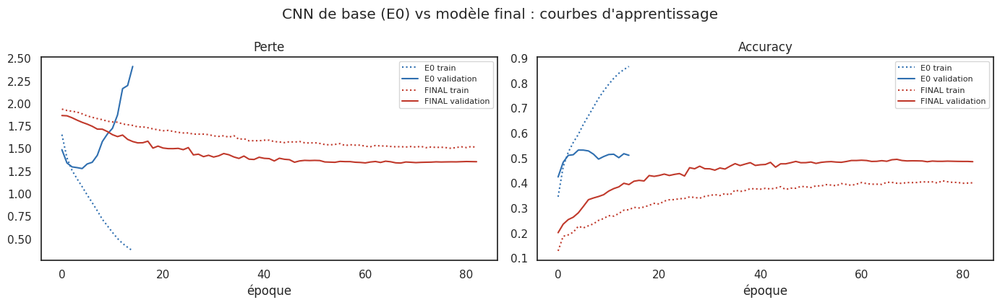

In [ ]:
hst0, hstf = results["E0"]["history"], results["FINAL"]["history"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for ax, key, title in zip(axes, ["loss", "accuracy"], ["Perte", "Accuracy"]):
    ax.plot(hst0[key], color="#2f6fb0", ls=":", label="E0 train"); ax.plot(hst0["val_" + key], color="#2f6fb0", label="E0 validation")
    ax.plot(hstf[key], color="#c0392b", ls=":", label="FINAL train"); ax.plot(hstf["val_" + key], color="#c0392b", label="FINAL validation")
    ax.set_title(title); ax.set_xlabel("époque"); ax.legend(fontsize=8)
plt.suptitle("CNN de base (E0) vs modèle final : courbes d'apprentissage")
plt.tight_layout(); plt.show()

### 6.7 Justification du modèle final

**Ce que la règle a donné**
- Modifications retenues (gain ≥ 0,5 point de F1 macro en validation) : **E1 Dropout (+5,5 pts)**,
  **E3 Data Augmentation (+4,9 pts)** et **E4 Poids de classes (+0,7 pt)**. Écartées : E2 BatchNorm (−1,1 pt) et
  E5 4ᵉ bloc (−1,0 pt) ; E6 (learning rate) n'entrait pas dans la combinaison.
- **Résultat du modèle combiné (FINAL)** : F1 macro de validation **0,426**, *inférieur* à E0 (0,454) et surtout à
  E1 seul (**0,509**). Accuracy de validation 49,5 % contre 53,2 % pour E0 et 57,1 % pour E1.
- Sur le test (6.8) : accuracy **48,6 %**, F1 macro 0,420, contre 53,0 % et 0,447 pour le CNN de base.
  En revanche, le rappel de *Dégoût* passe de **0,9 % à 64,9 %**.

**Pourquoi la combinaison a moins bien marché que chaque modification seule**
1. **Trop de régularisation à la fois** : avec Dropout et augmentation de données ensemble, l'accuracy
   d'entraînement (39,9 %) devient *inférieure* à celle de validation (49,5 %). C'est un signe de
   **sous-apprentissage** : le réseau, trop contraint, n'arrive plus à apprendre assez. (L'accuracy d'entraînement
   est mesurée avec Dropout et augmentation actifs, d'où cet écart négatif.)
2. **Les poids de classes déplacent les erreurs** : *Dégoût* compte 9,4 fois plus dans la perte, donc le modèle le
   prédit beaucoup plus souvent. Son rappel monte à 65 %, mais sa précision tombe à **11 %** (la plupart des
   « Dégoût » prédits sont faux), et le rappel de *Peur* chute à 11 %. C'est un **compromis** : meilleur équilibre
   entre classes rares et fréquentes, mais moins de bonnes réponses au total.

**Le meilleur modèle en validation est E1 (Dropout seul)** : F1 macro 0,509, accuracy 57,1 %, écart train/validation
réduit de 6,3 à 3,2 points. Le Dropout désactive aléatoirement des neurones à chaque pas : le réseau ne peut plus
s'appuyer sur quelques neurones qui mémorisent les images, et il apprend utilement plus longtemps (meilleure époque
25 au lieu de 5).

**Leçon méthodologique** : des améliorations qui marchent seules ne s'additionnent pas forcément. Une combinaison doit
donc être comparée à la meilleure modification seule ; une règle « garder la meilleure configuration en validation,
combinaison comprise » aurait désigné E1. Dans ce notebook, le modèle FINAL a été sauvegardé tel que la règle l'a
choisi ; en Partie 7, MobileNetV2 (F1 de validation 0,440 contre 0,426) l'a ensuite remplacé pour les Parties 8 et 9.

**Ce qui n'a pas marché, et pourquoi**
- **E2 BatchNormalization** (−1,1 pt, écart train/validation inchangé à 7 points) : sur un réseau aussi peu profond
  (3 convolutions), normaliser les activations n'apporte pas grand-chose.
- **E5 4ᵉ bloc** (−1,0 pt) : la sortie passe à 3 × 3, l'information spatiale devient trop réduite pour des images de
  48 × 48, sans gain de généralisation.
- **E6 learning rate 1e-4** (+1,6 pt, mais écart train/validation porté à 10,1 points) : apprentissage 4 fois plus
  lent (meilleure époque 22) et davantage de surapprentissage.

**Limite de la démarche** : chaque expérience n'a été lancée qu'une fois ; des écarts de moins de 1 à 2 points
(E2, E4, E5, E6) peuvent venir du hasard de l'initialisation. Les conclusions solides portent sur les effets nets :
Dropout et augmentation de données (+5 points chacun).

### 6.8 Évaluation finale sur le jeu de test (une seule fois)

Le modèle est désormais figé. On l'évalue sur le test et on le compare au CNN de base et au réseau dense
(évalués en Partie 5 sur les mêmes images).

In [ ]:
final_model = keras.models.load_model(os.path.join(EXP_DIR, "FINAL.keras"))
proba_final = final_model.predict(X_test, batch_size=256, verbose=0)
y_pred_final = proba_final.argmax(axis=1)

models_cmp = {}
for label, fname in [("Réseau dense (Partie 2)", "modele_reference.keras"), ("CNN de base (Partie 4)", "cnn_base.keras")]:
    p = os.path.join(SAVE_DIR, fname)
    if os.path.exists(p):
        models_cmp[label] = keras.models.load_model(p).predict(X_test, batch_size=256, verbose=0).argmax(axis=1)
models_cmp["Modèle final (Partie 6)"] = y_pred_final

test_table = pd.DataFrame({
    "accuracy test": [accuracy_score(y_test, p) for p in models_cmp.values()],
    "F1 macro test": [f1_score(y_test, p, average="macro", zero_division=0) for p in models_cmp.values()],
    "rappel Dégoût test": [recall_score(y_test, p, labels=[K_DISGUST], average="macro", zero_division=0) for p in models_cmp.values()],
}, index=list(models_cmp.keys())).round(3)
test_table.to_csv(os.path.join(SAVE_DIR, "resultats_test_final.csv"))
test_table

,accuracy test,F1 macro test,rappel Dégoût test
Réseau dense (Partie 2),0.391,0.300,0.000
CNN de base (Partie 4),0.530,0.447,0.009
Modèle final (Partie 6),0.486,0.420,0.649


              precision    recall  f1-score   support

      Colère      0.416     0.339     0.374       958
      Dégoût      0.111     0.649     0.189       111
        Peur      0.329     0.114     0.170      1024
        Joie      0.706     0.749     0.726      1774
      Neutre      0.407     0.572     0.475      1233
   Tristesse      0.429     0.283     0.341      1247
    Surprise      0.622     0.712     0.664       831

    accuracy                          0.486      7178
   macro avg      0.431     0.488     0.420      7178
weighted avg      0.495     0.486     0.474      7178



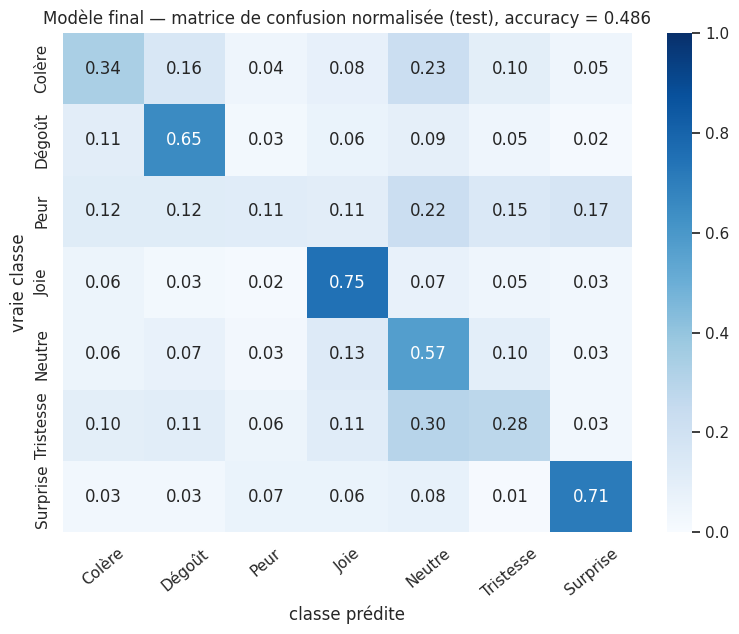

In [ ]:
print(classification_report(y_test, y_pred_final, target_names=CLASSES_FR, digits=3, zero_division=0))
cm = confusion_matrix(y_test, y_pred_final, labels=range(NUM_CLASSES))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=CLASSES_FR, yticklabels=CLASSES_FR)
plt.title(f"Modèle final — matrice de confusion normalisée (test), accuracy = {accuracy_score(y_test, y_pred_final):.3f}")
plt.xlabel("classe prédite"); plt.ylabel("vraie classe"); plt.xticks(rotation=40)
plt.tight_layout(); plt.show()

### 6.9 Sauvegarde du modèle final pour les Parties 8 et 9

On enregistre le modèle et le **prétraitement exact** à appliquer à chaque visage détecté
(niveaux de gris, 48 × 48, pixels / 255), conformément au point d'attention de l'énoncé.

In [ ]:
final_model.save(os.path.join(SAVE_DIR, "modele_final.keras"))
with open(os.path.join(SAVE_DIR, "modele_final_config.json"), "w") as f:
    json.dump({"classes": CLASSES, "classes_fr": CLASSES_FR, "img_size": 48, "grayscale": True,
               "normalisation": "pixels / 255", "config": results["FINAL"]["config"]}, f, ensure_ascii=False, indent=2)
print("Modèle final :", os.path.join(SAVE_DIR, "modele_final.keras"))

Modèle final : /content/drive/MyDrive/projet_dl/modele_final.keras


In [ ]:
# Libère la mémoire avant la Partie 7 : sans cela, les données et modèles des parties précédentes
# s'accumulent en RAM et Colab finit par planter. Aucune perte : chaque partie relit ce dont elle a besoin dans le Drive.
# Après un plantage, reprendre ici avec « Exécution > Exécuter après ».
%reset -f
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()
print("Mémoire libérée — début de la Partie 7")

Mémoire libérée — début de la Partie 7


---
## Partie 7 — Enrichissement avec les nouvelles notions du cours

L'énoncé propose d'enrichir le système avec : Data Augmentation, Transfer Learning et réseaux pré-entraînés,
régularisation, détection d'objets, YOLO. Voici où chaque notion est traitée dans le projet :

| Notion du cours | Où | Ce qui est fait |
|---|---|---|
| Data Augmentation | Partie 6 (E3) + ici | miroir, rotation, zoom, décalage, actifs seulement pendant l'entraînement |
| **Transfer Learning** | **Partie 7 (ce notebook)** | MobileNetV2 pré-entraîné sur ImageNet : extraction de caractéristiques puis fine-tuning |
| Régularisation | Partie 6 (Dropout, BatchNorm, Early Stopping) + **ici (L2)** | pénalité L2 sur les poids, comparée au CNN de base |
| Détection d'objets | Partie 8 | bounding boxes, IoU, NMS, précision/rappel, mAP |
| YOLO | Parties 8 et 9 | YOLOv8 entraîné sur les visages, puis suivi en vidéo |

Ce notebook ajoute donc les deux briques qui manquaient : le **Transfer Learning** (7.1 à 7.7) et la
**régularisation L2** (7.8). On compare ensuite tous les modèles sur la **validation** (7.9), on évalue le modèle
pré-entraîné **une seule fois** sur le test (7.10), et on choisit le classifieur utilisé dans les Parties 8 et 9 (7.11).

> ⚙️ Colab avec **GPU** obligatoire (≈ 30 à 40 min au total sur un T4).
> Prérequis : Partie 1 (données) ; Partie 6 pour les comparaisons (sinon elles sont simplement sautées).

### 7.0 Configuration et chargement

In [3]:
import os, json, time, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import f1_score, recall_score, accuracy_score, confusion_matrix, classification_report

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)
set_seed()

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass
SAVE_DIR = "/content/drive/MyDrive/projet_dl" if os.path.isdir("/content/drive/MyDrive") else "."
TL_DIR = os.path.join(SAVE_DIR, "partie7"); os.makedirs(TL_DIR, exist_ok=True)

data = np.load(os.path.join(SAVE_DIR, "fer2013_prepared.npz"))
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]          # utilisé UNE fois, en 7.10
CLASSES = list(data["classes"]); NUM_CLASSES = len(CLASSES)
FR = {"angry": "Colère", "disgust": "Dégoût", "fear": "Peur", "happy": "Joie",
      "neutral": "Neutre", "sad": "Tristesse", "surprise": "Surprise"}
CLASSES_FR = [FR.get(c, c) for c in CLASSES]
K_DISGUST = CLASSES.index("disgust") if "disgust" in CLASSES else 0

y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh = keras.utils.to_categorical(y_val, NUM_CLASSES)

BATCH_SIZE = 64
WEIGHTS = "imagenet"      # poids pré-entraînés téléchargés automatiquement par Keras
print("GPU :", tf.config.list_physical_devices("GPU") or "aucun (très lent pour cette partie !)")
print("Train :", X_train.shape, "| Validation :", X_val.shape, "| Test :", X_test.shape)

Mounted at /content/drive
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train : (24402, 48, 48, 1) | Validation : (4307, 48, 48, 1) | Test : (7178, 48, 48, 1)


### 7.1 Principe du Transfer Learning

Entraîner un CNN profond depuis zéro demande énormément d'images. Le **Transfer Learning** réutilise un réseau
déjà entraîné sur un très grand jeu de données — ici **ImageNet** (1,28 million d'images, 1 000 classes) :
- ses **premières couches** ont appris des détecteurs génériques (bords, textures, formes) utiles pour presque
  toutes les images, y compris des visages ;
- ses **dernières couches** sont spécialisées pour les 1 000 classes d'ImageNet (chiens, voitures…) : on les
  **remplace** par une nouvelle tête de classification à 7 sorties pour nos expressions.

Deux phases :
1. **Extraction de caractéristiques** : le réseau pré-entraîné est **gelé** (`trainable = False`), on n'entraîne
   que la nouvelle tête. Rapide, et on ne détruit pas ce qui a été appris sur ImageNet avec des gradients
   aléatoires venant d'une tête pas encore entraînée ;
2. **Fine-tuning** : on **dégèle** les dernières couches du réseau et on ré-entraîne l'ensemble avec un
   **learning rate très faible**, pour adapter légèrement les caractéristiques de haut niveau aux visages.

### 7.2 Choix du réseau : MobileNetV2

| Réseau | Paramètres | Commentaire |
|---|---|---|
| VGG16 | 138 M | très lourd, lent |
| ResNet50 | 25 M | performant mais lent sur des images agrandies |
| **MobileNetV2** | **3,5 M** (2,3 M sans la tête) | **léger et rapide** : adapté au GPU gratuit de Colab et à la vidéo temps réel (Partie 9) |
| EfficientNetB0 | 5,3 M | bon compromis, mais plus lent que MobileNetV2 |

MobileNetV2 utilise des **convolutions séparables en profondeur** (*depthwise separable*) : une convolution
3 × 3 appliquée à chaque canal séparément, puis une convolution 1 × 1 qui mélange les canaux. Le résultat est
proche d'une convolution classique, pour 8 à 9 fois moins de calculs.

### 7.3 Adapter nos images au réseau pré-entraîné

MobileNetV2 a été entraîné sur des images **couleur** (3 canaux), de taille ≥ 96 × 96, aux pixels dans **[-1, 1]**.
Nos images sont en **niveaux de gris**, **48 × 48**, dans **[0, 1]**. Trois adaptations, faites **à l'intérieur du
modèle** :
1. **agrandir** 48 × 48 → 96 × 96 (`Resizing`) : sur 48 × 48, après les 5 réductions de taille du réseau, il ne
   resterait qu'une carte 2 × 2 ;
2. **dupliquer** le canal gris 3 fois (gris → « RVB » où R = V = B) ;
3. **ré-échelonner** [0, 1] → [-1, 1] (`Rescaling(2, offset=-1)`), l'échelle vue pendant l'entraînement sur ImageNet.

Avantage de les mettre **dans** le modèle : son entrée reste `(48, 48, 1)`, exactement comme le CNN. Le
prétraitement de la Partie 1 et le pipeline YOLO des Parties 8–9 fonctionnent **sans aucune modification**.

In [4]:
IMG_TL = 96

def augmentation_block():
    # Même augmentation que l'expérience E3 de la Partie 6
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1),
    ], name="augmentation")

def build_transfer_model(img_size=IMG_TL, dropout=0.3, weights=WEIGHTS):
    base = keras.applications.MobileNetV2(input_shape=(img_size, img_size, 3),
                                          include_top=False, weights=weights)
    base.trainable = False                                   # phase 1 : réseau pré-entraîné gelé

    inputs = keras.Input(shape=(48, 48, 1), name="visage_48x48")
    x = augmentation_block()(inputs)                         # actif seulement pendant l'entraînement
    x = layers.Resizing(img_size, img_size, name="agrandissement")(x)    # 48 -> 96
    x = layers.Concatenate(name="gris_vers_rvb")([x, x, x])              # 1 canal -> 3 canaux
    x = layers.Rescaling(2.0, offset=-1.0, name="echelle_moins1_1")(x)   # [0,1] -> [-1,1]
    x = base(x, training=False)                              # BatchNorm du réseau toujours en mode inférence
    x = layers.GlobalAveragePooling2D(name="gap")(x)         # (3, 3, 1280) -> 1280
    x = layers.Dropout(dropout, name="dropout")(x)
    x = layers.Dense(NUM_CLASSES, name="logits")(x)
    outputs = layers.Softmax(name="softmax")(x)
    return keras.Model(inputs, outputs, name="mobilenetv2_transfer"), base

set_seed()
tl_model, base = build_transfer_model()
tl_model.summary()
print(f"Couches dans MobileNetV2 : {len(base.layers)}")
print(f"Paramètres entraînables (phase 1) : {sum(int(np.prod(w.shape)) for w in tl_model.trainable_weights):,}".replace(",", " "))
print(f"Paramètres gelés                  : {sum(int(np.prod(w.shape)) for w in tl_model.non_trainable_weights):,}".replace(",", " "))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ visage_48x48        │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 48, 48, 1) │          0 │ visage_48x48[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ agrandissement      │ (None, 96, 96, 1) │          0 │ augmentation[0][… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gris_vers_rvb       │ (None, 96, 96, 3) │          0 │ agrandissement[0… │
│ (Concatenate)       │                   │            │ agrandissement[0… │
│                     │                   │            │ agrandissement[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ echelle_moins1_1    │ (None, 96, 96, 3) │          0 │ gris_vers_rvb[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 3, 3,      │  2,257,984 │ echelle_moins1_1… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logits (Dense)      │ (None, 7)         │      8,967 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 7)         │          0 │ logits[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Couches dans MobileNetV2 : 154
Paramètres entraînables (phase 1) : 8 967
Paramètres gelés                  : 2 257 984


**Lecture du résumé :**
- la sortie de MobileNetV2 pour une image 96 × 96 est un bloc de **3 × 3 × 1 280** caractéristiques ;
- **GlobalAveragePooling2D** fait la moyenne de chacune des 1 280 cartes : on obtient 1 280 valeurs, sans aucun
  paramètre. C'est l'alternative à Flatten utilisée par les réseaux modernes : avec Flatten + Dense(128),
  on aurait 3 × 3 × 1 280 × 128 ≈ 1,5 million de poids à apprendre ; ici la tête n'a que 1 280 × 7 + 7 = 8 967 paramètres ;
- en phase 1, seuls ces **8 967 paramètres** sont entraînés ; les ≈ 2,2 millions du réseau sont gelés.

Vérification : ce que « voit » réellement MobileNetV2 après les couches d'adaptation.

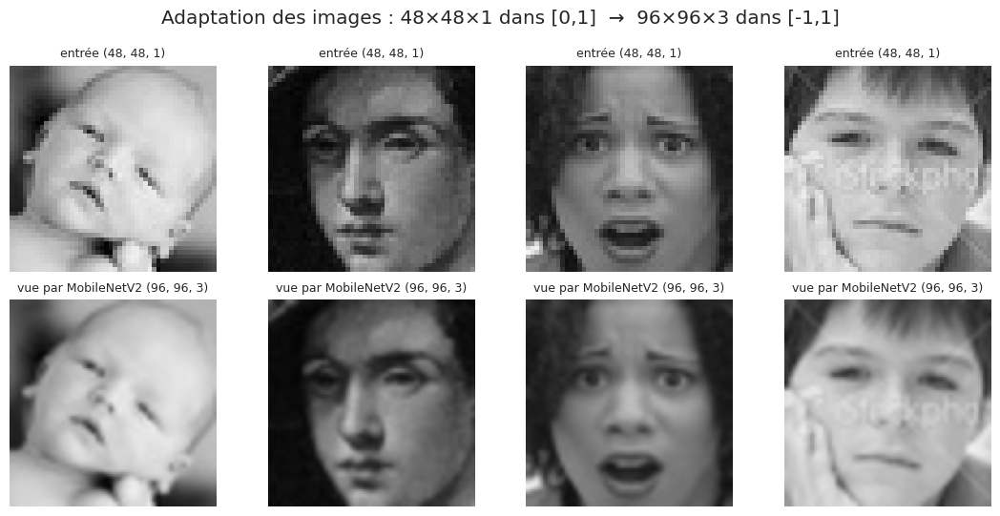

Valeurs après adaptation : min = -0.96, max = 0.88


In [5]:
adapter = keras.Model(tl_model.input, tl_model.get_layer("echelle_moins1_1").output)
sample = X_val[:4]
adapted = adapter.predict(sample, verbose=0)
fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
for i in range(4):
    axes[0, i].imshow(sample[i, :, :, 0], cmap="gray", vmin=0, vmax=1); axes[0, i].set_title(f"entrée {sample.shape[1:]}", fontsize=9)
    axes[1, i].imshow((adapted[i] + 1) / 2); axes[1, i].set_title(f"vue par MobileNetV2 {adapted.shape[1:]}", fontsize=9)
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Adaptation des images : 48×48×1 dans [0,1]  →  96×96×3 dans [-1,1]")
plt.tight_layout(); plt.show()
print(f"Valeurs après adaptation : min = {adapted.min():.2f}, max = {adapted.max():.2f}")

### 7.4 Phase 1 — Extraction de caractéristiques (réseau gelé)

On entraîne uniquement la tête. Learning rate classique (1e-3), car seuls les poids neufs de la tête bougent.

In [6]:
def callbacks_for(path, patience):
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1),
            keras.callbacks.ModelCheckpoint(path, monitor="val_loss", save_best_only=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)]

EPOCHS_P1 = 20
tl_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
hist_p1 = tl_model.fit(X_train, y_train_oh, validation_data=(X_val, y_val_oh), epochs=EPOCHS_P1,
                       batch_size=BATCH_SIZE, callbacks=callbacks_for(os.path.join(TL_DIR, "tl_phase1.keras"), 5),
                       verbose=2).history
time_p1 = (time.time() - t0) / 60
y_pred_p1 = tl_model.predict(X_val, batch_size=256, verbose=0).argmax(axis=1)
f1_p1 = f1_score(y_val, y_pred_p1, average="macro", zero_division=0)
print(f"\nPhase 1 : {len(hist_p1['loss'])} époques en {time_p1:.1f} min | "
      f"meilleure acc val = {max(hist_p1['val_accuracy']):.3f} | F1 macro val = {f1_p1:.3f}")

Epoch 1/20
382/382 - 23s - 62ms/step - accuracy: 0.3192 - loss: 1.8335 - val_accuracy: 0.3613 - val_loss: 1.6371 - learning_rate: 0.0010
Epoch 2/20
382/382 - 12s - 30ms/step - accuracy: 0.3801 - loss: 1.6189 - val_accuracy: 0.3803 - val_loss: 1.6234 - learning_rate: 0.0010
Epoch 3/20
382/382 - 12s - 30ms/step - accuracy: 0.3941 - loss: 1.5707 - val_accuracy: 0.3919 - val_loss: 1.5939 - learning_rate: 0.0010
Epoch 4/20
382/382 - 12s - 31ms/step - accuracy: 0.3951 - loss: 1.5607 - val_accuracy: 0.3912 - val_loss: 1.5892 - learning_rate: 0.0010
Epoch 5/20
382/382 - 11s - 30ms/step - accuracy: 0.4020 - loss: 1.5557 - val_accuracy: 0.3896 - val_loss: 1.5939 - learning_rate: 0.0010
Epoch 6/20
382/382 - 12s - 32ms/step - accuracy: 0.4024 - loss: 1.5500 - val_accuracy: 0.3877 - val_loss: 1.5972 - learning_rate: 0.0010
Epoch 7/20
382/382 - 13s - 34ms/step - accuracy: 0.3997 - loss: 1.5540 - val_accuracy: 0.3935 - val_loss: 1.5846 - learning_rate: 0.0010
Epoch 8/20
382/382 - 11s - 28ms/step - ac

### 7.5 Phase 2 — Fine-tuning

On **dégèle les dernières couches** de MobileNetV2 (à partir de la couche 100 sur 154, soit les derniers blocs,
ceux qui codent les motifs de haut niveau) et on ré-entraîne avec un learning rate **100 fois plus faible**.

Trois précautions :
- les **premières couches restent gelées** : leurs détecteurs de bords et de textures sont génériques, et les
  ré-entraîner sur 24 000 petites images risquerait de les abîmer (surapprentissage) ;
- **learning rate très faible** (1e-5) : on ajuste les poids pré-entraînés, on ne les réécrit pas ;
- les couches **BatchNormalization restent en mode inférence** (`base(x, training=False)` en 7.3) : sinon leurs
  statistiques, calculées sur ImageNet, seraient recalculées sur de petits lots de visages et le modèle
  perdrait brutalement ce qu'il a appris ;
- il faut **recompiler** le modèle après avoir changé `trainable`, sinon le changement n'est pas pris en compte.

In [7]:
FINE_TUNE_AT = 100
EPOCHS_P2 = 30

base.trainable = True
for layer in base.layers[:FINE_TUNE_AT]:
    layer.trainable = False
print(f"Couches de MobileNetV2 entraînables : {sum(l.trainable for l in base.layers)} / {len(base.layers)}")
print(f"Paramètres entraînables (phase 2) : {sum(int(np.prod(w.shape)) for w in tl_model.trainable_weights):,}".replace(",", " "))

tl_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
hist_p2 = tl_model.fit(X_train, y_train_oh, validation_data=(X_val, y_val_oh), epochs=EPOCHS_P2,
                       batch_size=BATCH_SIZE, callbacks=callbacks_for(os.path.join(TL_DIR, "tl_finetune.keras"), 8),
                       verbose=2).history
time_p2 = (time.time() - t0) / 60
y_pred_p2 = tl_model.predict(X_val, batch_size=256, verbose=0).argmax(axis=1)
f1_p2 = f1_score(y_val, y_pred_p2, average="macro", zero_division=0)
print(f"\nPhase 2 : {len(hist_p2['loss'])} époques en {time_p2:.1f} min | "
      f"meilleure acc val = {max(hist_p2['val_accuracy']):.3f} | F1 macro val = {f1_p2:.3f}")
tl_model.save(os.path.join(TL_DIR, "modele_transfer.keras"))

Couches de MobileNetV2 entraînables : 54 / 154
Paramètres entraînables (phase 2) : 1 870 407
Epoch 1/30
382/382 - 45s - 118ms/step - accuracy: 0.2719 - loss: 2.5648 - val_accuracy: 0.3912 - val_loss: 1.7678 - learning_rate: 1.0000e-05
Epoch 2/30
382/382 - 29s - 75ms/step - accuracy: 0.3280 - loss: 2.1311 - val_accuracy: 0.4056 - val_loss: 1.7932 - learning_rate: 1.0000e-05
Epoch 3/30
382/382 - 34s - 89ms/step - accuracy: 0.3512 - loss: 1.8977 - val_accuracy: 0.4093 - val_loss: 1.7853 - learning_rate: 1.0000e-05
Epoch 4/30
382/382 - 42s - 109ms/step - accuracy: 0.3677 - loss: 1.7382 - val_accuracy: 0.4163 - val_loss: 1.7236 - learning_rate: 1.0000e-05
Epoch 5/30
382/382 - 24s - 63ms/step - accuracy: 0.3907 - loss: 1.6323 - val_accuracy: 0.4193 - val_loss: 1.6478 - learning_rate: 1.0000e-05
Epoch 6/30
382/382 - 22s - 57ms/step - accuracy: 0.4053 - loss: 1.5498 - val_accuracy: 0.4214 - val_loss: 1.5910 - learning_rate: 1.0000e-05
Epoch 7/30
382/382 - 22s - 58ms/step - accuracy: 0.4233 - l

### 7.6 Courbes d'apprentissage des deux phases

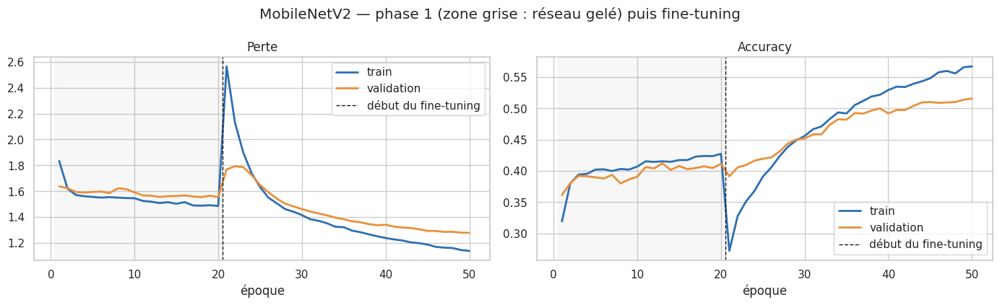

In [8]:
loss = hist_p1["loss"] + hist_p2["loss"]; val_loss = hist_p1["val_loss"] + hist_p2["val_loss"]
acc = hist_p1["accuracy"] + hist_p2["accuracy"]; val_acc = hist_p1["val_accuracy"] + hist_p2["val_accuracy"]
ep = np.arange(1, len(loss) + 1); start_ft = len(hist_p1["loss"]) + 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for ax, tr, va, title in [(axes[0], loss, val_loss, "Perte"), (axes[1], acc, val_acc, "Accuracy")]:
    ax.plot(ep, tr, color="#2f6fb0", lw=2, label="train"); ax.plot(ep, va, color="#e8913c", lw=2, label="validation")
    ax.axvline(start_ft, color="k", ls="--", lw=1, label="début du fine-tuning")
    ax.axvspan(0.5, start_ft, color="#999", alpha=0.08)
    ax.set_title(title); ax.set_xlabel("époque"); ax.legend()
plt.suptitle("MobileNetV2 — phase 1 (zone grise : réseau gelé) puis fine-tuning")
plt.tight_layout(); plt.show()

### 7.7 Lecture des résultats du Transfer Learning

**Résultats obtenus**
- **Phase 1 (réseau gelé, 8 967 paramètres entraînés)** : 20 époques en 4,2 min ; accuracy de validation au mieux
  **41,2 %**, F1 macro **0,326**. À peine mieux que le réseau dense (38,1 %) : les caractéristiques d'ImageNet,
  apprises sur des photos couleur d'objets, ne sont pas directement adaptées à de petits visages gris où
  l'information est dans des détails fins (coins de la bouche, sourcils).
- **Phase 2 (fine-tuning des 54 dernières couches, 1 870 407 paramètres entraînables)** : 30 époques en 13,1 min ;
  accuracy de validation **51,6 %**, F1 macro **0,440** (+11,4 points de F1 par rapport à la phase 1). Dès que les
  derniers blocs s'adaptent aux visages, la validation progresse fortement : le fine-tuning est **indispensable**
  quand le domaine (visages gris 48 × 48) est éloigné du domaine d'origine (ImageNet).

**Lecture des courbes (7.6)**
- À la première époque de fine-tuning, la perte d'entraînement **remonte brusquement** (≈ 1,5 → 2,6) et l'accuracy
  chute à ≈ 27 % : dégeler 1,9 million de poids perturbe d'abord le réseau. Il récupère en 4 à 5 époques, puis
  progresse régulièrement.
- Train et validation restent proches (≈ 57 % contre 52 % à la fin) : **pas de surapprentissage marqué**.
- La meilleure époque est la **dernière (30)** et la validation montait encore : un fine-tuning plus long
  améliorerait probablement le résultat.

**Test (7.10)** : accuracy **52,4 %**, F1 macro **0,446**, soit le niveau du CNN de base (53,0 % ; 0,447). Mêmes
points forts et faibles que le CNN : Joie (F1 0,756) et Surprise (0,626) bien reconnues, Peur (0,339) et surtout
Dégoût (0,084, rappel 4,5 %) difficiles.

> ⚠️ **Lecture du tableau 7.10** : la ligne « Modèle final CNN (Partie 6) » (52,4 % ; F1 0,444) ne correspond **pas**
> au CNN de la Partie 6. Lors d'une exécution précédente, la cellule 7.11 avait déjà remplacé `modele_final.keras`
> par un premier MobileNetV2 : cette ligne évalue donc ce premier MobileNetV2. Le vrai résultat de test du modèle
> FINAL de la Partie 6 est celui de la section 6.8 : **48,6 %**, F1 macro **0,420**.

**Coût** : 2,27 millions de paramètres (3,3 fois notre CNN) et 17,3 min d'entraînement au total, contre 2,2 min
pour E1.

### 7.8 Régularisation L2

La **régularisation L2** (*weight decay*) ajoute à la perte une pénalité proportionnelle à la somme des carrés des poids :

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{entropie croisée}} + \lambda \sum_i w_i^2$$

- le réseau est poussé à garder des **poids petits** : il ne peut plus s'appuyer fortement sur quelques pixels
  ou détails très spécifiques des images d'entraînement → fonction plus « lisse », moins de surapprentissage ;
- dans la mise à jour de gradient, chaque poids est en plus rapproché de 0 d'une petite fraction à chaque pas
  (d'où le nom *weight decay*) ;
- $\lambda$ règle la force : trop grand, le réseau ne peut plus rien apprendre (sous-apprentissage) ; on prend
  $\lambda = 10^{-4}$, valeur courante.

**Expérience :** CNN de base de la Partie 3 **+ L2 sur toutes les convolutions et la couche Dense**, protocole
identique à la Partie 6 (même graine, 60 époques max, Early Stopping patience 10), et comparaison avec E0.

Epoch 1/60
382/382 - 18s - 48ms/step - accuracy: 0.3385 - loss: 1.6877 - val_accuracy: 0.4098 - val_loss: 1.5389
Epoch 2/60
382/382 - 4s - 10ms/step - accuracy: 0.4523 - loss: 1.4522 - val_accuracy: 0.4720 - val_loss: 1.3906
Epoch 3/60
382/382 - 3s - 8ms/step - accuracy: 0.5057 - loss: 1.3272 - val_accuracy: 0.5010 - val_loss: 1.3363
Epoch 4/60
382/382 - 3s - 8ms/step - accuracy: 0.5476 - loss: 1.2453 - val_accuracy: 0.5238 - val_loss: 1.3106
Epoch 5/60
382/382 - 3s - 8ms/step - accuracy: 0.5786 - loss: 1.1720 - val_accuracy: 0.5333 - val_loss: 1.3073
Epoch 6/60
382/382 - 3s - 8ms/step - accuracy: 0.6092 - loss: 1.1108 - val_accuracy: 0.5347 - val_loss: 1.3233
Epoch 7/60
382/382 - 5s - 13ms/step - accuracy: 0.6347 - loss: 1.0504 - val_accuracy: 0.5396 - val_loss: 1.3489
Epoch 8/60
382/382 - 3s - 8ms/step - accuracy: 0.6611 - loss: 0.9941 - val_accuracy: 0.5259 - val_loss: 1.4057
Epoch 9/60
382/382 - 3s - 8ms/step - accuracy: 0.6871 - loss: 0.9378 - val_accuracy: 0.5298 - val_loss: 1.48

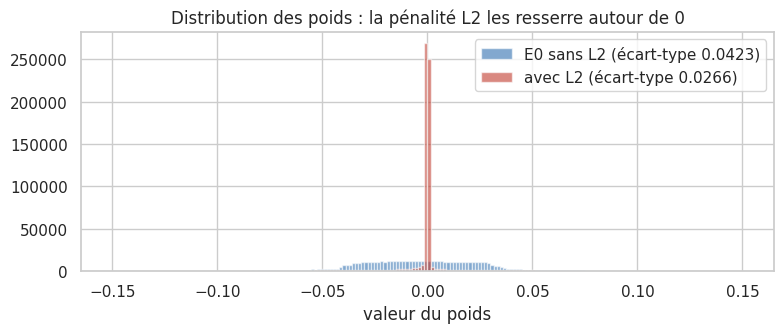

In [9]:
def build_cnn_l2(l2=1e-4, filters=(32, 64, 128), dense_units=128, input_shape=(48, 48, 1)):
    reg = regularizers.l2(l2)
    model = keras.Sequential(name="cnn_l2")
    model.add(keras.Input(shape=input_shape))
    for i, f in enumerate(filters, start=1):
        model.add(layers.Conv2D(f, 3, padding="same", kernel_regularizer=reg, name=f"conv{i}"))
        model.add(layers.ReLU(name=f"relu{i}"))
        model.add(layers.MaxPooling2D(2, name=f"pool{i}"))
    model.add(layers.Flatten(name="flatten"))
    model.add(layers.Dense(dense_units, activation="relu", kernel_regularizer=reg, name="dense"))
    model.add(layers.Dense(NUM_CLASSES, name="logits"))
    model.add(layers.Softmax(name="softmax"))
    return model

set_seed()
cnn_l2 = build_cnn_l2()
cnn_l2.compile(optimizer=keras.optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
hist_l2 = cnn_l2.fit(X_train, y_train_oh, validation_data=(X_val, y_val_oh), epochs=60, batch_size=BATCH_SIZE,
                     callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
                     verbose=2).history
time_l2 = (time.time() - t0) / 60
y_pred_l2 = cnn_l2.predict(X_val, batch_size=256, verbose=0).argmax(axis=1)
cnn_l2.save(os.path.join(TL_DIR, "cnn_l2.keras"))

# La perte affichée par Keras inclut la pénalité L2 : on mesure aussi la seule entropie croisée, pour comparer à E0
ce_val = float(keras.losses.CategoricalCrossentropy()(y_val_oh, cnn_l2.predict(X_val, batch_size=256, verbose=0)).numpy())
print(f"\nL2 : acc val = {accuracy_score(y_val, y_pred_l2):.3f} | F1 macro val = {f1_score(y_val, y_pred_l2, average='macro', zero_division=0):.3f} "
      f"| entropie croisée val = {ce_val:.3f} | {time_l2:.1f} min")

w_l2 = np.concatenate([cnn_l2.get_layer(n).get_weights()[0].ravel() for n in ["conv1", "conv2", "conv3", "dense"]])
e0_path = os.path.join(SAVE_DIR, "experiences", "E0.keras")
if os.path.exists(e0_path):
    e0 = keras.models.load_model(e0_path)
    w_e0 = np.concatenate([e0.get_layer(n).get_weights()[0].ravel() for n in ["conv1", "conv2", "conv3", "dense"]])
    plt.figure(figsize=(8, 3.5))
    plt.hist(w_e0, bins=200, range=(-0.15, 0.15), alpha=0.6, color="#2f6fb0", label=f"E0 sans L2 (écart-type {w_e0.std():.4f})")
    plt.hist(w_l2, bins=200, range=(-0.15, 0.15), alpha=0.6, color="#c0392b", label=f"avec L2 (écart-type {w_l2.std():.4f})")
    plt.title("Distribution des poids : la pénalité L2 les resserre autour de 0"); plt.xlabel("valeur du poids"); plt.legend()
    plt.tight_layout(); plt.show()

### 7.9 Comparaison sur la validation

On réunit tous les modèles évalués sur la **même validation** : ceux de la Partie 6 (relus dans le Drive) et ceux
de ce notebook. Critère principal : **F1 macro**, comme en Partie 6.

In [10]:
rows = []
res6_path = os.path.join(SAVE_DIR, "experiences", "resultats_experiences.json")
if os.path.exists(res6_path):
    res6 = json.load(open(res6_path))
    for n in ["E0", "FINAL"]:
        if n in res6:
            rows.append({"modèle": f"{n} — {res6[n]['modification'][:45]} (Partie 6)", "paramètres": res6[n]["paramètres"],
                         "acc val": res6[n]["acc val"], "F1 macro val": res6[n]["F1 macro val"],
                         "rappel Dégoût val": res6[n]["rappel Dégoût val"], "durée (min)": res6[n]["durée (min)"]})

def row(name, model, y_pred, minutes):
    return {"modèle": name, "paramètres": int(model.count_params()), "acc val": accuracy_score(y_val, y_pred),
            "F1 macro val": f1_score(y_val, y_pred, average="macro", zero_division=0),
            "rappel Dégoût val": recall_score(y_val, y_pred, labels=[K_DISGUST], average="macro", zero_division=0),
            "durée (min)": minutes}

rows.append(row("CNN + L2 (Partie 7)", cnn_l2, y_pred_l2, time_l2))
rows.append(row("MobileNetV2 — phase 1, réseau gelé (Partie 7)", tl_model, y_pred_p1, time_p1))
rows.append(row("MobileNetV2 — après fine-tuning (Partie 7)", tl_model, y_pred_p2, time_p1 + time_p2))
comparison = pd.DataFrame(rows).set_index("modèle").round(3)
comparison.to_csv(os.path.join(TL_DIR, "comparaison_validation.csv"))
comparison

,paramètres,acc val,F1 macro val,rappel Dégoût val,durée (min)
modèle,,,,,
E0 — Aucune (CNN de base) (Partie 6),683527,0.532,0.454,0.015,0.875
"FINAL — Combinaison : Dropout (0,25 / 0,5), Data Augm (Partie 6)",683527,0.495,0.426,0.615,7.105
CNN + L2 (Partie 7),683527,0.533,0.451,0.015,1.066
"MobileNetV2 — phase 1, réseau gelé (Partie 7)",2266951,0.407,0.326,0.015,4.208
MobileNetV2 — après fine-tuning (Partie 7),2266951,0.516,0.440,0.062,17.346


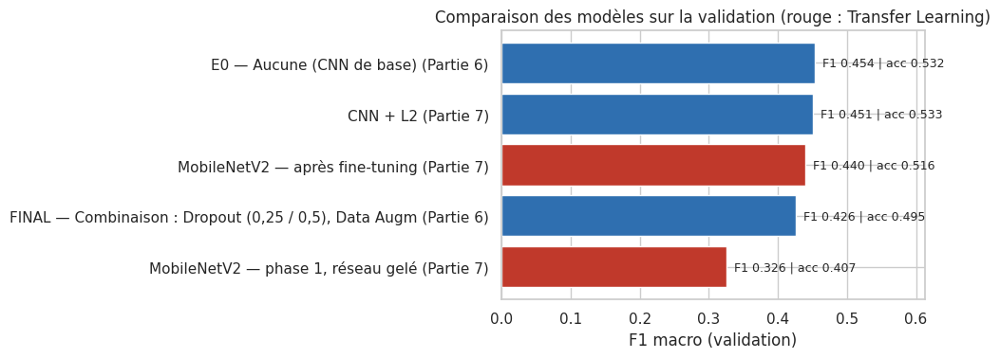

In [11]:
c = comparison.sort_values("F1 macro val")
fig, ax = plt.subplots(figsize=(10, 0.55 * len(c) + 1.2))
ax.barh(c.index, c["F1 macro val"], color=["#c0392b" if "MobileNet" in i else "#2f6fb0" for i in c.index])
for i, (v, a) in enumerate(zip(c["F1 macro val"], c["acc val"])):
    ax.text(v, i, f"  F1 {v:.3f} | acc {a:.3f}", va="center", fontsize=9)
ax.set_xlabel("F1 macro (validation)"); ax.set_xlim(0, max(1e-3, c["F1 macro val"].max()) * 1.35)
ax.set_title("Comparaison des modèles sur la validation (rouge : Transfer Learning)")
plt.tight_layout(); plt.show()

### 7.10 Évaluation du modèle pré-entraîné sur le test (une seule fois)

Le modèle MobileNetV2 fine-tuné est figé ; on l'évalue sur le test et on le compare au modèle final de la
Partie 6 (déjà évalué sur ces mêmes images).

                                  accuracy test  F1 macro test  \
MobileNetV2 fine-tuné (Partie 7)          0.524          0.446   
Modèle final CNN (Partie 6)               0.524          0.444   

                                  rappel Dégoût test  
MobileNetV2 fine-tuné (Partie 7)               0.045  
Modèle final CNN (Partie 6)                    0.036  
              precision    recall  f1-score   support

      Colère      0.356     0.553     0.433       958
      Dégoût      0.625     0.045     0.084       111
        Peur      0.377     0.308     0.339      1024
        Joie      0.740     0.772     0.756      1774
      Neutre      0.465     0.529     0.495      1233
   Tristesse      0.442     0.351     0.392      1247
    Surprise      0.747     0.539     0.626       831

    accuracy                          0.524      7178
   macro avg      0.536     0.442     0.446      7178
weighted avg      0.537     0.524     0.520      7178



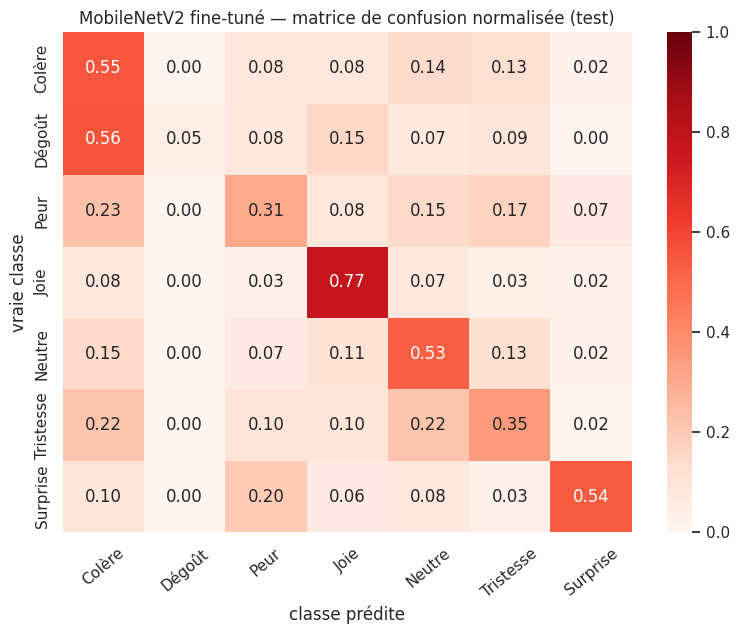

In [12]:
proba_tl = tl_model.predict(X_test, batch_size=256, verbose=0)
y_pred_tl = proba_tl.argmax(axis=1)
test_rows = {"MobileNetV2 fine-tuné (Partie 7)": y_pred_tl}
final_path = os.path.join(SAVE_DIR, "modele_final.keras")
if os.path.exists(final_path):
    test_rows["Modèle final CNN (Partie 6)"] = keras.models.load_model(final_path).predict(X_test, batch_size=256, verbose=0).argmax(axis=1)
test_table = pd.DataFrame({
    "accuracy test": [accuracy_score(y_test, p) for p in test_rows.values()],
    "F1 macro test": [f1_score(y_test, p, average="macro", zero_division=0) for p in test_rows.values()],
    "rappel Dégoût test": [recall_score(y_test, p, labels=[K_DISGUST], average="macro", zero_division=0) for p in test_rows.values()],
}, index=list(test_rows.keys())).round(3)
display(test_table) if "display" in globals() else print(test_table)

print(classification_report(y_test, y_pred_tl, target_names=CLASSES_FR, digits=3, zero_division=0))
cm = confusion_matrix(y_test, y_pred_tl, labels=range(NUM_CLASSES))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, xticklabels=CLASSES_FR, yticklabels=CLASSES_FR)
plt.title("MobileNetV2 fine-tuné — matrice de confusion normalisée (test)")
plt.xlabel("classe prédite"); plt.ylabel("vraie classe"); plt.xticks(rotation=40)
plt.tight_layout(); plt.show()

### 7.11 Quel classifieur pour les Parties 8 et 9 ?

Le choix se fait sur la **validation** (F1 macro), jamais sur le test. Si le modèle pré-entraîné est meilleur,
il remplace `modele_final.keras` (l'ancien CNN est conservé sous `modele_final_cnn.keras`). Comme son entrée
est `(48, 48, 1)`, les Parties 8 et 9 l'utilisent sans aucune modification de code.

Compromis à garder en tête : MobileNetV2 est plus lent par visage que notre petit CNN, ce qui compte en vidéo
(Partie 9 affiche le temps par image).

In [13]:
f1_tl = f1_score(y_val, y_pred_p2, average="macro", zero_division=0)
f1_cnn = res6["FINAL"]["F1 macro val"] if os.path.exists(res6_path) and "FINAL" in res6 else None
print(f"F1 macro validation — MobileNetV2 : {f1_tl:.3f} | CNN final : {f1_cnn if f1_cnn is None else round(f1_cnn, 3)}")

if f1_cnn is None or f1_tl > f1_cnn:
    if os.path.exists(final_path) and not os.path.exists(os.path.join(SAVE_DIR, "modele_final_cnn.keras")):
        shutil.copy(final_path, os.path.join(SAVE_DIR, "modele_final_cnn.keras"))
    tl_model.save(final_path)
    print("=> MobileNetV2 devient le classifieur des Parties 8 et 9 (modele_final.keras).")
else:
    print("=> Le CNN de la Partie 6 reste le classifieur des Parties 8 et 9.")

F1 macro validation — MobileNetV2 : 0.440 | CNN final : 0.426
=> MobileNetV2 devient le classifieur des Parties 8 et 9 (modele_final.keras).


### 7.12 Bilan de l'enrichissement

- **Transfer Learning** : MobileNetV2 fine-tuné atteint un F1 macro de 0,440 en validation et 52,4 % d'accuracy au
  test. Il fait mieux que le modèle FINAL de la Partie 6 (0,426), mais **ne dépasse pas** notre meilleur CNN
  entraîné depuis zéro, E1 (F1 0,509, accuracy de validation 57,1 %). Raisons probables : domaine très différent
  d'ImageNet, images de 48 × 48 agrandies à 96 × 96 (aucune information ajoutée), fine-tuning encore en progression
  après 30 époques. Le fine-tuning reste l'étape décisive : +11,4 points de F1 par rapport au réseau gelé.
- **Régularisation L2** : accuracy de validation 53,3 % et F1 macro 0,451, contre 53,2 % et 0,454 pour E0 :
  **aucun effet mesurable** sur la performance (entropie croisée de validation 1,259 contre 1,279). L'effet sur
  les poids est pourtant très net : leur écart-type passe de **0,0423 à 0,0266** (histogramme 7.8). Sur ce
  problème, le Dropout (+5,5 pts) et la Data Augmentation (+4,9 pts) sont des régularisations bien plus efficaces.
- **Data Augmentation** : utilisée en Partie 6 (E3, +4,9 pts) et dans le modèle pré-entraîné.
- **Détection / YOLO** : Parties 8 et 9.
- **Classifieur des Parties 8 et 9** : la règle 7.11 compare MobileNetV2 au modèle FINAL de la Partie 6 ;
  MobileNetV2 l'emporte (0,440 contre 0,426) et devient `modele_final.keras`. Le CNN E1 (0,509), qui ne faisait
  pas partie de cette comparaison, aurait été un meilleur choix, et 4 fois plus léger pour la vidéo.

---
## ⚠️ Redémarrage obligatoire avant la Partie 8

Les Parties 8 et 9 utilisent YOLO, qui repose sur **PyTorch**. Or PyTorch et **TensorFlow** (utilisé dans les
Parties 1 à 7) font planter Python s'ils tournent dans la même session. Le notebook s'arrête donc volontairement ici.

**À faire :**
1. `Exécution > Redémarrer la session` ;
2. cliquer sur la première cellule de code de la **Partie 8** (celle qui commence par `!pip install`) ;
3. `Exécution > Exécuter après`.

Rien n'est perdu : tous les résultats des Parties 1 à 7 sont dans le Drive. Dans les Parties 8 et 9, notre modèle
est chargé avec PyTorch comme moteur de calcul (Keras sait utiliser les deux), sans TensorFlow.

In [14]:
raise SystemExit("Parties 1 à 7 terminées. Redémarrez la session, puis exécutez à partir de la Partie 8 "
                 "(voir les instructions ci-dessus).")

SystemExit: Parties 1 à 7 terminées. Redémarrez la session, puis exécutez à partir de la Partie 8 (voir les instructions ci-dessus).

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


---
## Partie 8 — Extension : détection et analyse de plusieurs visages (YOLO)

Jusqu'ici, le système travaille sur un **visage déjà extrait** :

$$\text{Visage déjà extrait} \rightarrow \text{CNN} \rightarrow \text{expression prédite}$$

On construit maintenant un système capable de traiter **une image quelconque contenant une ou plusieurs personnes** :

$$\text{Image} \rightarrow \text{Détection des visages (YOLO)} \rightarrow \text{Bounding boxes} \rightarrow
\text{Extraction des visages} \rightarrow \text{CNN} \rightarrow \text{Expressions prédites}$$

Le résultat affiche, pour chaque visage : sa **bounding box**, l'**expression prédite** et le **score** associé.

**Plan :**
- 8.1 – 8.6 : notions de détection et de YOLO (avec démonstrations) ;
- 8.7 – 8.10 : pipeline complet et résultats ;
- 8.11 : limites.

> ⚙️ Colab avec GPU. Prérequis : `modele_final.keras` (Partie 6) dans le Drive — à défaut, `cnn_base.keras` (Partie 4).
> Pour tester vos propres photos : déposez-les dans le dossier `projet_dl/images_test/` de votre Drive.

### 8.0 Installation et chargement

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 4.2 MB/s eta 0:00:00


In [2]:
import os, sys
# TensorFlow et YOLO (PyTorch) font planter Python s'ils tournent dans la même session.
# On charge donc notre modèle Keras avec PyTorch comme moteur de calcul, sans TensorFlow.
if "tensorflow" in sys.modules:
    raise SystemExit("TensorFlow est déjà chargé dans cette session : faites « Exécution > Redémarrer la session », "
                     "puis relancez à partir de cette partie.")
os.environ["KERAS_BACKEND"] = "torch"
import keras
import json, time, glob, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from ultralytics import YOLO

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass
SAVE_DIR = "/content/drive/MyDrive/projet_dl" if os.path.isdir("/content/drive/MyDrive") else "."
WORK_DIR = os.path.join(SAVE_DIR, "partie8"); os.makedirs(WORK_DIR, exist_ok=True)

# --- Classifieur d'expressions (notre CNN) ---
model_path = os.path.join(SAVE_DIR, "modele_final.keras")
if not os.path.exists(model_path):
    model_path = os.path.join(SAVE_DIR, "cnn_base.keras")
emotion_model = keras.models.load_model(model_path)

data = np.load(os.path.join(SAVE_DIR, "fer2013_prepared.npz"))
CLASSES = list(data["classes"])
FR = {"angry": "Colère", "disgust": "Dégoût", "fear": "Peur", "happy": "Joie",
      "neutral": "Neutre", "sad": "Tristesse", "surprise": "Surprise"}
CLASSES_FR = [FR.get(c, c) for c in CLASSES]
IMG_SIZE = emotion_model.input_shape[1]
print("Classifieur :", os.path.basename(model_path), "| entrée :", emotion_model.input_shape)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classifieur : modele_final.keras | entrée : (None, 48, 48, 1)


### 8.1 Choix du détecteur de visages

**Point d'attention de l'énoncé :** un YOLO pré-entraîné standard (dataset **COCO**, 80 classes) détecte des
**personnes**, pas des visages. Nous utilisons donc **YOLOv8n-face** : un YOLOv8 *nano* (≈ 3 millions de
paramètres) **ré-entraîné spécifiquement pour détecter des visages** sur le dataset **WIDER FACE**
(≈ 32 000 images, ≈ 390 000 visages annotés, avec de fortes variations d'échelle, de pose et d'occlusion).

- Source : dépôt open source `akanametov/yolo-face` (https://github.com/akanametov/yolo-face), basé sur
  Ultralytics YOLOv8 (licence AGPL-3.0) ;
- c'est un exemple de **Transfer Learning / fine-tuning** : on part d'un YOLOv8 pré-entraîné sur COCO, et on
  ré-entraîne sa tête de détection pour une seule classe, `face` ;
- version *nano* : rapide (temps réel sur GPU), adaptée à la vidéo de la Partie 9.

Alternatives possibles (non retenues) : le détecteur Haar-cascade d'OpenCV (ancien, beaucoup d'erreurs sur
les visages de profil), MediaPipe ou RetinaFace (efficaces, mais ne sont pas des modèles YOLO).

In [3]:
def download(url, dest):
    if not os.path.exists(dest):
        urllib.request.urlretrieve(url, dest)
    return dest

FACE_WEIGHTS = os.path.join(WORK_DIR, "yolov8n-face.pt")
try:
    download("https://github.com/akanametov/yolo-face/releases/download/1.0.0/yolov8n-face.pt", FACE_WEIGHTS)
except Exception as e:   # miroir de secours (autre modèle YOLOv8n entraîné sur WIDER FACE)
    print("Téléchargement principal impossible :", e)
    download("https://github.com/lindevs/yolov8-face/releases/latest/download/yolov8n-face-lindevs.pt", FACE_WEIGHTS)

face_detector = YOLO(FACE_WEIGHTS)
print("Classes du détecteur :", face_detector.names)

# Images de démonstration (fournies par Ultralytics) + vos images éventuelles
DEMO = {"zidane.jpg": "https://github.com/ultralytics/assets/releases/download/v0.0.0/zidane.jpg",
        "bus.jpg": "https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg"}
demo_paths = [download(u, os.path.join(WORK_DIR, n)) for n, u in DEMO.items()]
user_dir = os.path.join(SAVE_DIR, "images_test"); os.makedirs(user_dir, exist_ok=True)
user_paths = sorted(p for ext in ("*.jpg", "*.jpeg", "*.png") for p in glob.glob(os.path.join(user_dir, ext)))
print("Images de démo :", [os.path.basename(p) for p in demo_paths])
print("Vos images (Drive/projet_dl/images_test) :", [os.path.basename(p) for p in user_paths] or "aucune")

Classes du détecteur : {0: 'face'}
Images de démo : ['zidane.jpg', 'bus.jpg']
Vos images (Drive/projet_dl/images_test) : ['1000_F_170776141_DWQjn2F5zyWSUUH7tUBYELLycMJyXbxa.jpg', '1000_F_227186172_fOaKomf8W42z99hWaVChlSBFEPMV1f2W.jpg', '1000_F_528502590_oNvZhUN1foUJfZDEItFzpuJfbvyF6wxj.jpg', '20e37fcf904547fba37a67b74f6852e9.jpg', '360_F_748342866_3BG5on4wl1zGJpVnMCDdnJ6c7oMQn2JJ.jpg', '81519841-a-group-of-angry-people.jpg', 'ae75626b4e2f5079d6c092707fe0b197.jpg', 'depositphotos_147907163-stock-photo-sad-man-among-group-of.jpg', 'depositphotos_65154851-stock-photo-group-of-people-crying.jpg', 'diverse-group-gathered-stockcake.jpg', 'diverse-group-of-men-standing-together-multicultural-male-beauty-diversity-concept-ai-generative-photo.jpeg', 'diverse-group-profile-stockcake.jpg', 'gettyimages-2186945612-612x612.jpg', 'image16.png', 'ish.jpg', 'istockphoto-1136348481-612x612.jpg', 'istockphoto-1344873525-612x612.jpg', 'istockphoto-1452240827-612x612.jpg', 'istockphoto-157480265-612x612.j

### 8.2 Classification vs détection

| | Classification (Parties 1–6) | Détection (Partie 8) |
|---|---|---|
| Question | **Quoi ?** | **Où ?** et **quoi ?** |
| Entrée | une image = un visage déjà extrait | une image avec 0, 1 ou plusieurs objets |
| Sortie | une classe + une probabilité pour toute l'image | pour **chaque** objet : une bounding box + une classe + un score de confiance |
| Nombre de sorties | fixe (7 probabilités) | variable (autant que d'objets détectés) |

On le voit en comparant un YOLO **COCO** standard et le YOLO **visages** sur la même image :

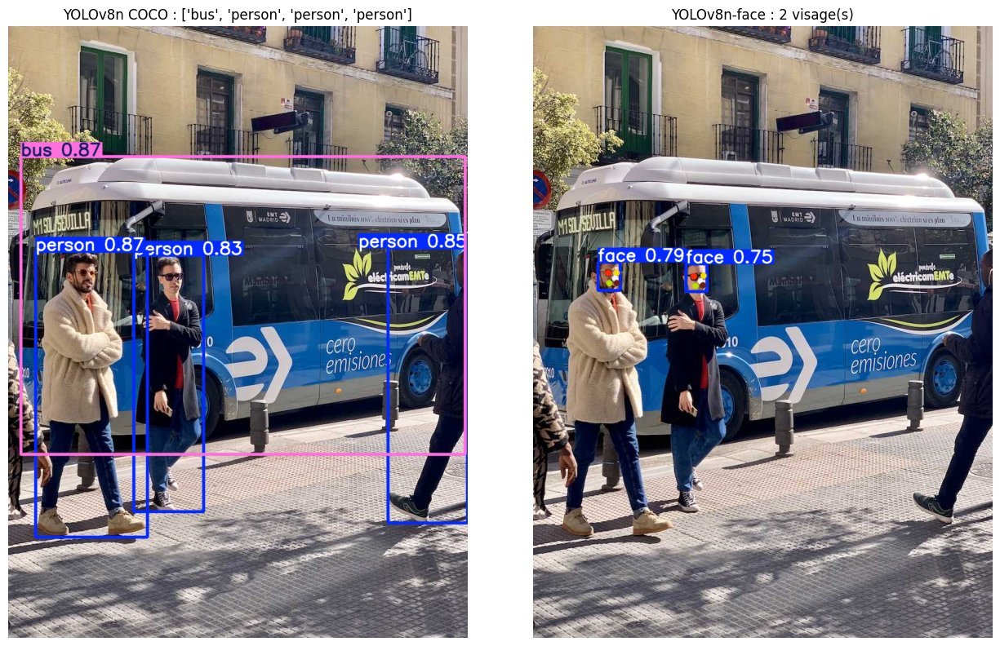

In [4]:
def show_bgr(img, title="", ax=None, size=(10, 6)):
    if ax is None:
        _, ax = plt.subplots(figsize=size)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis("off")

coco_detector = YOLO("yolov8n.pt")            # YOLOv8n pré-entraîné COCO (80 classes)
img = cv2.imread(demo_paths[1])
r_coco = coco_detector.predict(img, conf=0.4, verbose=False)[0]
r_face = face_detector.predict(img, conf=0.4, verbose=False)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
show_bgr(r_coco.plot(), f"YOLOv8n COCO : {[coco_detector.names[int(c)] for c in r_coco.boxes.cls]}", axes[0])
show_bgr(r_face.plot(), f"YOLOv8n-face : {len(r_face.boxes)} visage(s)", axes[1])
plt.tight_layout(); plt.show()

Le modèle COCO encadre des **personnes entières** (et le bus) : impossible d'en tirer directement un visage au
format attendu par notre CNN. Le modèle spécialisé encadre précisément **chaque visage**.

### 8.3 Bounding box et score de confiance

- **Bounding box** : rectangle qui localise l'objet, décrit par 4 nombres. Deux conventions :
  coins $(x_1, y_1, x_2, y_2)$ ou centre + taille $(x_c, y_c, w, h)$ (format utilisé en interne par YOLO,
  souvent normalisé entre 0 et 1 par rapport à la taille de l'image).
- **Score de confiance** : probabilité estimée par le modèle qu'il y ait bien un objet de cette classe dans la
  boîte (pour YOLOv8 : la probabilité de la classe `face`). On ne garde que les boîtes au-dessus d'un **seuil**
  (ici 0,5) : seuil bas → plus de visages trouvés mais plus de fausses détections ; seuil haut → l'inverse.

In [5]:
r = face_detector.predict(cv2.imread(demo_paths[0]), conf=0.5, verbose=False)[0]
pd.DataFrame({
    "x1": r.boxes.xyxy[:, 0].cpu().numpy().round(0), "y1": r.boxes.xyxy[:, 1].cpu().numpy().round(0),
    "x2": r.boxes.xyxy[:, 2].cpu().numpy().round(0), "y2": r.boxes.xyxy[:, 3].cpu().numpy().round(0),
    "xc (normalisé)": r.boxes.xywhn[:, 0].cpu().numpy().round(3), "yc (normalisé)": r.boxes.xywhn[:, 1].cpu().numpy().round(3),
    "w (normalisé)": r.boxes.xywhn[:, 2].cpu().numpy().round(3), "h (normalisé)": r.boxes.xywhn[:, 3].cpu().numpy().round(3),
    "confiance": r.boxes.conf.cpu().numpy().round(3),
}, index=[f"visage {i + 1}" for i in range(len(r.boxes))])

,x1,y1,x2,y2,xc (normalisé),yc (normalisé),w (normalisé),h (normalisé),confiance
visage 1,913.0,93.0,1055.0,276.0,0.769,0.256,0.111,0.255,0.822
visage 2,542.0,242.0,664.0,448.0,0.471,0.479,0.095,0.286,0.771


### 8.4 Intersection over Union (IoU)

L'**IoU** mesure le recouvrement entre deux boîtes :

$$\text{IoU}(A, B) = \frac{\text{aire}(A \cap B)}{\text{aire}(A \cup B)} \in [0, 1]$$

- 1 = boîtes identiques, 0 = aucun recouvrement ;
- sert à **évaluer** une détection (elle est « correcte » si son IoU avec la vraie boîte dépasse un seuil, souvent 0,5) ;
- sert aussi dans la **NMS** (section suivante) pour savoir si deux boîtes désignent le même objet.

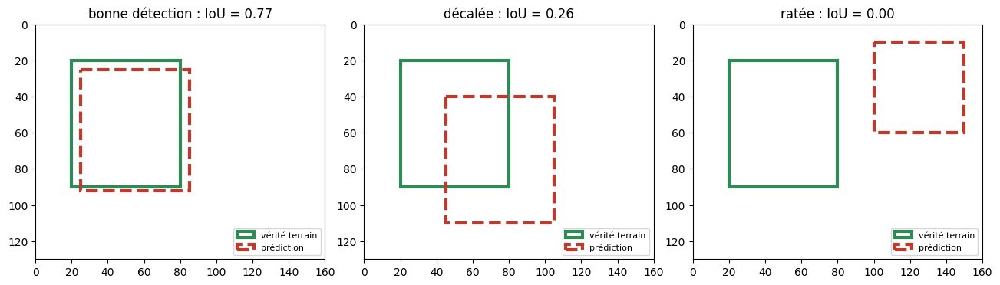

In [6]:
def iou(a, b):
    # a, b : boîtes (x1, y1, x2, y2)
    ix1, iy1, ix2, iy2 = max(a[0], b[0]), max(a[1], b[1]), min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0

truth = (20, 20, 80, 90)
cases = [("bonne détection", (25, 25, 85, 92)), ("décalée", (45, 40, 105, 110)), ("ratée", (100, 10, 150, 60))]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, pred) in zip(axes, cases):
    ax.add_patch(mpatches.Rectangle(truth[:2], truth[2] - truth[0], truth[3] - truth[1], fill=False, ec="#2e8b57", lw=3, label="vérité terrain"))
    ax.add_patch(mpatches.Rectangle(pred[:2], pred[2] - pred[0], pred[3] - pred[1], fill=False, ec="#c0392b", lw=3, ls="--", label="prédiction"))
    ax.set_xlim(0, 160); ax.set_ylim(130, 0); ax.set_aspect("equal")
    ax.set_title(f"{name} : IoU = {iou(truth, pred):.2f}"); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

### 8.5 Non-Maximum Suppression (NMS)

Un détecteur produit naturellement **plusieurs boîtes très proches pour le même visage**. La NMS ne garde
qu'une boîte par objet :
1. trier les boîtes par confiance décroissante ;
2. garder la plus confiante ;
3. supprimer toutes les boîtes restantes dont l'IoU avec elle dépasse un seuil (ex. 0,5) : ce sont des doublons ;
4. recommencer avec les boîtes restantes.

Démonstration : on demande à YOLO toutes ses boîtes **sans NMS** (seuil IoU = 1), puis on applique notre propre
NMS, et on vérifie qu'on retrouve le résultat de YOLO.

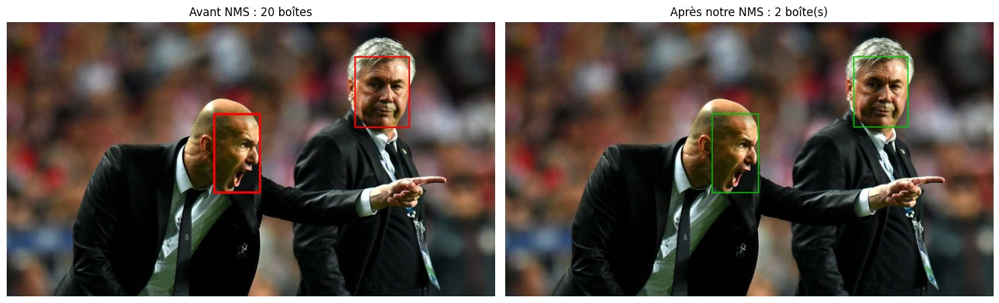

Notre NMS : 2 visage(s) | NMS de YOLO : 2 visage(s)


In [7]:
def nms(boxes, scores, iou_threshold=0.5):
    order = np.argsort(scores)[::-1]
    keep = []
    while len(order):
        best, order = order[0], order[1:]
        keep.append(best)
        order = np.array([i for i in order if iou(boxes[best], boxes[i]) < iou_threshold], dtype=int)
    return keep

img = cv2.imread(demo_paths[0])
raw = face_detector.predict(img, conf=0.25, iou=1.0, max_det=300, verbose=False)[0]          # sans NMS
boxes_raw, scores_raw = raw.boxes.xyxy.cpu().numpy(), raw.boxes.conf.cpu().numpy()
kept = nms(boxes_raw, scores_raw, 0.5)
yolo_nms = face_detector.predict(img, conf=0.25, iou=0.5, verbose=False)[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, idxs, title in [(axes[0], range(len(boxes_raw)), f"Avant NMS : {len(boxes_raw)} boîtes"),
                        (axes[1], kept, f"Après notre NMS : {len(kept)} boîte(s)")]:
    vis = img.copy()
    for i in idxs:
        x1, y1, x2, y2 = boxes_raw[i].astype(int)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255) if len(idxs) > len(kept) else (0, 200, 0), 2)
    show_bgr(vis, title, ax)
plt.tight_layout(); plt.show()
print(f"Notre NMS : {len(kept)} visage(s) | NMS de YOLO : {len(yolo_nms.boxes)} visage(s)")

### 8.6 Principe général de YOLO, modèle pré-entraîné, et métriques

**YOLO (*You Only Look Once*)** détecte tous les objets en **un seul passage** du réseau (détecteur « one-stage »),
contrairement aux détecteurs en deux étapes (R-CNN) qui proposent d'abord des régions puis les classent une à une.
C'est ce qui le rend assez rapide pour la vidéo temps réel.

Fonctionnement (YOLOv8) :
1. **Backbone** : un CNN (convolutions, comme en Partie 3) extrait des feature maps de l'image (redimensionnée en 640 × 640) ;
2. **Neck** : combine des feature maps de plusieurs résolutions → détection des grands **et** des petits visages ;
3. **Head** : l'image est vue comme une **grille** ; chaque cellule de chaque échelle prédit directement une boîte
   (position + taille) et un score par classe. Pour 640 × 640 : 80×80 + 40×40 + 20×20 = **8 400 prédictions** ;
4. **Post-traitement** : seuil de confiance puis **NMS** → la liste finale de visages.

**Modèle pré-entraîné / fine-tuning** : entraîner un détecteur demande énormément d'images annotées. On réutilise
un YOLO déjà entraîné (COCO) dont le backbone sait extraire des caractéristiques visuelles générales, et on le
ré-entraîne sur WIDER FACE pour une seule classe. Nous utilisons ce modèle tel quel, sans ré-entraînement.

**Métriques de détection**
- **Précision** = détections correctes / détections faites (« quand il dit visage, a-t-il raison ? ») ;
- **Rappel** = visages trouvés / visages réellement présents (« trouve-t-il tous les visages ? ») ;
- une détection est **correcte** si son IoU avec une vraie boîte dépasse un seuil (souvent 0,5) ;
- en faisant varier le seuil de confiance, on obtient une **courbe précision-rappel** ; l'aire sous cette courbe
  est l'**AP** (*Average Precision*). La **mAP** est la moyenne des AP sur les classes (ici une seule classe)
  et éventuellement sur plusieurs seuils d'IoU (**mAP@0.5:0.95**, de 0,5 à 0,95 par pas de 0,05).

Petit exemple de calcul : 5 vrais visages, 7 détections triées par confiance (V = correcte, F = fausse).

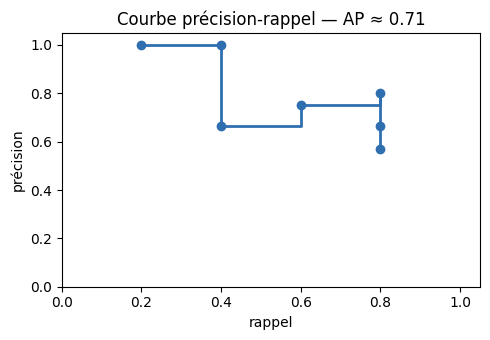

In [8]:
correct = np.array([1, 1, 0, 1, 1, 0, 0])            # détections triées par confiance décroissante
conf_ex = np.array([0.95, 0.90, 0.80, 0.70, 0.60, 0.40, 0.30])
n_truth = 5
tp = np.cumsum(correct); fp = np.cumsum(1 - correct)
precision, recall = tp / (tp + fp), tp / n_truth
ap = np.sum(np.diff(np.concatenate([[0], recall])) * precision)   # aire sous la courbe (rectangles)

display(pd.DataFrame({"confiance": conf_ex, "correcte": np.where(correct, "V", "F"),
                      "précision": precision.round(2), "rappel": recall.round(2)})) if "display" in globals() else None
plt.figure(figsize=(5, 3.5))
plt.step(recall, precision, where="post", color="#2f6fb0", lw=2); plt.scatter(recall, precision, color="#2f6fb0")
plt.xlabel("rappel"); plt.ylabel("précision"); plt.xlim(0, 1.05); plt.ylim(0, 1.05)
plt.title(f"Courbe précision-rappel — AP ≈ {ap:.2f}"); plt.tight_layout(); plt.show()

### 8.7 Extraction des visages et cohérence du prétraitement

**Point d'attention de l'énoncé :** chaque visage extrait doit subir **exactement le même prétraitement** que
les images d'entraînement du CNN : **niveaux de gris → 48 × 48 → pixels / 255 → forme (48, 48, 1)**.

Deux précautions supplémentaires :
- on rend la boîte **carrée** avant de redimensionner : les images FER-2013 sont carrées ; redimensionner un
  rectangle en 48 × 48 déformerait le visage (étiré ou écrasé) ;
- on ajoute une **petite marge** (10 %), car les visages FER-2013 sont cadrés un peu plus large que les boîtes
  YOLO (front et menton inclus).

In [9]:
def preprocess_face(face_bgr, size=IMG_SIZE):
    # IDENTIQUE à la Partie 1 : niveaux de gris -> size x size -> /255 -> (size, size, 1)
    gray = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (size, size), interpolation=cv2.INTER_LINEAR)
    return (gray.astype(np.float32) / 255.0)[..., np.newaxis]

def square_box(x1, y1, x2, y2, img_w, img_h, margin=0.10):
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    side = max(x2 - x1, y2 - y1) * (1 + margin)
    nx1, ny1 = int(max(0, cx - side / 2)), int(max(0, cy - side / 2))
    nx2, ny2 = int(min(img_w, cx + side / 2)), int(min(img_h, cy + side / 2))
    return nx1, ny1, nx2, ny2

# Vérification : une image de test FER-2013 passée par ce prétraitement reste identique à celle de la Partie 1
X_test = data["X_test"]
fer_img = (X_test[0, :, :, 0] * 255).round().astype(np.uint8)
again = preprocess_face(cv2.cvtColor(fer_img, cv2.COLOR_GRAY2BGR))
print("Prétraitement cohérent avec la Partie 1 :", np.allclose(again, X_test[0], atol=1 / 255))

Prétraitement cohérent avec la Partie 1 : True


### 8.8 Le pipeline complet

`analyser_image` enchaîne : détection YOLO → boîtes → extraction (carrée + marge) → prétraitement → CNN (tous les
visages en un seul lot) → affichage. Une prédiction dont la probabilité maximale est inférieure à 0,40 est
signalée comme **incertaine** (cf. l'analyse confiance / justesse de la Partie 5).

In [10]:
COLORS = {"Joie": (60, 180, 75), "Surprise": (0, 200, 255), "Neutre": (200, 200, 200), "Tristesse": (200, 120, 40),
          "Colère": (40, 40, 220), "Peur": (180, 60, 160), "Dégoût": (40, 140, 140)}   # couleurs BGR
UNCERTAIN = 0.40

def analyser_image(img_bgr, det_conf=0.5, det_iou=0.5, margin=0.10):
    h, w = img_bgr.shape[:2]
    t0 = time.time()
    det = face_detector.predict(img_bgr, conf=det_conf, iou=det_iou, verbose=False)[0]
    t_det = time.time() - t0
    faces, results = [], []
    for (x1, y1, x2, y2), c in zip(det.boxes.xyxy.cpu().numpy(), det.boxes.conf.cpu().numpy()):
        sx1, sy1, sx2, sy2 = square_box(x1, y1, x2, y2, w, h, margin)
        crop = img_bgr[sy1:sy2, sx1:sx2]
        if crop.size == 0:
            continue
        faces.append(preprocess_face(crop))
        results.append({"box": (int(x1), int(y1), int(x2), int(y2)), "conf_visage": float(c)})
    t1 = time.time()
    if faces:
        probas = emotion_model.predict(np.stack(faces), verbose=0)
        for res, face, p in zip(results, faces, probas):
            k = int(p.argmax())
            res.update({"face": face, "probas": p, "expression": CLASSES_FR[k], "proba": float(p[k])})
    t_cnn = time.time() - t1
    return results, {"détection (ms)": 1000 * t_det, "CNN (ms)": 1000 * t_cnn}

def dessiner(img_bgr, results):
    out = img_bgr.copy()
    scale = max(out.shape[:2]) / 1000
    for r in results:
        x1, y1, x2, y2 = r["box"]
        label = r["expression"] if r["proba"] >= UNCERTAIN else f"{r['expression']}?"
        color = COLORS.get(r["expression"], (255, 255, 255)) if r["proba"] >= UNCERTAIN else (160, 160, 160)
        text = f"{label} {r['proba']:.2f}"
        th = max(1, int(2 * scale))
        cv2.rectangle(out, (x1, y1), (x2, y2), color, max(2, int(3 * scale)))
        (tw, tht), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7 * scale + 0.3, th)
        cv2.rectangle(out, (x1, max(0, y1 - tht - 10)), (x1 + tw + 6, y1), color, -1)
        cv2.putText(out, text, (x1 + 3, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7 * scale + 0.3, (0, 0, 0), th, cv2.LINE_AA)
    return out

def afficher_analyse(path, save=True):
    img = cv2.imread(path)
    results, timing = analyser_image(img)
    out = dessiner(img, results)
    if save:
        cv2.imwrite(os.path.join(WORK_DIR, "resultat_" + os.path.basename(path)), out)
    n = len(results)
    rows = (n + 3) // 4
    fig = plt.figure(figsize=(16, 7 + 2.2 * rows))
    gs = fig.add_gridspec(1 + rows, 8, height_ratios=[3.2] + [1] * rows)
    show_bgr(out, f"{os.path.basename(path)} — {n} visage(s) | détection {timing['détection (ms)']:.0f} ms, "
                  f"CNN {timing['CNN (ms)']:.0f} ms", fig.add_subplot(gs[0, :]))
    for i, r in enumerate(results):           # ce que voit réellement le CNN + ses probabilités
        row, col = 1 + i // 4, 2 * (i % 4)
        a1, a2 = fig.add_subplot(gs[row, col]), fig.add_subplot(gs[row, col + 1])
        a1.imshow(r["face"][..., 0], cmap="gray", vmin=0, vmax=1); a1.axis("off")
        a1.set_title(f"visage {i + 1} (48×48)", fontsize=9)
        a2.barh(CLASSES_FR, r["probas"], color=["#c0392b" if c == r["expression"] else "#bbb" for c in CLASSES_FR])
        a2.set_xlim(0, 1); a2.invert_yaxis(); a2.tick_params(labelsize=7)
    plt.tight_layout(); plt.show()
    return pd.DataFrame([{"visage": i + 1, "boîte (x1,y1,x2,y2)": r["box"], "confiance visage": round(r["conf_visage"], 2),
                          "expression": r["expression"], "probabilité": round(r["proba"], 2)} for i, r in enumerate(results)])

### 8.9 Résultats sur les images de démonstration

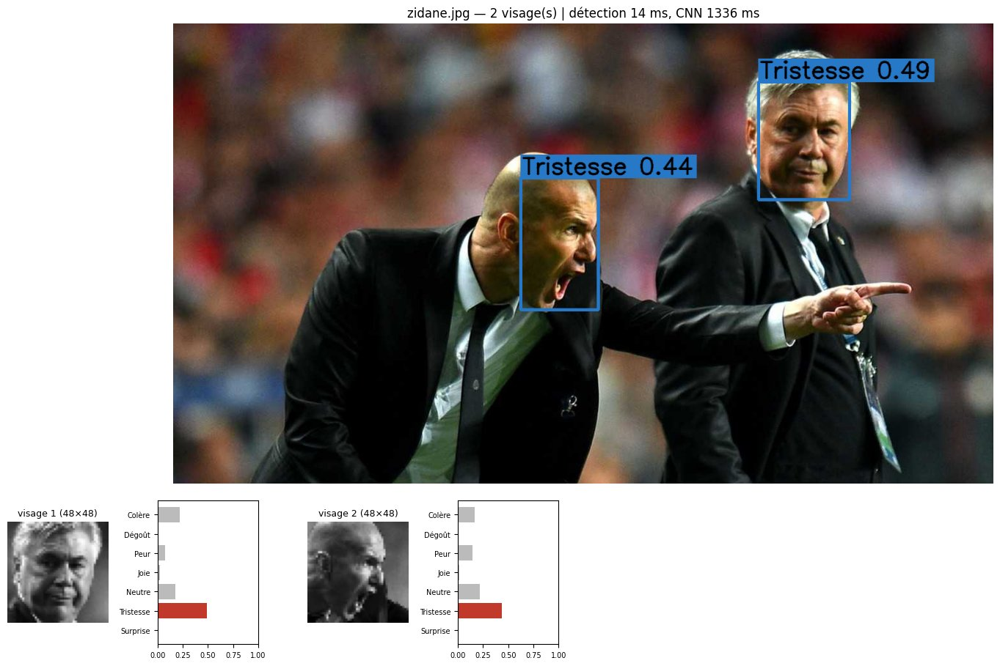

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (913, 92, 1055, 276)              0.82  Tristesse         0.49
1       2  (542, 242, 663, 448)              0.77  Tristesse         0.44


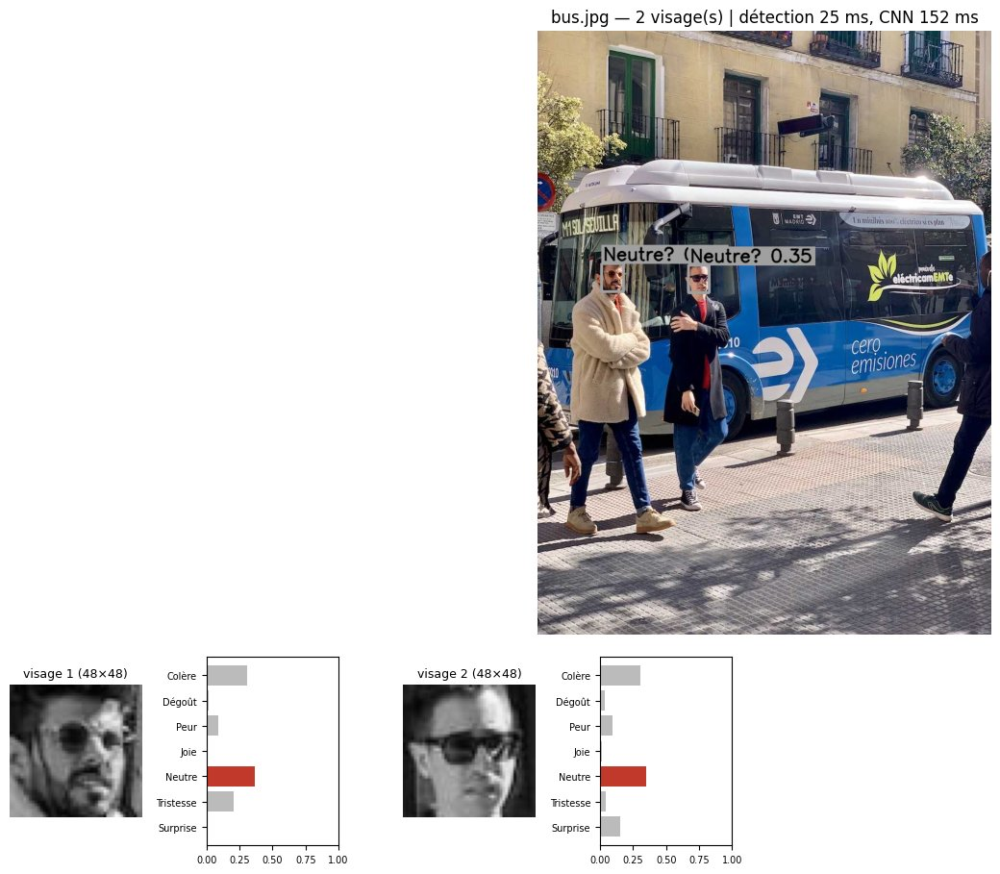

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (114, 417, 153, 467)              0.79     Neutre         0.36
1       2  (269, 420, 306, 469)              0.75     Neutre         0.35


In [11]:
for p in demo_paths:
    tab = afficher_analyse(p)
    display(tab) if "display" in globals() else print(tab)

### 8.10 Résultats sur vos propres images

Déposez des photos de groupe dans `MyDrive/projet_dl/images_test/` puis relancez cette cellule. Idéalement :
plusieurs personnes avec des expressions différentes et visibles, visages de face. Les images annotées sont
enregistrées dans `MyDrive/projet_dl/partie8/`.

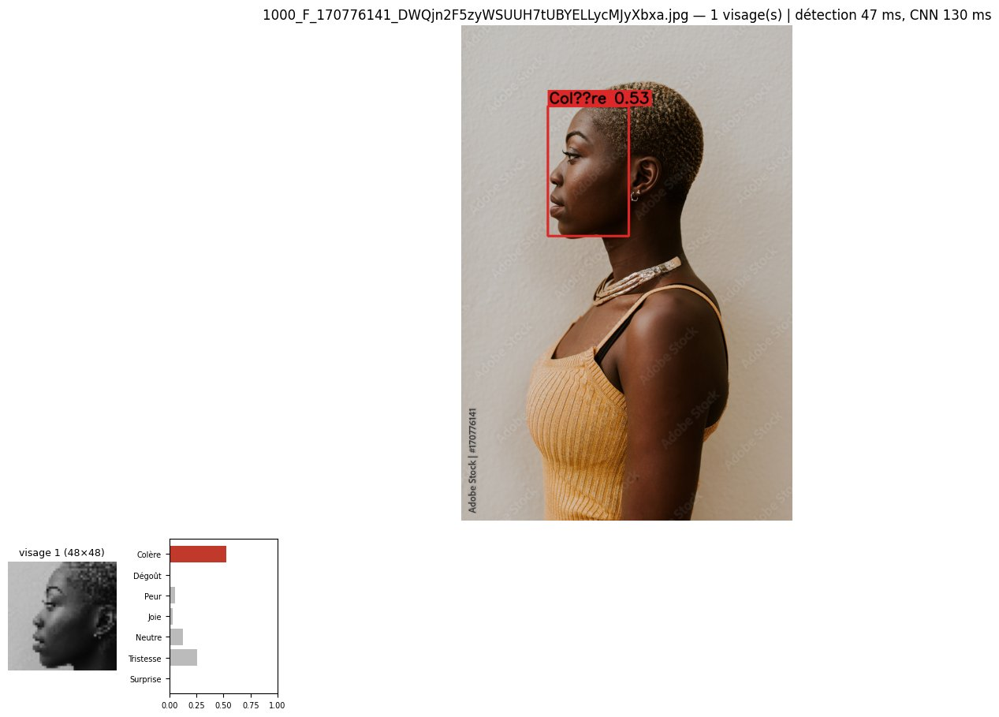

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (174, 164, 337, 426)               0.8     Colère         0.53


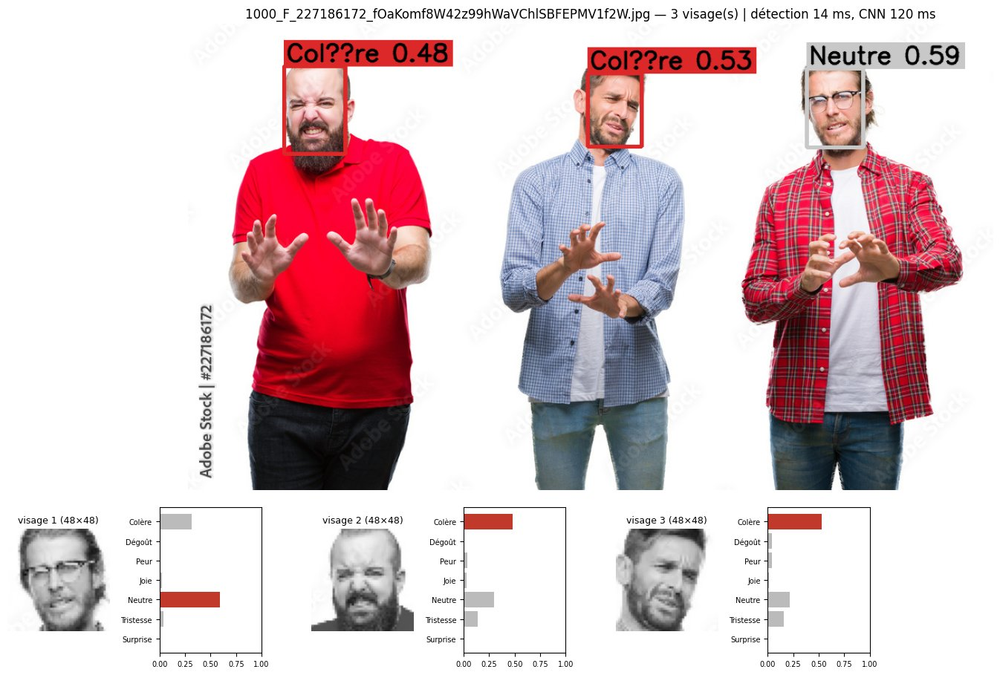

   visage  boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (768, 56, 838, 154)              0.83     Neutre         0.59
1       2  (119, 53, 195, 162)              0.82     Colère         0.48
2       3  (496, 62, 563, 153)              0.81     Colère         0.53


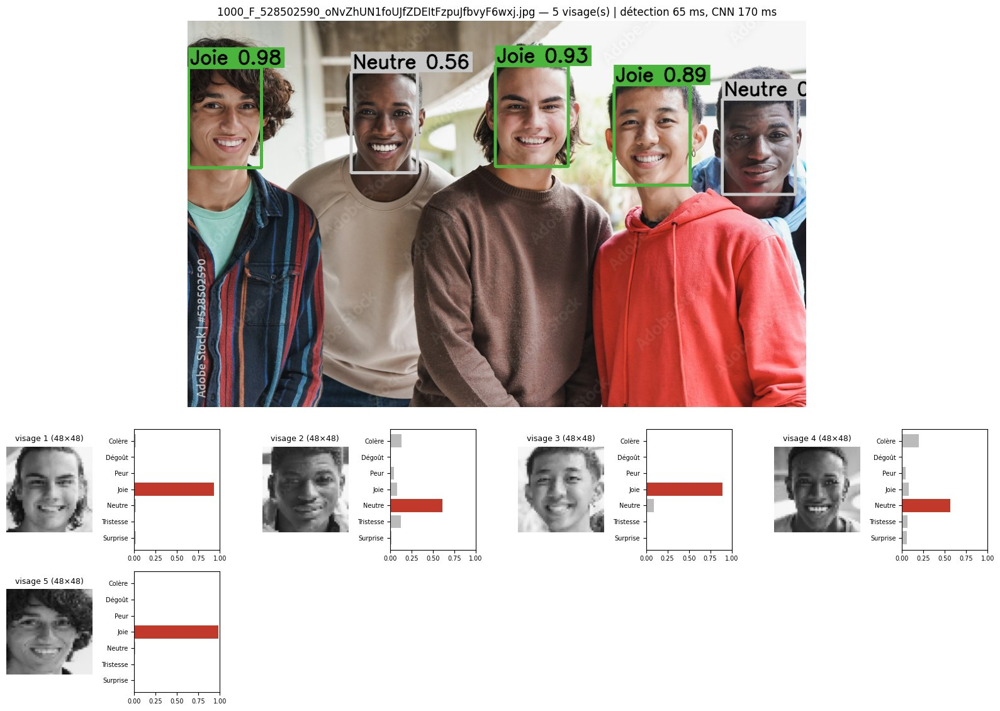

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1   (497, 73, 615, 236)              0.87       Joie         0.93
1       2  (864, 127, 982, 281)              0.87     Neutre         0.61
2       3  (689, 104, 812, 266)              0.86       Joie         0.89
3       4   (264, 83, 371, 246)              0.85     Neutre         0.56
4       5     (1, 76, 119, 238)              0.84       Joie         0.98


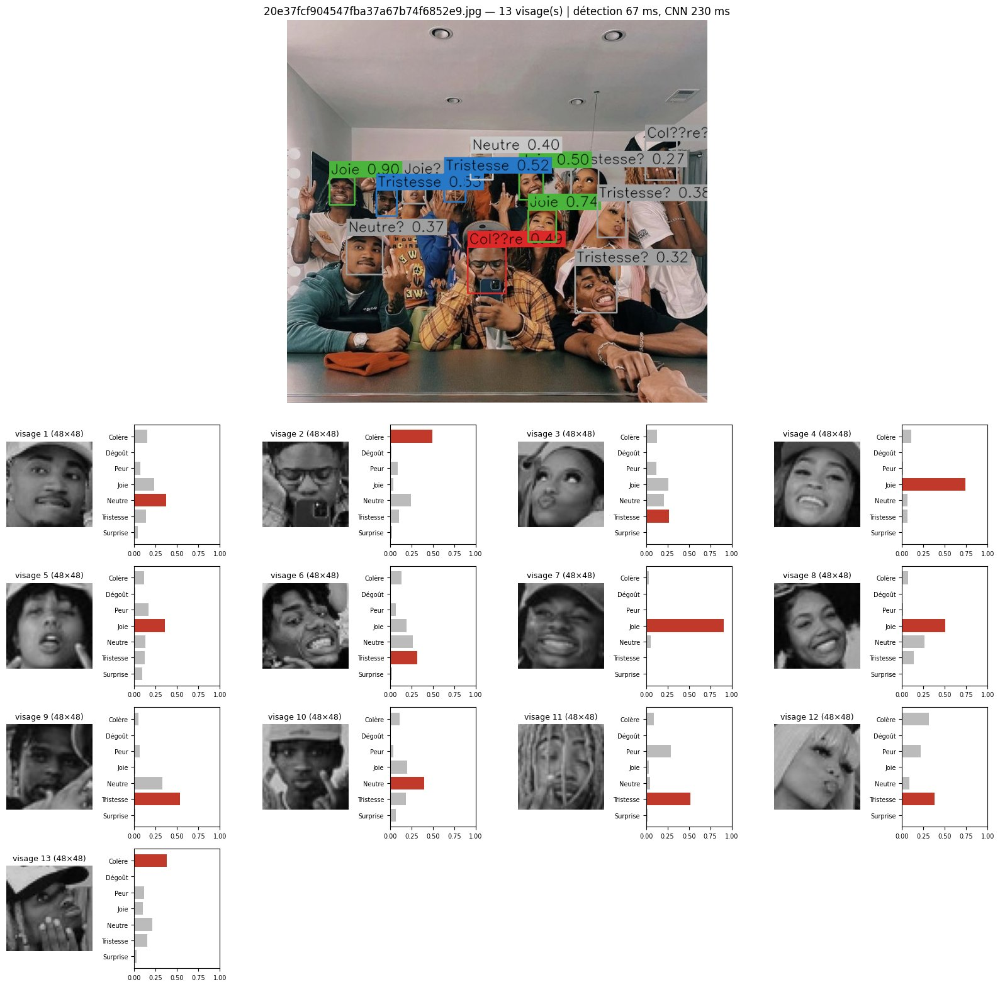

    visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0        1  (104, 377, 167, 446)              0.82     Neutre         0.37
1        2  (316, 398, 383, 479)              0.81     Colère         0.49
2        3  (497, 258, 545, 316)              0.81  Tristesse         0.27
3        4  (422, 333, 471, 389)              0.80       Joie         0.74
4        5  (202, 275, 242, 322)              0.79       Joie         0.36
5        6  (504, 430, 577, 513)              0.79  Tristesse         0.32
6        7   (74, 276, 118, 324)              0.78       Joie         0.90
7        8  (406, 259, 448, 315)              0.78       Joie         0.50
8        9  (156, 298, 192, 344)              0.75  Tristesse         0.53
9       10  (321, 233, 360, 280)              0.73     Neutre         0.40
10      11  (275, 269, 312, 319)              0.72  Tristesse         0.52
11      12  (543, 317, 593, 381)              0.68  Tristesse         0.38
12      13  (627, 212, 68

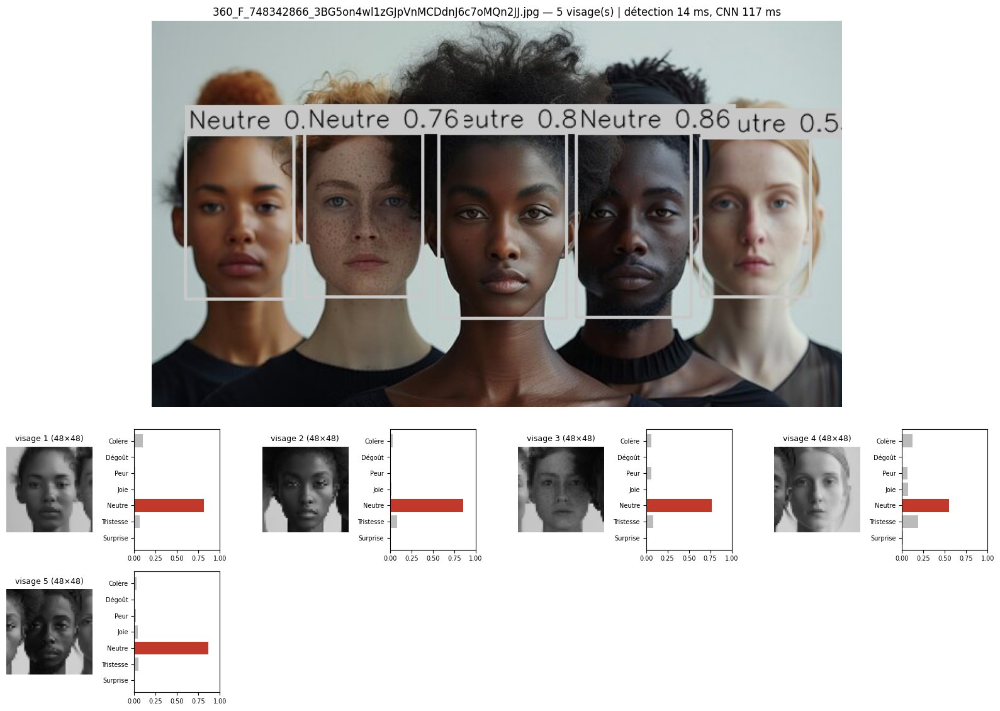

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1   (31, 106, 132, 259)              0.86     Neutre         0.81
1       2  (267, 105, 386, 277)              0.86     Neutre         0.86
2       3  (142, 105, 252, 257)              0.85     Neutre         0.76
3       4  (511, 109, 613, 257)              0.84     Neutre         0.55
4       5  (395, 105, 502, 276)              0.83     Neutre         0.86


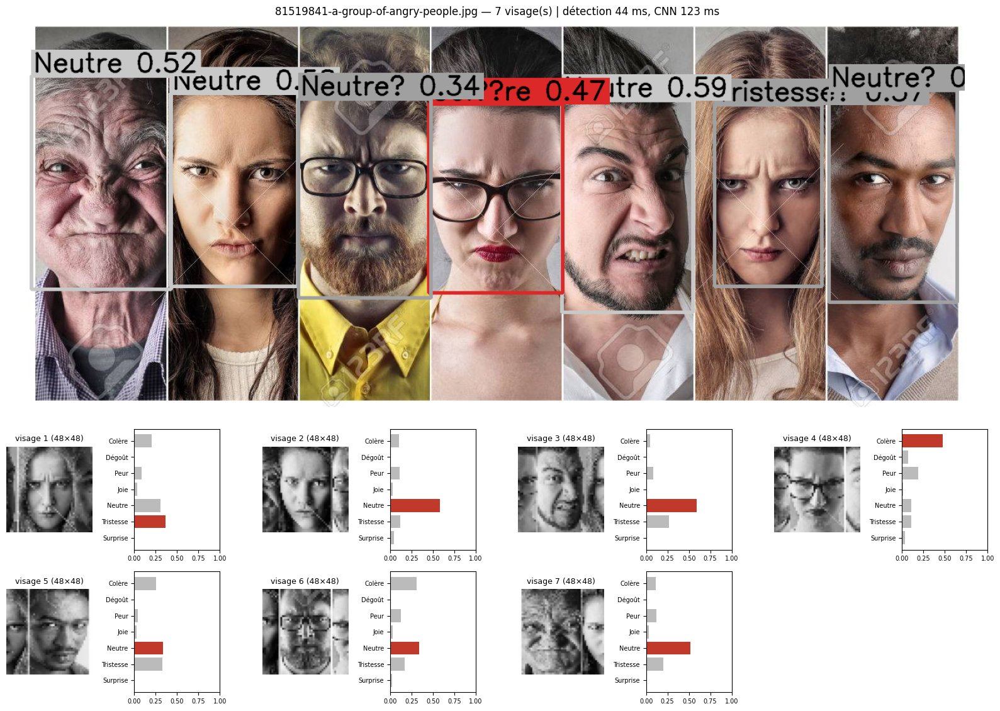

   visage    boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (952, 117, 1101, 369)              0.86  Tristesse         0.37
1       2   (196, 101, 373, 369)              0.86     Neutre         0.58
2       3   (740, 111, 922, 405)              0.86     Neutre         0.59
3       4   (555, 116, 741, 378)              0.86     Colère         0.47
4       5  (1111, 97, 1289, 391)              0.85     Neutre         0.34
5       6   (374, 109, 558, 385)              0.83     Neutre         0.34
6       7      (3, 77, 197, 373)              0.81     Neutre         0.52


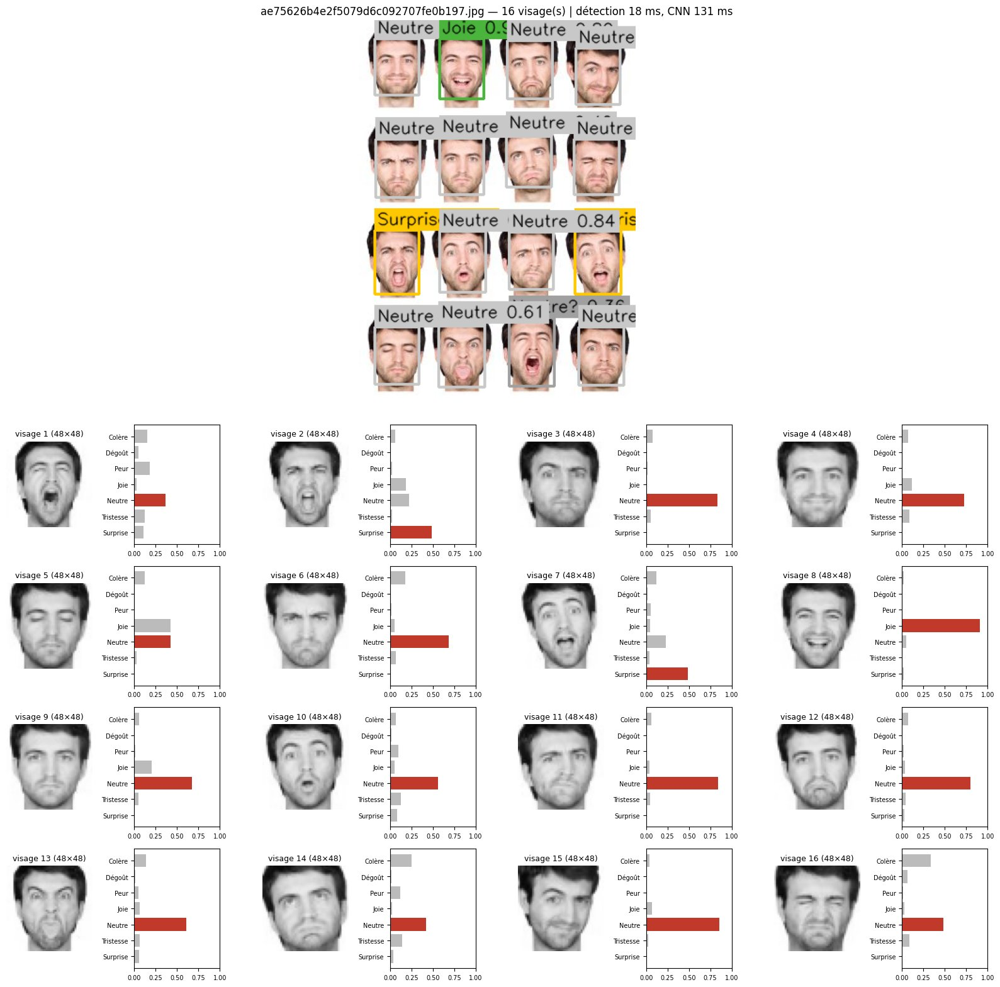

    visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0        1  (159, 317, 207, 390)              0.86     Neutre         0.36
1        2    (16, 224, 63, 292)              0.86   Surprise         0.49
2        3  (233, 327, 281, 389)              0.85     Neutre         0.83
3        4      (16, 20, 63, 80)              0.85     Neutre         0.72
4        5    (16, 327, 63, 388)              0.85     Neutre         0.42
5        6    (17, 127, 64, 189)              0.85     Neutre         0.69
6        7  (229, 224, 278, 292)              0.85   Surprise         0.49
7        8     (85, 20, 132, 84)              0.85       Joie         0.91
8        9   (85, 125, 132, 186)              0.85     Neutre         0.68
9       10   (85, 225, 134, 290)              0.85     Neutre         0.56
10      11  (159, 226, 206, 287)              0.85     Neutre         0.84
11      12    (157, 22, 205, 84)              0.84     Neutre         0.80
12      13   (84, 323, 13

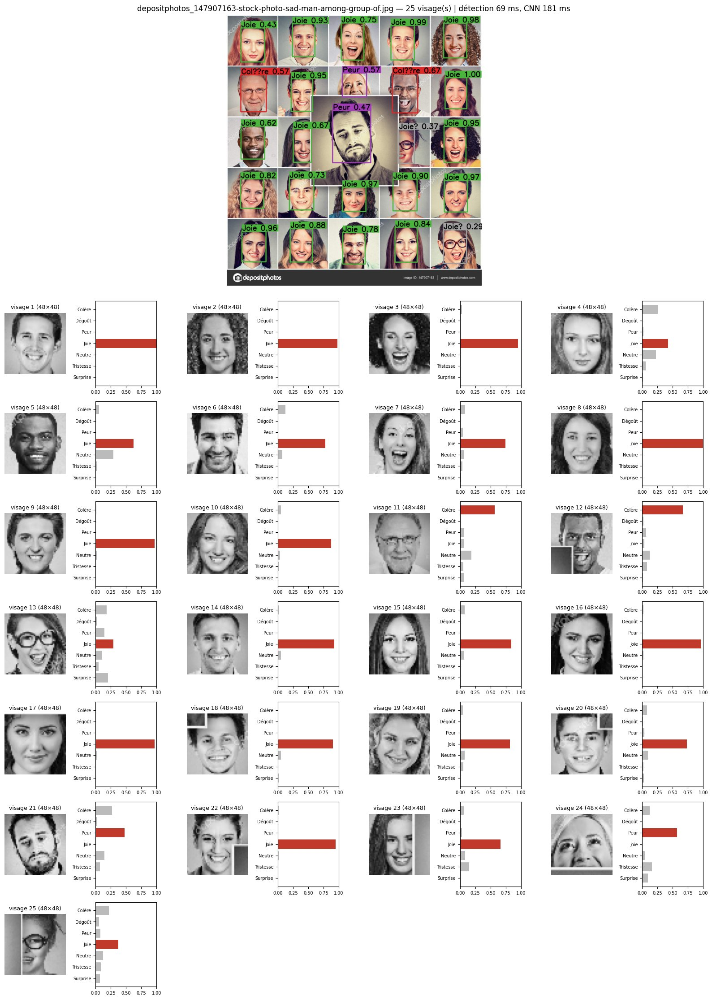

    visage       boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0        1     (1030, 67, 1177, 283)              0.87       Joie         0.99
1        2     (1361, 52, 1505, 270)              0.87       Joie         0.98
2        3    (1363, 700, 1501, 926)              0.86       Joie         0.95
3        4        (89, 82, 238, 295)              0.86       Joie         0.43
4        5       (89, 699, 238, 905)              0.86       Joie         0.62
5        6    (728, 1366, 868, 1564)              0.86       Joie         0.78
6        7       (718, 51, 860, 284)              0.86       Joie         0.75
7        8    (1370, 394, 1506, 589)              0.86       Joie         1.00
8        9  (1365, 1039, 1510, 1237)              0.85       Joie         0.97
9       10    (398, 1341, 537, 1551)              0.85       Joie         0.88
10      11       (88, 376, 248, 608)              0.85     Colère         0.57
11      12    (1039, 370, 1198, 615)              0.

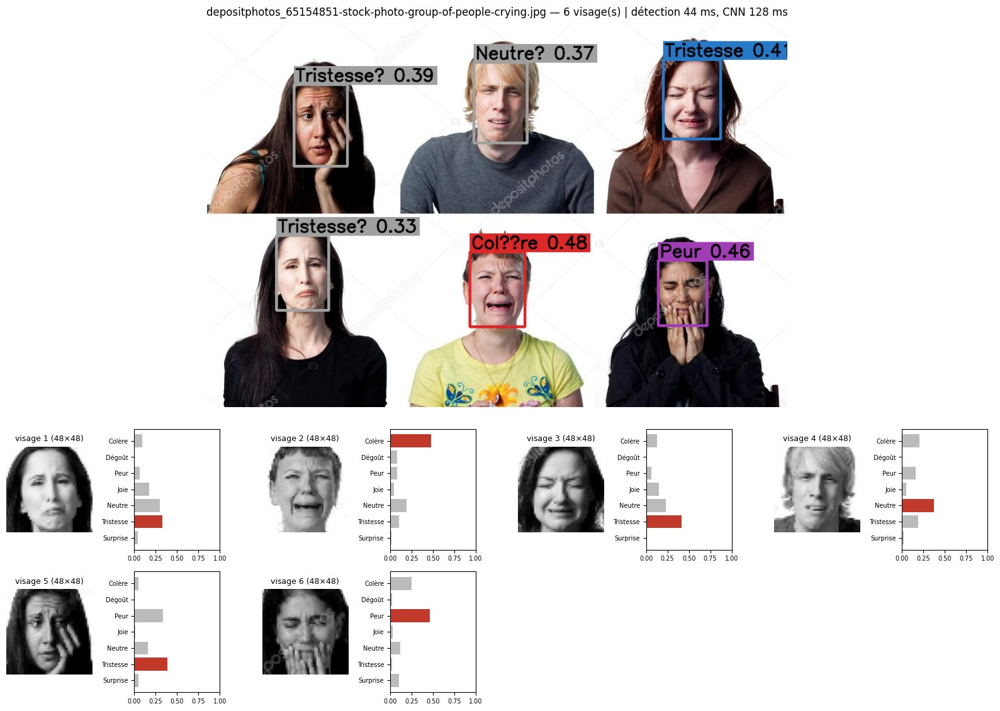

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (122, 379, 214, 511)              0.86  Tristesse         0.33
1       2  (463, 408, 560, 540)              0.85     Colère         0.48
2       3   (804, 69, 905, 209)              0.85  Tristesse         0.41
3       4   (470, 74, 564, 216)              0.84     Neutre         0.37
4       5  (153, 113, 247, 257)              0.83  Tristesse         0.39
5       6  (795, 423, 881, 538)              0.82       Peur         0.46


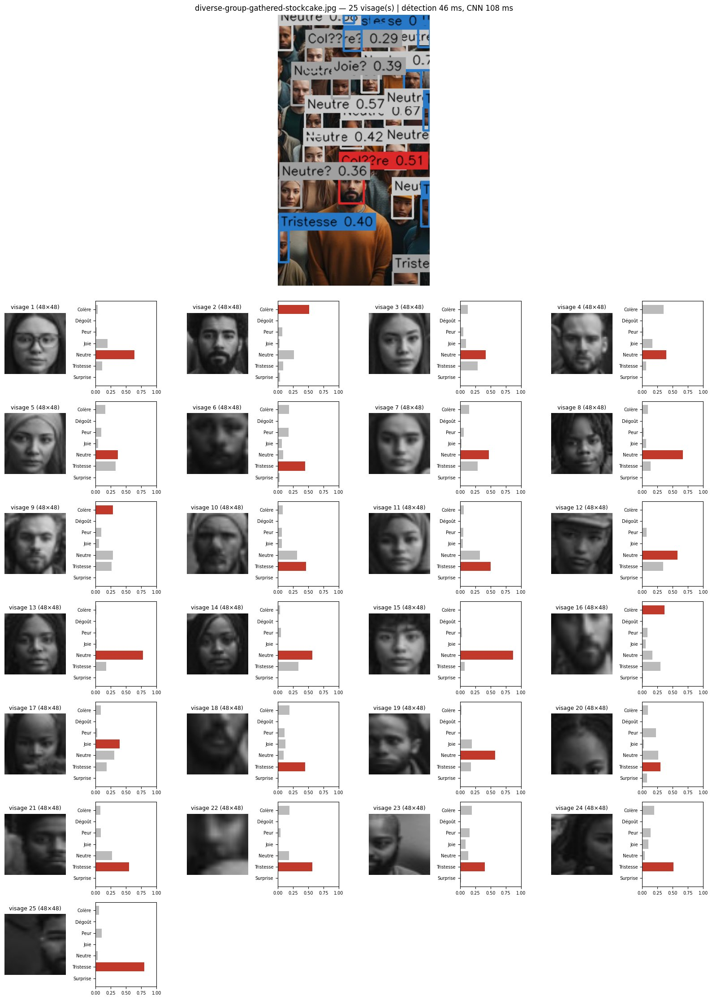

    visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0        1  (143, 172, 172, 207)              0.84     Neutre         0.63
1        2   (82, 207, 115, 253)              0.83     Colère         0.51
2        3    (34, 175, 61, 210)              0.83     Neutre         0.42
3        4     (18, 86, 43, 121)              0.83     Neutre         0.39
4        5     (2, 221, 31, 259)              0.82     Neutre         0.36
5        6     (151, 0, 176, 23)              0.82  Tristesse         0.45
6        7    (149, 40, 173, 69)              0.81     Neutre         0.47
7        8   (84, 140, 114, 179)              0.81     Neutre         0.67
8        9      (37, 43, 61, 76)              0.81     Colère         0.29
9       10   (169, 75, 192, 104)              0.81  Tristesse         0.46
10      11     (88, 19, 112, 48)              0.80  Tristesse         0.50
11      12  (153, 241, 181, 273)              0.80     Neutre         0.58
12      13   (112, 72, 13

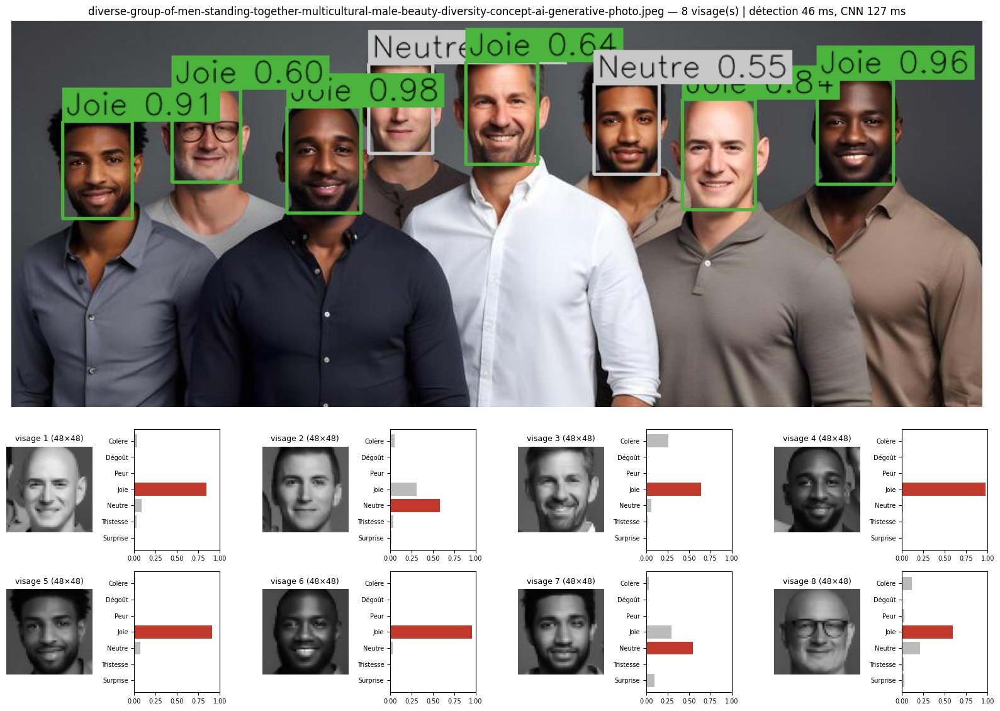

   visage  boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (607, 71, 673, 171)              0.84       Joie         0.84
1       2  (323, 39, 381, 120)              0.84     Neutre         0.58
2       3  (411, 37, 476, 130)              0.84       Joie         0.64
3       4  (249, 78, 316, 174)              0.84       Joie         0.98
4       5   (46, 91, 109, 179)              0.84       Joie         0.91
5       6  (729, 53, 798, 148)              0.84       Joie         0.96
6       7  (527, 57, 586, 139)              0.82     Neutre         0.55
7       8  (145, 62, 207, 146)              0.81       Joie         0.60


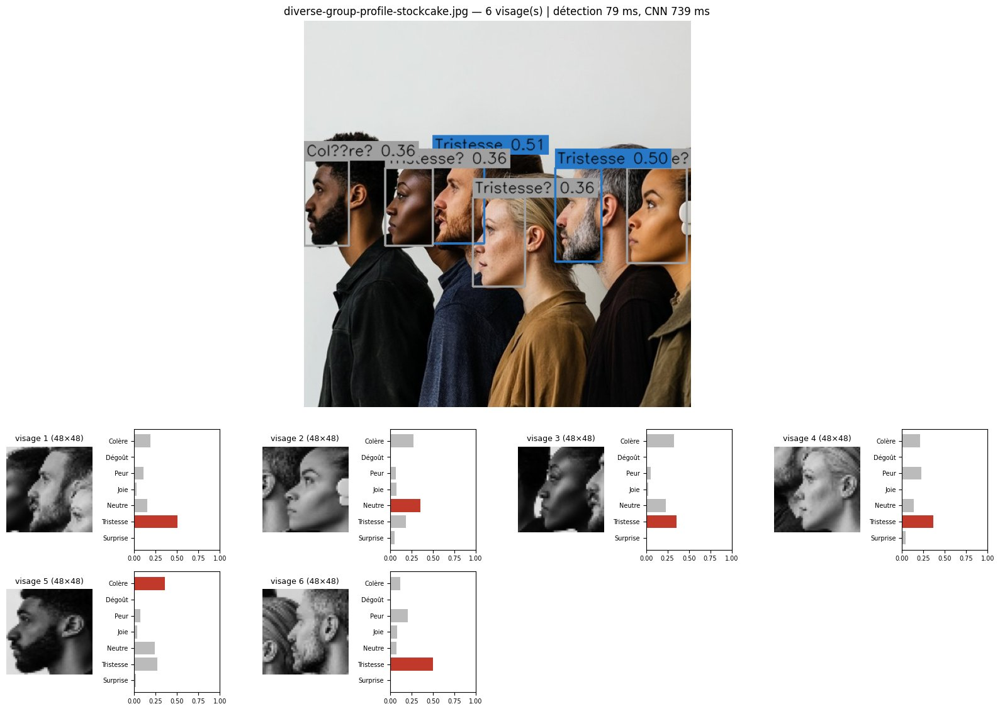

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (170, 177, 238, 295)              0.81  Tristesse         0.51
1       2  (427, 195, 506, 321)              0.80     Neutre         0.36
2       3  (107, 195, 170, 298)              0.79  Tristesse         0.36
3       4  (223, 234, 292, 352)              0.78  Tristesse         0.36
4       5     (0, 185, 59, 298)              0.78     Colère         0.36
5       6  (332, 195, 393, 319)              0.75  Tristesse         0.50


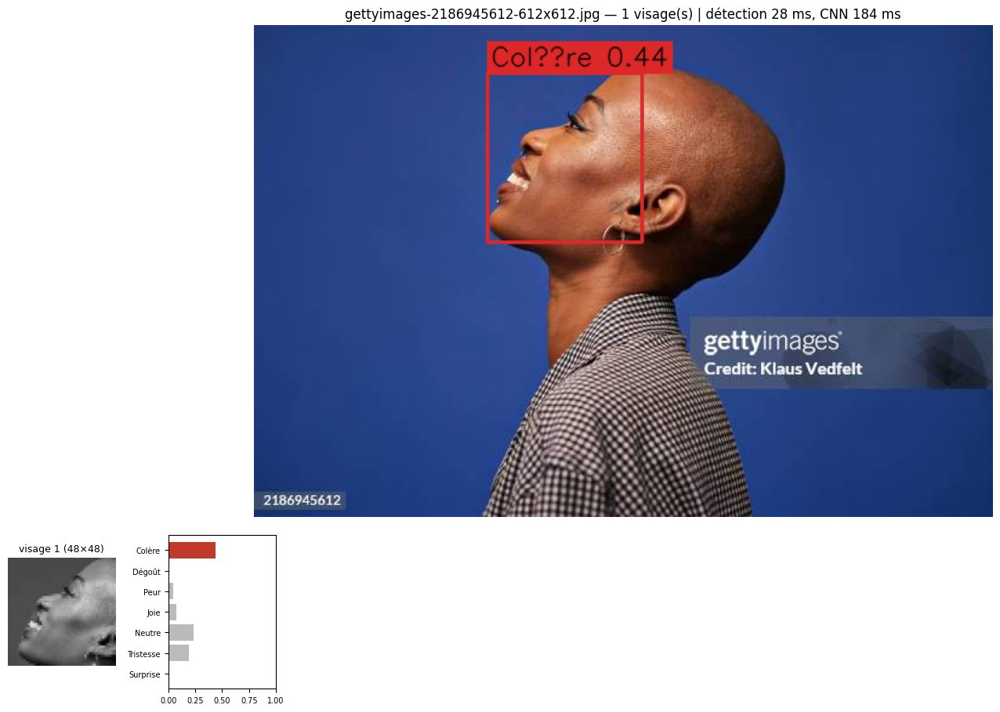

   visage  boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (193, 40, 321, 180)              0.67     Colère         0.44


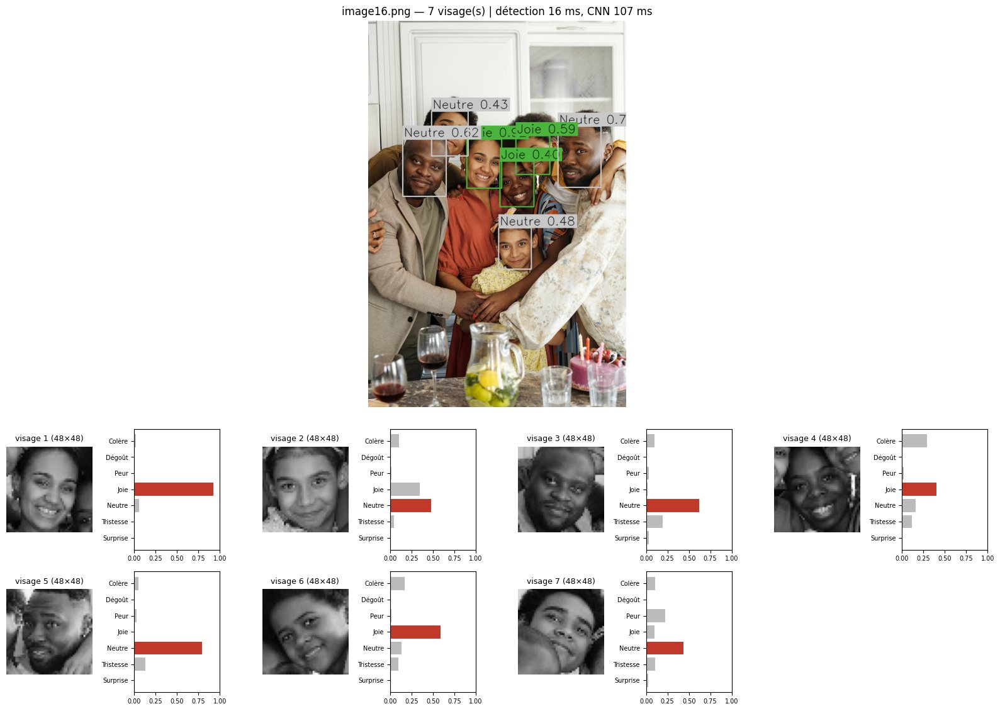

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (229, 276, 310, 390)              0.85       Joie         0.92
1       2  (303, 482, 379, 578)              0.84     Neutre         0.48
2       3   (80, 276, 181, 409)              0.83     Neutre         0.62
3       4  (306, 327, 385, 433)              0.83       Joie         0.40
4       5  (441, 246, 541, 388)              0.82     Neutre         0.79
5       6  (343, 268, 422, 358)              0.82       Joie         0.59
6       7  (147, 211, 232, 315)              0.81     Neutre         0.43


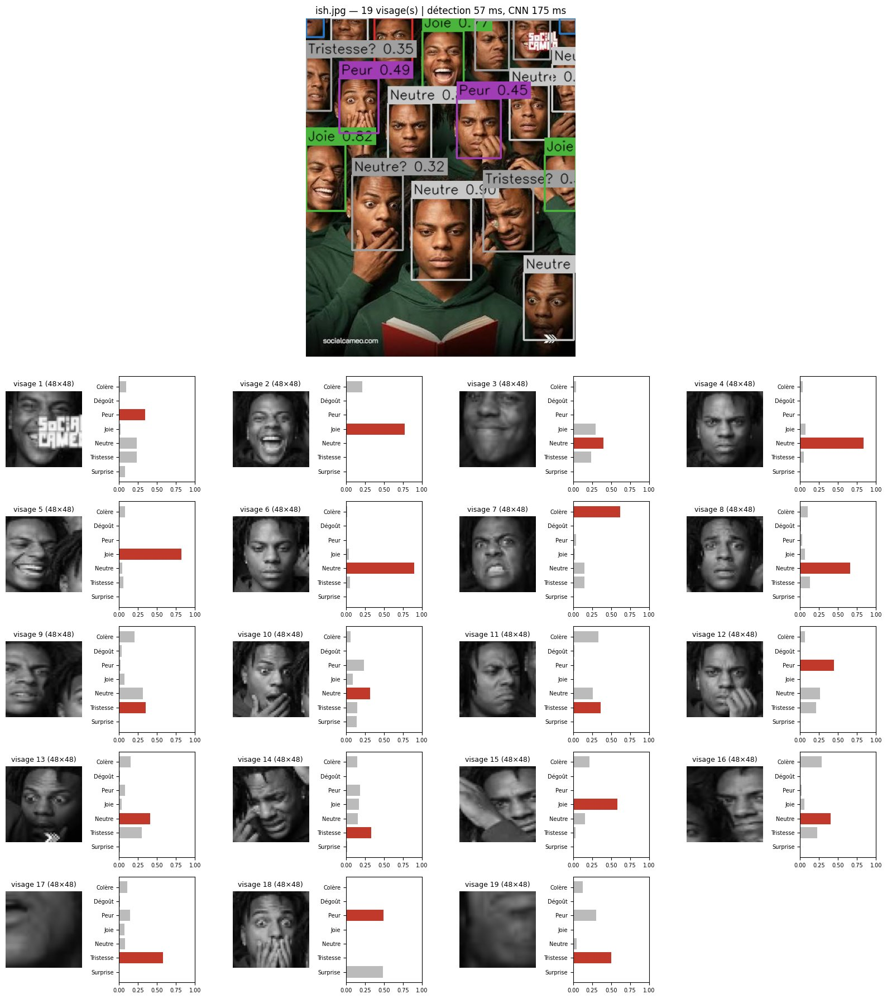

    visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0        1     (307, 0, 361, 61)              0.87       Peur         0.34
1        2   (172, 19, 233, 111)              0.86       Joie         0.77
2        3       (37, 0, 91, 49)              0.86     Neutre         0.40
3        4  (121, 126, 185, 213)              0.86     Neutre         0.84
4        5     (0, 187, 58, 285)              0.86       Joie         0.82
5        6  (156, 266, 244, 387)              0.86     Neutre         0.90
6        7     (101, 0, 157, 73)              0.85     Colère         0.62
7        8   (301, 99, 359, 180)              0.85     Neutre         0.66
8        9      (0, 58, 37, 137)              0.84  Tristesse         0.35
9       10   (68, 232, 143, 343)              0.83     Neutre         0.32
10      11     (250, 3, 300, 77)              0.82  Tristesse         0.36
11      12  (223, 119, 288, 207)              0.82       Peur         0.45
12      13  (322, 376, 39

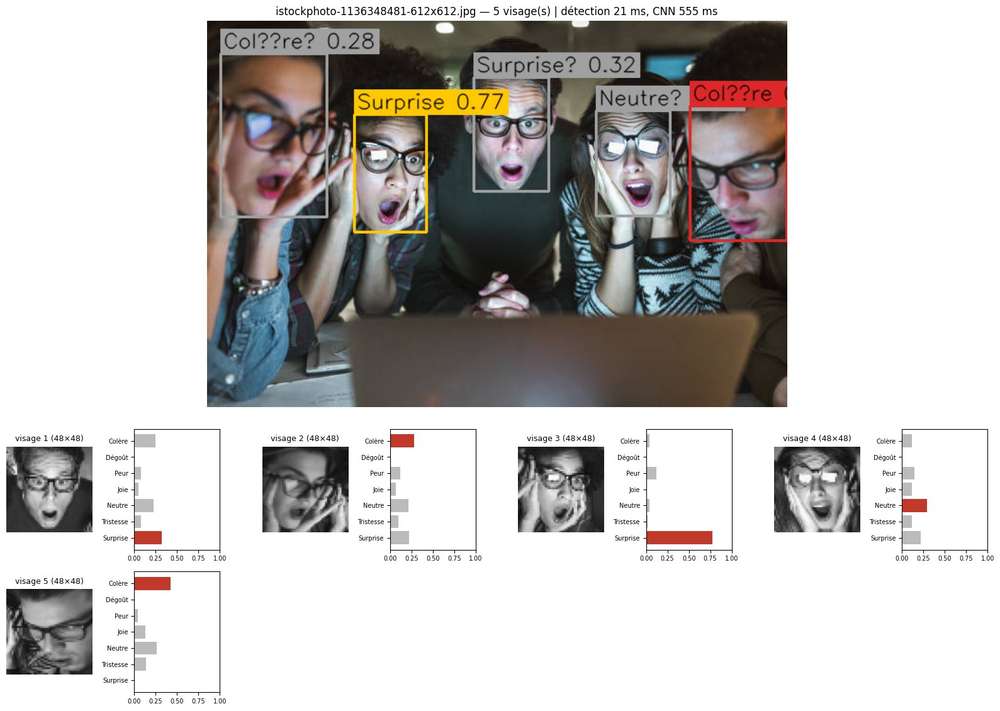

   visage  boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (281, 60, 360, 180)              0.82   Surprise         0.32
1       2   (14, 35, 126, 207)              0.82     Colère         0.28
2       3  (155, 99, 231, 223)              0.81   Surprise         0.77
3       4  (410, 95, 488, 206)              0.80     Neutre         0.29
4       5  (509, 90, 611, 232)              0.78     Colère         0.42


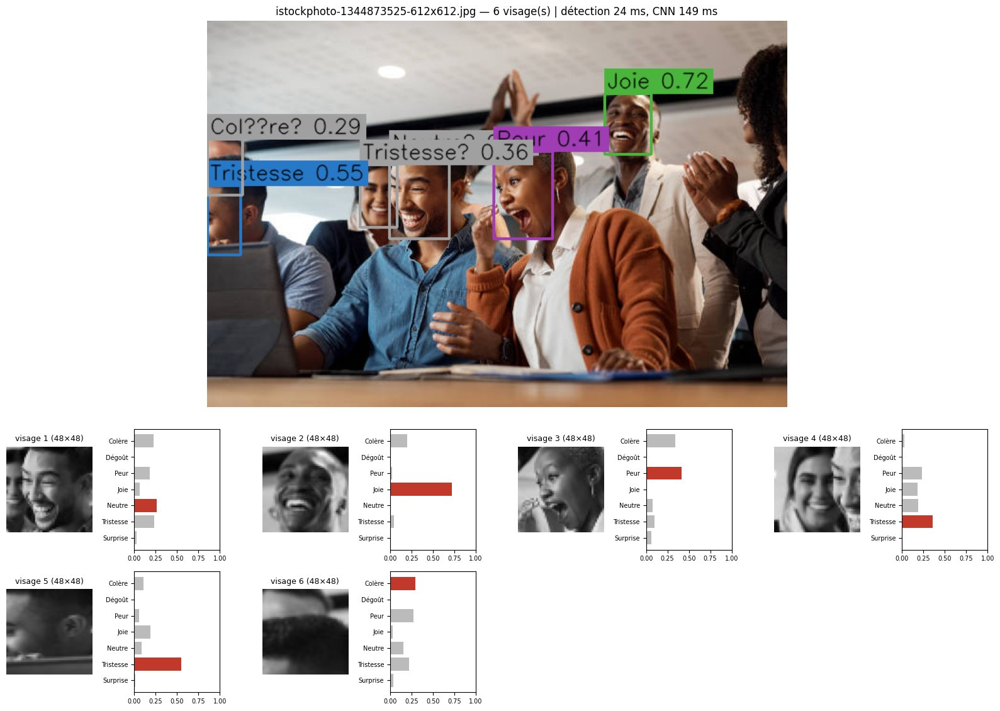

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (192, 142, 255, 230)              0.84     Neutre         0.26
1       2   (419, 77, 468, 141)              0.80       Joie         0.72
2       3  (302, 138, 364, 230)              0.78       Peur         0.41
3       4  (161, 152, 200, 218)              0.77  Tristesse         0.36
4       5     (0, 174, 35, 247)              0.69  Tristesse         0.55
5       6     (0, 125, 37, 184)              0.55     Colère         0.29


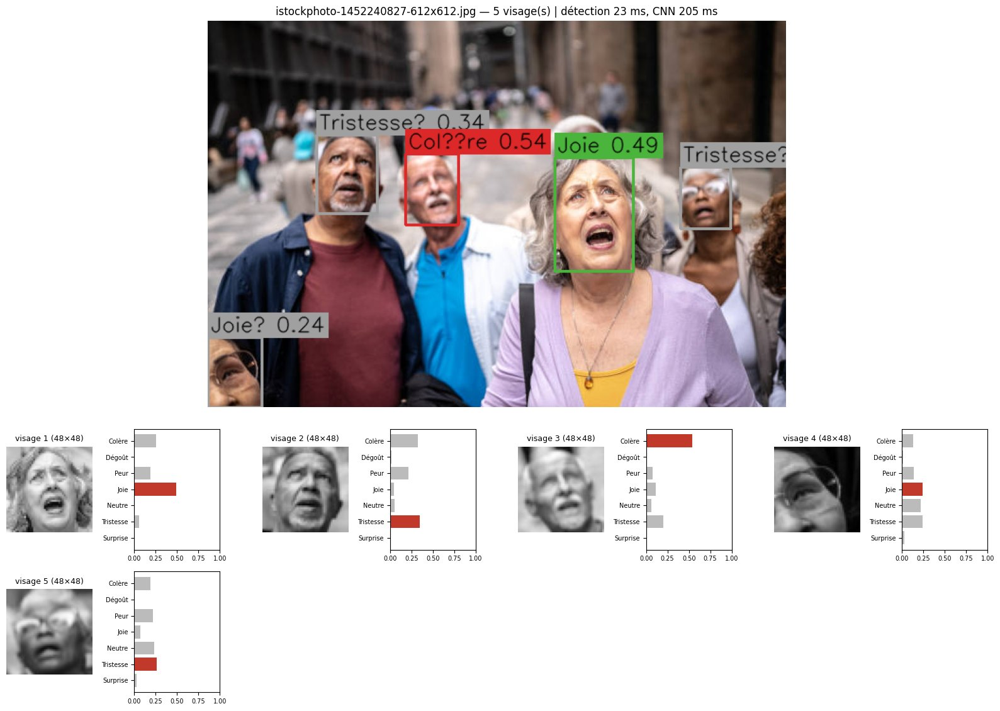

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (367, 145, 450, 265)              0.86       Joie         0.49
1       2  (115, 121, 179, 204)              0.83  Tristesse         0.34
2       3  (209, 141, 265, 216)              0.82     Colère         0.54
3       4     (0, 335, 57, 409)              0.82       Joie         0.24
4       5  (500, 155, 553, 220)              0.80  Tristesse         0.26


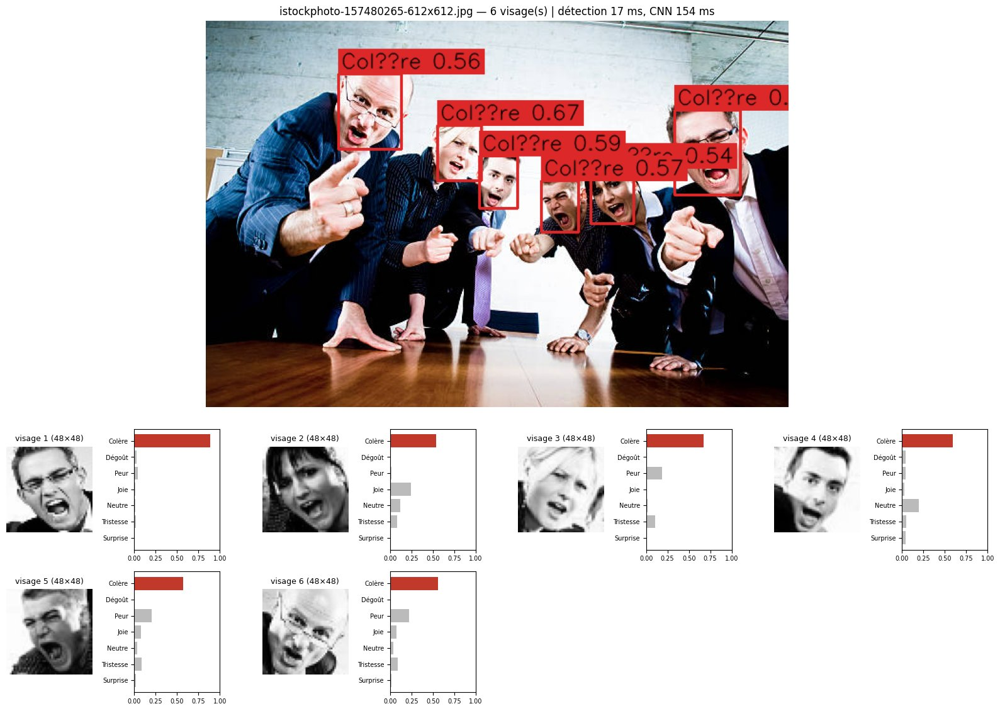

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1   (492, 94, 561, 183)              0.82     Colère         0.88
1       2  (404, 155, 449, 213)              0.79     Colère         0.54
2       3  (243, 110, 289, 168)              0.78     Colère         0.67
3       4  (287, 142, 327, 197)              0.78     Colère         0.59
4       5  (352, 168, 391, 222)              0.77     Colère         0.57
5       6   (139, 56, 205, 135)              0.76     Colère         0.56


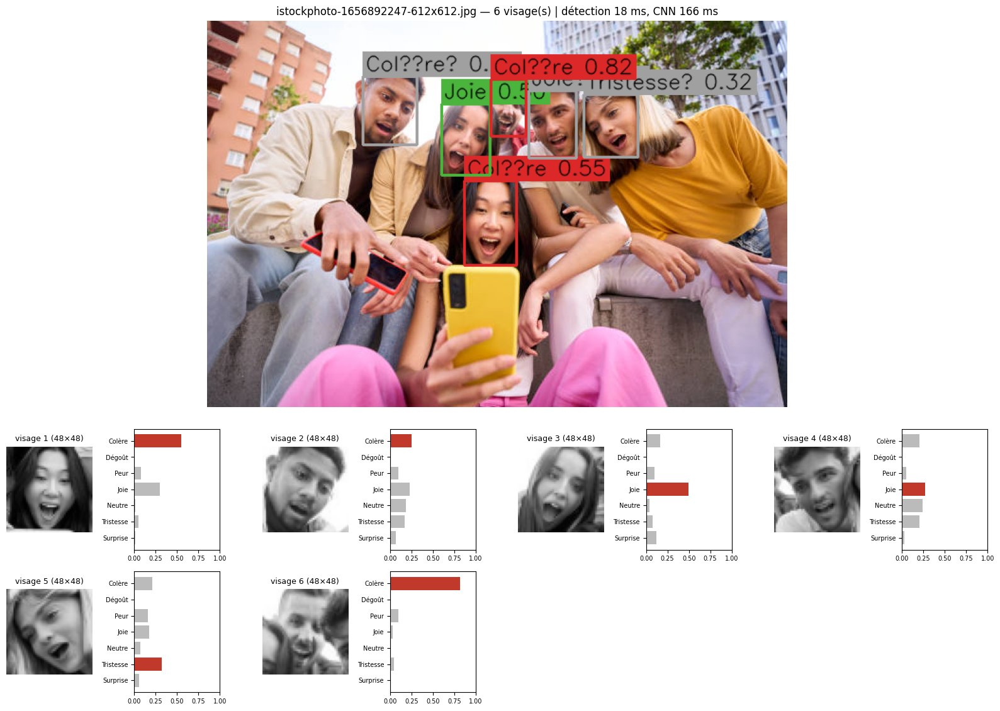

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (271, 169, 326, 258)              0.84     Colère         0.55
1       2   (164, 59, 221, 131)              0.82     Colère         0.25
2       3   (247, 88, 298, 163)              0.82       Joie         0.50
3       4   (339, 74, 389, 145)              0.82       Joie         0.27
4       5   (397, 78, 454, 144)              0.80  Tristesse         0.32
5       6   (299, 62, 336, 122)              0.73     Colère         0.82


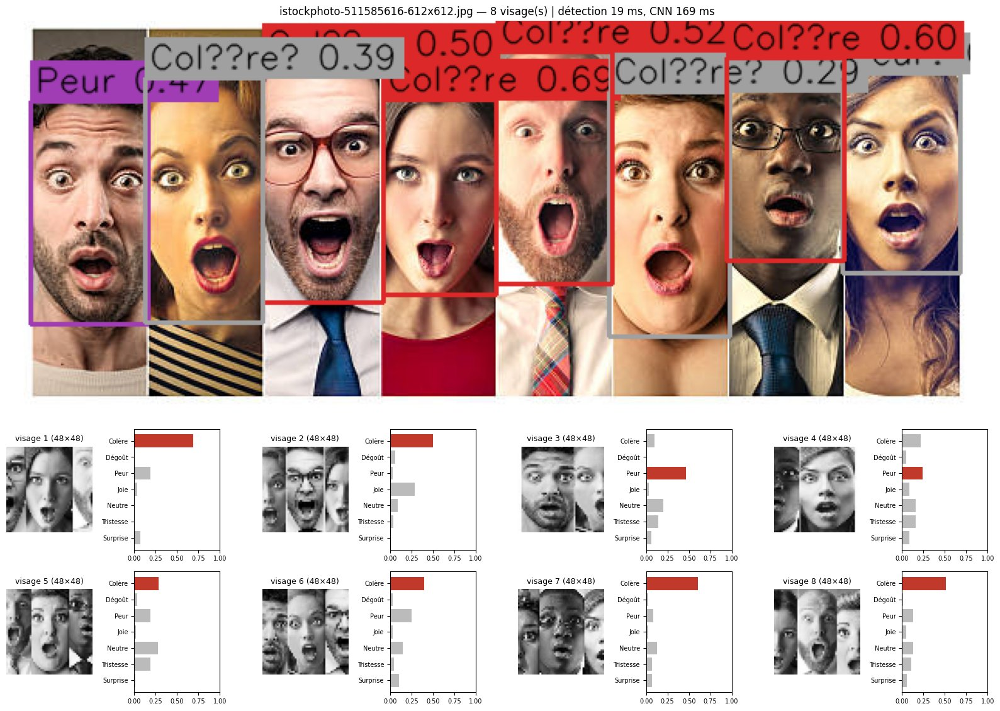

   visage  boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (232, 51, 305, 177)              0.87     Colère         0.69
1       2  (154, 28, 232, 182)              0.87     Colère         0.50
2       3     (4, 52, 80, 196)              0.86       Peur         0.47
3       4  (529, 34, 605, 163)              0.86       Peur         0.24
4       5  (378, 46, 456, 204)              0.85     Colère         0.29
5       6   (78, 37, 154, 195)              0.84     Colère         0.39
6       7  (454, 24, 530, 155)              0.84     Colère         0.60
7       8  (305, 20, 380, 170)              0.81     Colère         0.52


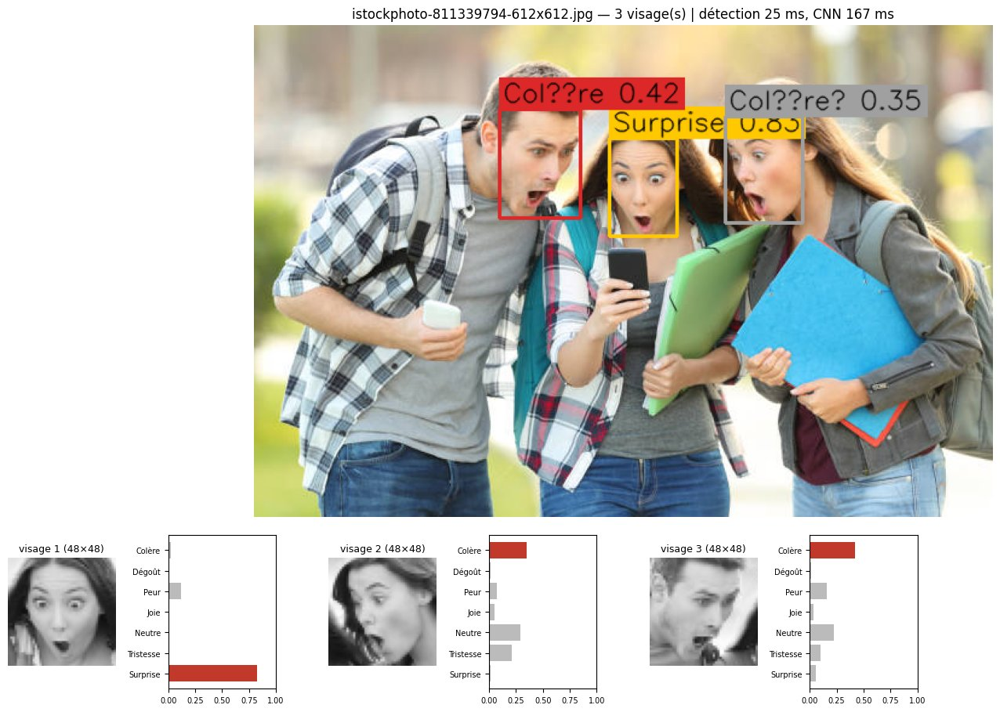

   visage  boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (294, 94, 350, 175)              0.83   Surprise         0.83
1       2  (390, 76, 454, 164)              0.82     Colère         0.35
2       3  (203, 70, 270, 160)              0.80     Colère         0.42


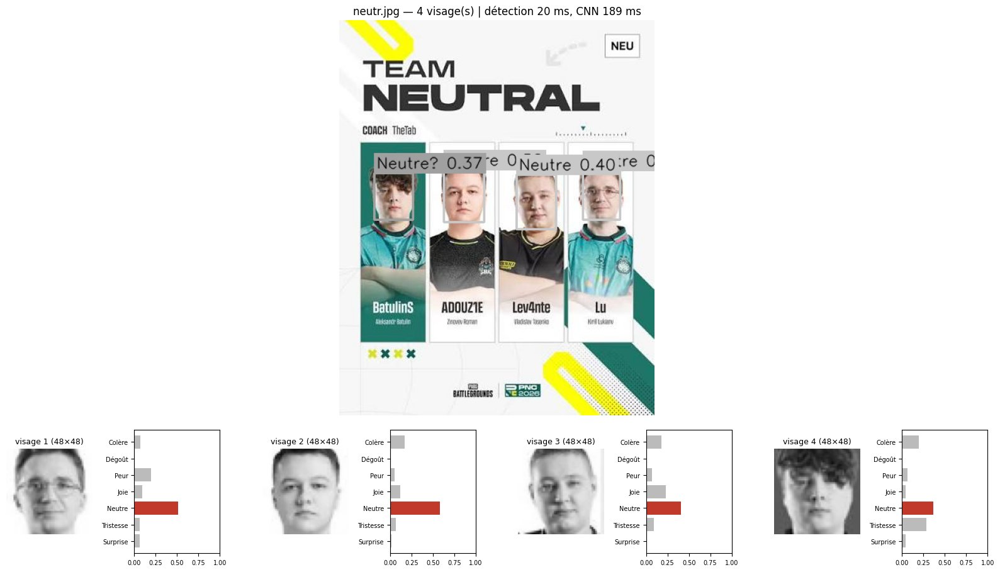

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (308, 191, 355, 253)              0.85     Neutre         0.51
1       2  (132, 190, 183, 256)              0.85     Neutre         0.58
2       3  (224, 196, 274, 265)              0.84     Neutre         0.40
3       4    (44, 194, 93, 253)              0.81     Neutre         0.37


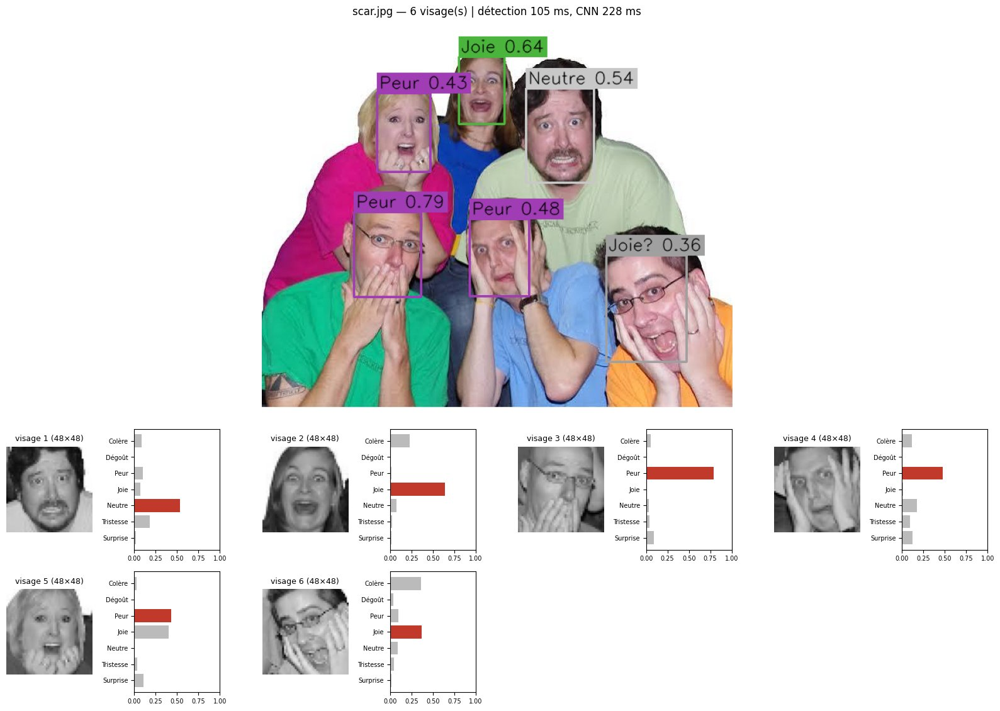

   visage   boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1   (342, 88, 430, 210)              0.85     Neutre         0.54
1       2   (255, 47, 314, 134)              0.84       Joie         0.64
2       3  (119, 248, 206, 358)              0.81       Peur         0.79
3       4  (269, 257, 346, 357)              0.81       Peur         0.48
4       5   (149, 94, 218, 196)              0.80       Peur         0.43
5       6  (446, 304, 550, 442)              0.79       Joie         0.36


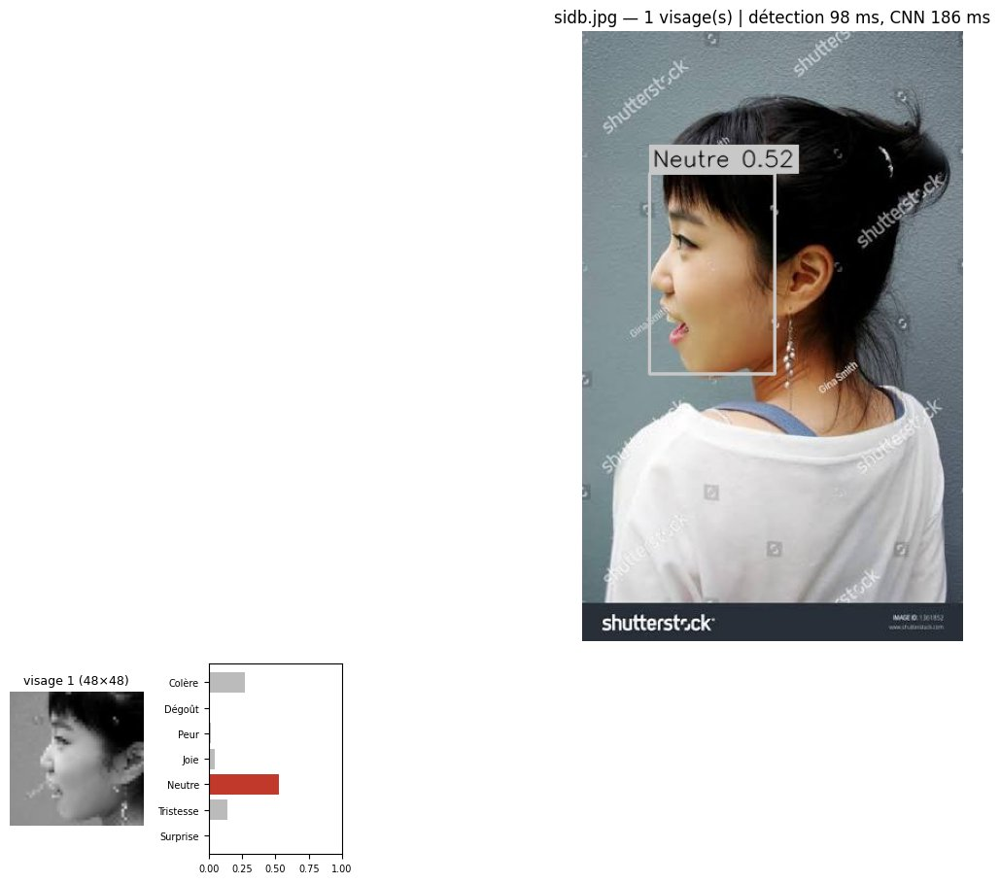

   visage  boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (62, 132, 178, 318)              0.82     Neutre         0.52


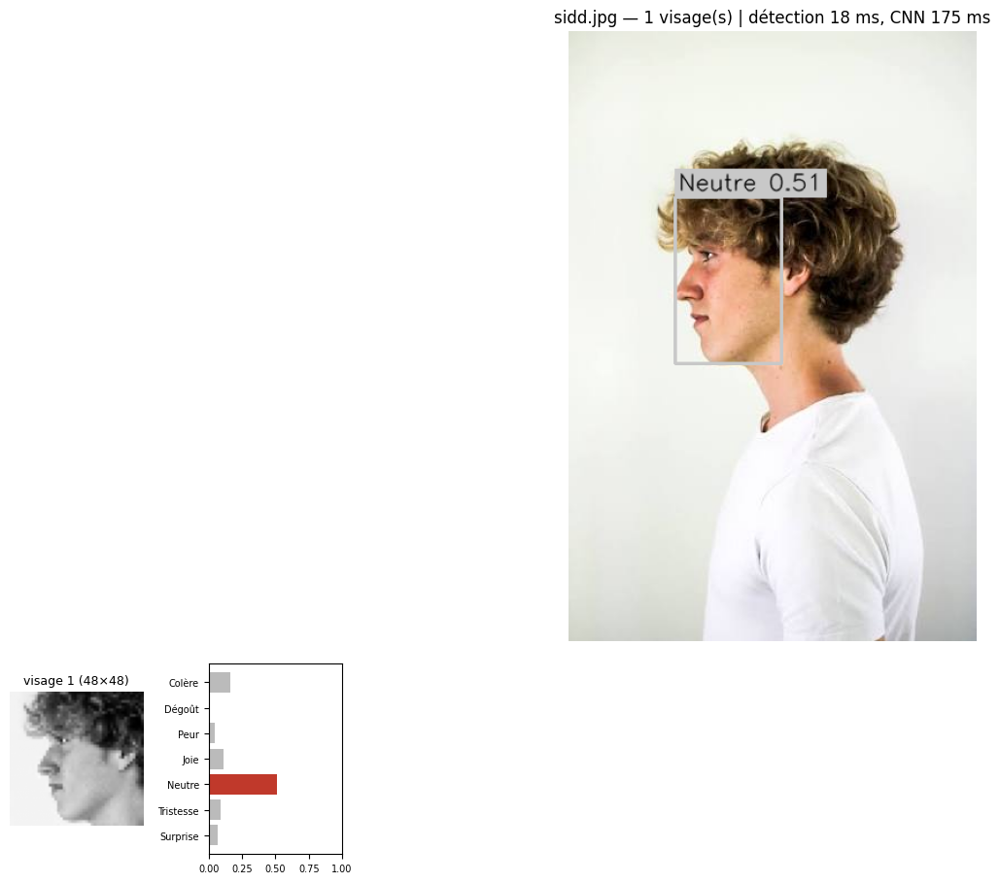

   visage  boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (95, 149, 190, 298)              0.78     Neutre         0.51


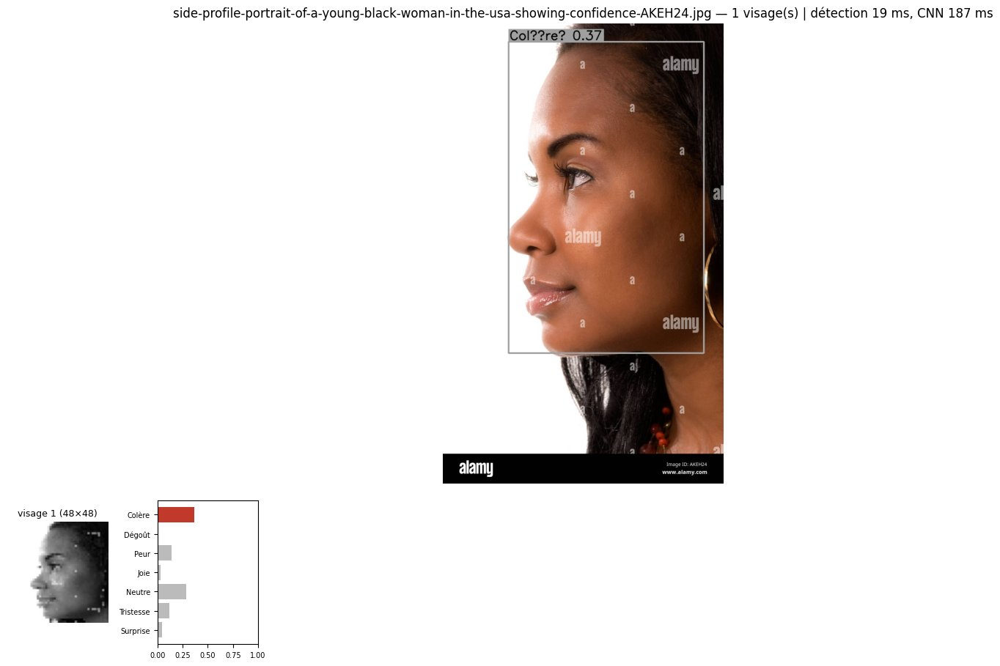

   visage  boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1  (198, 57, 787, 996)              0.82     Colère         0.37


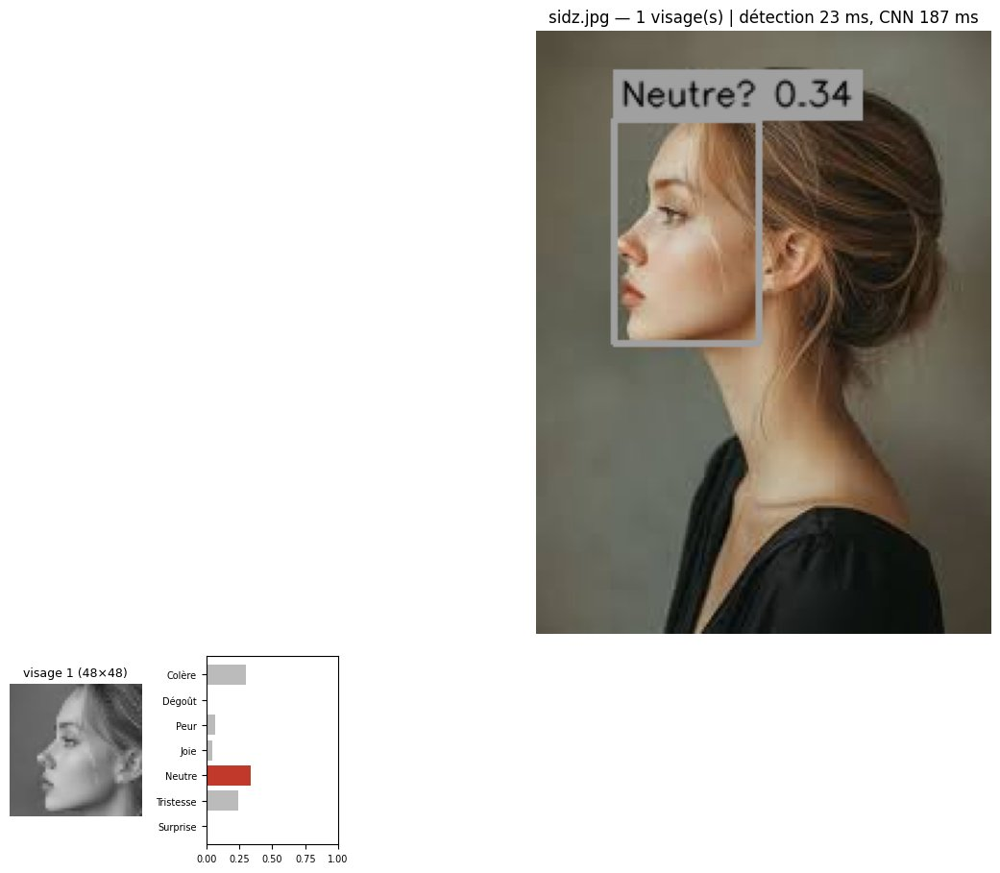

   visage boîte (x1,y1,x2,y2)  confiance visage expression  probabilité
0       1   (33, 38, 95, 134)              0.83     Neutre         0.34


In [12]:
if not user_paths:
    print("Aucune image dans", user_dir, "— ajoutez des photos puis relancez la cellule 8.1 et celle-ci.")
for p in user_paths:
    tab = afficher_analyse(p)
    display(tab) if "display" in globals() else print(tab)

### 8.11 Analyse et limites

Tests réalisés sur les 2 photos de démonstration et sur **28 photos** déposées dans `images_test/` : groupes, foules,
grilles de visages, gros plans et visages de profil. Classifieur utilisé : MobileNetV2 fine-tuné (Partie 7).

**La détection est très fiable**
- YOLOv8n-face trouve les visages dans toutes les photos, y compris dans des foules et des grilles (jusqu'à
  **25 visages** sur une même image), pour de très petits visages et pour des visages de **profil strict**.
- Durée : détection en **14 à 105 ms** par image ; classification de tous les visages d'une image en 107 à 739 ms.
- La vignette 48 × 48 affichée sous chaque photo confirme que le découpage et le prétraitement sont corrects.

**Expressions bien reconnues**
- **Joie** : groupe de cinq jeunes souriants, 3 visages en Joie (0,89 à 0,98) ; groupe de huit hommes souriants,
  6 visages en Joie (0,60 à 0,98) ; grille de 25 visages souriants, 21 en Joie, souvent au-dessus de 0,9.
- **Neutre** : portraits neutres, 5 sur 5 (0,55 à 0,86) ; joueurs d'e-sport, 4 sur 4.
- **Colère** : collègues en colère qui pointent du doigt, **6 visages sur 6** (0,54 à 0,88).
- **Peur** : groupe effrayé (mains sur le visage), 3 visages en Peur (0,79 ; 0,48 ; 0,43).
- **Surprise** : reconnue quand les sourcils sont levés et la bouche en « O » (0,83 et 0,77 sur deux photos).

**Expressions mal reconnues**
- **Surprise prise pour de la Colère** : grille de 8 visages très surpris, bouche grande ouverte : 6 en Colère,
  2 en Peur, **aucun en Surprise**. Une bouche grande ouverte ressemble à un cri.
- **Dégoût pris pour de la Colère** : trois hommes qui semblent dégoûtés (grimace et geste de rejet), classés Colère, Colère et Neutre. C'est
  exactement la confusion observée sur FER-2013 (Partie 5), où Dégoût est très peu représenté.
- **Colère en gros plan** : collage de 7 visages en colère très contrastés, une seule Colère ; le reste en Neutre
  ou Tristesse. Zidane criant (photo de démonstration) est classé Tristesse.
- **Une même personne, 16 expressions** (grille) : 13 visages en Neutre ; le modèle ne distingue que les expressions
  les plus marquées.
- **Pleurs** : prédictions dispersées (Tristesse, Neutre, Colère, Peur), toutes avec une faible confiance.
  Cohérent avec la Partie 5, où Tristesse sert de classe refuge.
- **Profils** : détectés, mais trois femmes de profil (une qui rit, une qui sourit, une au visage calme) sont
  classées Colère (0,44 ; 0,37 ; 0,53) ; les autres profils neutres sont classés Neutre avec une confiance faible
  (0,34 à 0,52).

**Pourquoi**
- **Changement de domaine** : le classifieur a appris sur FER-2013 (visages recadrés, de face, en gris 48 × 48).
  Les photos réelles ont d'autres cadrages, éclairages, angles et niveaux de détail.
- **Performances de base limitées** : même sur FER-2013, MobileNetV2 n'a que 55 % de rappel en Colère, 54 % en
  Surprise et 4,5 % en Dégoût (7.10) ; ces confusions se retrouvent logiquement sur des photos réelles.
- **Petits visages** : la vignette 48 × 48 est obtenue en agrandissant quelques pixels, donc floue.
- **Erreurs en cascade** : un visage de profil ou coupé donne au classifieur une image très différente de celles
  de l'entraînement.

**Pistes d'amélioration** : utiliser le meilleur CNN de la Partie 6 (E1) comme classifieur, fine-tuner le
classifieur sur des visages extraits par YOLO, aligner les visages (yeux horizontaux) avant classification.

In [13]:
# Libère la mémoire avant la Partie 9 (sans recharger TensorFlow)
%reset -f
import gc
gc.collect()
print("Mémoire libérée — début de la Partie 9")

Mémoire libérée — début de la Partie 9


---
## Partie 9 — Extension à la vidéo

Une vidéo n'est qu'une **suite d'images** (25 à 30 par seconde). On applique donc le pipeline de la Partie 8
image par image :

$$\text{Vidéo} \rightarrow \text{images successives} \rightarrow \text{détection} \rightarrow \text{extraction des visages}
\rightarrow \text{CNN} \rightarrow \text{prédictions} \rightarrow \text{affichage}$$

Deux problèmes apparaissent, propres à la vidéo, et nous les traitons :
1. **Suivre chaque personne d'une image à l'autre** (*tracking*) : savoir que le visage n°2 de l'image 51 est le
   même que le visage n°2 de l'image 50 ;
2. **Le scintillement** : la prédiction d'une image isolée peut sauter d'une expression à l'autre (Neutre → Tristesse
   → Neutre) à cause du bruit. On **lisse les probabilités dans le temps**, visage par visage.

**Sources vidéo possibles** (section 9.2) : vos vidéos dans `MyDrive/projet_dl/videos_test/`, un enregistrement
de quelques secondes avec la **webcam** (dans Colab), ou à défaut une courte vidéo de démonstration générée
automatiquement.

> ⚙️ Colab avec GPU. Prérequis : Partie 8 exécutée (le modèle YOLO visages est déjà dans le Drive) et
> `modele_final.keras` (Partie 6).

### 9.0 Installation et chargement

In [14]:
!pip install -q ultralytics lap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.3 MB/s eta 0:00:00


In [23]:
import os, sys
# TensorFlow et YOLO (PyTorch) font planter Python s'ils tournent dans la même session.
# On charge donc notre modèle Keras avec PyTorch comme moteur de calcul, sans TensorFlow.
if "tensorflow" in sys.modules:
    raise SystemExit("TensorFlow est déjà chargé dans cette session : faites « Exécution > Redémarrer la session », "
                     "puis relancez à partir de cette partie.")
os.environ["KERAS_BACKEND"] = "torch"
import keras
import glob, time, json, subprocess, urllib.request
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
from IPython.display import Video, display

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass
SAVE_DIR = "/content/drive/MyDrive/projet_dl" if os.path.isdir("/content/drive/MyDrive") else "."
WORK_DIR = os.path.join(SAVE_DIR, "partie9"); os.makedirs(WORK_DIR, exist_ok=True)
VIDEO_DIR = os.path.join(SAVE_DIR, "videos_test"); os.makedirs(VIDEO_DIR, exist_ok=True)

model_path = os.path.join(SAVE_DIR, "modele_final.keras")
if not os.path.exists(model_path):
    model_path = os.path.join(SAVE_DIR, "cnn_base.keras")
emotion_model = keras.models.load_model(model_path)
IMG_SIZE = emotion_model.input_shape[1]

data = np.load(os.path.join(SAVE_DIR, "fer2013_prepared.npz"))
CLASSES = list(data["classes"])
FR = {"angry": "Colère", "disgust": "Dégoût", "fear": "Peur", "happy": "Joie",
      "neutral": "Neutre", "sad": "Tristesse", "surprise": "Surprise"}
CLASSES_FR = [FR.get(c, c) for c in CLASSES]

FACE_WEIGHTS = os.path.join(SAVE_DIR, "partie8", "yolov8n-face.pt")
if not os.path.exists(FACE_WEIGHTS):
    os.makedirs(os.path.dirname(FACE_WEIGHTS), exist_ok=True)
    urllib.request.urlretrieve("https://github.com/akanametov/yolo-face/releases/download/1.0.0/yolov8n-face.pt", FACE_WEIGHTS)
face_detector = YOLO(FACE_WEIGHTS)
print("Classifieur :", os.path.basename(model_path), "| détecteur :", os.path.basename(FACE_WEIGHTS))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classifieur : modele_final.keras | détecteur : yolov8n-face.pt


### 9.1 Fonctions reprises de la Partie 8

Le prétraitement est **strictement identique** à celui de l'entraînement (niveaux de gris, 48 × 48, /255),
avec la même boîte carrée + marge de 10 % qu'en Partie 8.

In [24]:
def preprocess_face(face_bgr, size=IMG_SIZE):
    gray = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (size, size), interpolation=cv2.INTER_LINEAR)
    return (gray.astype(np.float32) / 255.0)[..., np.newaxis]

def square_box(x1, y1, x2, y2, img_w, img_h, margin=0.10):
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    side = max(x2 - x1, y2 - y1) * (1 + margin)
    return (int(max(0, cx - side / 2)), int(max(0, cy - side / 2)),
            int(min(img_w, cx + side / 2)), int(min(img_h, cy + side / 2)))

COLORS = {"Joie": (60, 180, 75), "Surprise": (0, 200, 255), "Neutre": (200, 200, 200), "Tristesse": (200, 120, 40),
          "Colère": (40, 40, 220), "Peur": (180, 60, 160), "Dégoût": (40, 140, 140)}
UNCERTAIN = 0.40

def draw_face(img, box, track_id, expression, proba):
    x1, y1, x2, y2 = box
    scale = max(img.shape[:2]) / 1000
    uncertain = proba < UNCERTAIN
    color = (160, 160, 160) if uncertain else COLORS.get(expression, (255, 255, 255))
    text = f"#{track_id} {expression}{'?' if uncertain else ''} {proba:.2f}"
    th = max(1, int(2 * scale)); fs = 0.6 * scale + 0.3
    cv2.rectangle(img, (x1, y1), (x2, y2), color, max(2, int(3 * scale)))
    (tw, tht), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, fs, th)
    cv2.rectangle(img, (x1, max(0, y1 - tht - 10)), (x1 + tw + 6, y1), color, -1)
    cv2.putText(img, text, (x1 + 3, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, fs, (0, 0, 0), th, cv2.LINE_AA)

### 9.2 Choix de la vidéo

Trois possibilités, par ordre de priorité :
1. **vos vidéos** (`.mp4`, `.mov`, `.avi`, `.webm`) déposées dans `MyDrive/projet_dl/videos_test/` ;
2. **enregistrement webcam** : passer `ENREGISTRER_WEBCAM = True` dans la cellule suivante (Colab demandera l'accès
   à la caméra ; faites plusieurs expressions devant l'objectif, à plusieurs si possible) ;
3. sinon, une **vidéo de démonstration** est générée à partir d'une photo de la Partie 8 (zoom et déplacement
   de caméra simulés) : elle permet de tester la chaîne complète, mais les expressions n'y changent pas.

Conseil pour la soutenance : enregistrez une vidéo de 10 à 20 secondes avec les membres du groupe faisant des
expressions bien marquées, et gardez le résultat annoté comme **démonstration de secours** si le direct échoue.

In [25]:
ENREGISTRER_WEBCAM = False      # mettre True pour enregistrer avec la webcam (dans Colab uniquement)
DUREE_WEBCAM = 10               # secondes

def record_webcam(seconds, out_path):
    from IPython.display import Javascript
    from google.colab.output import eval_js
    from base64 import b64decode
    display(Javascript('''
    async function recordVideo(ms) {
      const div = document.createElement('div');
      const label = document.createElement('p');
      label.textContent = 'Enregistrement en cours... faites des expressions !';
      const video = document.createElement('video');
      video.style.width = '480px';
      div.appendChild(label); div.appendChild(video); document.body.appendChild(div);
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream; video.muted = true; await video.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      const recorder = new MediaRecorder(stream);
      const chunks = [];
      recorder.ondataavailable = e => chunks.push(e.data);
      const stopped = new Promise(r => recorder.onstop = r);
      recorder.start();
      await new Promise(r => setTimeout(r, ms));
      recorder.stop(); await stopped;
      stream.getTracks().forEach(t => t.stop()); div.remove();
      const bytes = new Uint8Array(await new Blob(chunks, {type: 'video/webm'}).arrayBuffer());
      let binary = '';
      for (let i = 0; i < bytes.length; i += 8192) binary += String.fromCharCode.apply(null, bytes.subarray(i, i + 8192));
      return btoa(binary);
    }'''))
    raw = out_path.replace(".mp4", ".webm")
    with open(raw, "wb") as f:
        f.write(b64decode(eval_js(f"recordVideo({int(seconds * 1000)})")))
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", raw, "-r", "25", out_path], check=True)
    return out_path

def make_demo_video(out_path, seconds=6, fps=25, size=(960, 540)):
    # Vidéo de démonstration : zoom + travelling sur une photo de la Partie 8
    src = os.path.join(SAVE_DIR, "partie8", "zidane.jpg")
    if not os.path.exists(src):
        urllib.request.urlretrieve("https://github.com/ultralytics/assets/releases/download/v0.0.0/zidane.jpg", src)
    img = cv2.imread(src); H, W = img.shape[:2]
    writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, size)
    n = seconds * fps
    for i in range(n):
        t = i / (n - 1)
        zoom = 1.0 + 0.35 * np.sin(np.pi * t)                       # zoom avant puis arrière
        cw, ch = int(W / zoom), int(H / zoom)
        x0 = int((W - cw) * (0.5 + 0.4 * np.sin(2 * np.pi * t)))     # travelling horizontal
        y0 = int((H - ch) * 0.3)
        frame = cv2.resize(img[y0:y0 + ch, x0:x0 + cw], size)
        noise = np.random.default_rng(i).normal(0, 4, frame.shape)  # léger bruit de capteur
        writer.write(np.clip(frame + noise, 0, 255).astype(np.uint8))
    writer.release()
    return out_path

videos = sorted(p for ext in ("*.mp4", "*.mov", "*.avi", "*.webm", "*.MOV", "*.MP4") for p in glob.glob(os.path.join(VIDEO_DIR, ext)))
if ENREGISTRER_WEBCAM:
    videos.insert(0, record_webcam(DUREE_WEBCAM, os.path.join(VIDEO_DIR, f"webcam_{int(time.time())}.mp4")))
if not videos:
    videos = [make_demo_video(os.path.join(WORK_DIR, "demo_zidane.mp4"))]
    print("Aucune vidéo fournie : vidéo de démonstration générée.")
VIDEO_PATH = videos[0]

cap = cv2.VideoCapture(VIDEO_PATH)
FPS = cap.get(cv2.CAP_PROP_FPS) or 25
N_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W, H = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"Vidéo : {os.path.basename(VIDEO_PATH)} | {W}×{H} | {FPS:.1f} images/s | {N_FRAMES} images "
      f"({N_FRAMES / FPS:.1f} s)")
print("Autres vidéos disponibles :", [os.path.basename(v) for v in videos[1:]] or "aucune")

Vidéo : Face Test.mp4 | 1920×1080 | 25.0 images/s | 1348 images (53.9 s)
Autres vidéos disponibles : ['The 7 basic emotions - Do you recognise all facial expressions.mp4']


### 9.3 Suivi des visages d'une image à l'autre (tracking)

En Partie 8, YOLO numérote les visages arbitrairement dans chaque image. En vidéo, on utilise le **suivi**
intégré à Ultralytics (`model.track`, algorithme **ByteTrack**) : il associe chaque nouvelle détection à un
visage déjà suivi, en prédisant où chaque boîte devrait se trouver dans l'image suivante et en comparant les
positions (IoU, cf. Partie 8). Chaque visage garde ainsi un **identifiant stable** (`#1`, `#2`…) tant qu'il reste visible.

### 9.4 Lissage temporel des prédictions

Une expression dure bien plus qu'une image (1/25ᵉ de seconde) : la prédiction ne devrait pas changer à chaque
image. Pour chaque visage suivi, on lisse les probabilités par une **moyenne mobile exponentielle** :

$$\bar{p}_t = \alpha \, p_t + (1 - \alpha)\, \bar{p}_{t-1}$$

- $p_t$ : les 7 probabilités du CNN sur l'image $t$ ; $\bar{p}_t$ : les probabilités lissées affichées ;
- $\alpha = 0{,}3$ : chaque nouvelle image compte pour 30 % ; l'affichage réagit en quelques dixièmes de seconde
  à un vrai changement d'expression, mais ignore les sauts isolés ;
- $\bar{p}_t$ reste une distribution de probabilités (somme = 1).

In [26]:
ALPHA = 0.3            # coefficient de lissage
DET_CONF = 0.5         # seuil de confiance de la détection
MAX_WIDTH = 1280       # les vidéos plus larges sont réduites (vitesse)

def analyser_video(video_path, out_path, alpha=ALPHA, det_conf=DET_CONF):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    s = min(1.0, MAX_WIDTH / w); w, h = int(w * s), int(h * s)
    writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    smoothed, log, timings, frame_idx = {}, [], [], 0
    face_detector.predictor = None                 # réinitialise le tracker entre deux vidéos
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if s < 1:
            frame = cv2.resize(frame, (w, h))
        t0 = time.time()
        res = face_detector.track(frame, conf=det_conf, persist=True, tracker="bytetrack.yaml", verbose=False)[0]
        boxes = res.boxes.xyxy.cpu().numpy() if len(res.boxes) else np.zeros((0, 4))
        ids = res.boxes.id.int().cpu().numpy() if res.boxes.id is not None else np.arange(len(boxes)) + 1000
        faces, keep = [], []
        for b, tid in zip(boxes, ids):
            x1, y1, x2, y2 = square_box(*b, w, h)
            crop = frame[y1:y2, x1:x2]
            if crop.size:
                faces.append(preprocess_face(crop)); keep.append((b.astype(int), int(tid)))
        if faces:
            probas = keras.ops.convert_to_numpy(emotion_model(np.stack(faces), training=False))   # plus rapide que predict() pour un petit lot
            for (b, tid), p in zip(keep, probas):
                smoothed[tid] = p if tid not in smoothed else alpha * p + (1 - alpha) * smoothed[tid]
                ps = smoothed[tid]; k = int(ps.argmax())
                draw_face(frame, tuple(b), tid, CLASSES_FR[k], float(ps[k]))
                log.append({"image": frame_idx, "temps (s)": frame_idx / fps, "id": tid,
                            **{f"brut_{c}": float(v) for c, v in zip(CLASSES_FR, p)},
                            **{f"lisse_{c}": float(v) for c, v in zip(CLASSES_FR, ps)},
                            "expression brute": CLASSES_FR[int(p.argmax())], "expression lissée": CLASSES_FR[k]})
        timings.append(time.time() - t0)
        cv2.putText(frame, f"{frame_idx / fps:5.1f} s | {len(keep)} visage(s)", (10, h - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
        writer.write(frame)
        frame_idx += 1
    cap.release(); writer.release()
    return pd.DataFrame(log), np.array(timings), fps

out_raw = os.path.join(WORK_DIR, "annotee_" + os.path.splitext(os.path.basename(VIDEO_PATH))[0] + ".mp4")
t0 = time.time()
log, timings, fps = analyser_video(VIDEO_PATH, out_raw)
print(f"{len(timings)} images traitées en {time.time() - t0:.1f} s")
print(f"Temps moyen par image (détection + suivi + CNN) : {1000 * timings.mean():.0f} ms "
      f"-> {1 / timings.mean():.1f} images/s (la vidéo en a {fps:.0f})")
print(f"Visages suivis : {sorted(log['id'].unique()) if len(log) else 'aucun'}")

1348 images traitées en 197.4 s
Temps moyen par image (détection + suivi + CNN) : 131 ms -> 7.6 images/s (la vidéo en a 25)
Visages suivis : [np.int64(1)]


### 9.5 Vidéo annotée

OpenCV écrit la vidéo avec un codec que les navigateurs ne lisent pas toujours : on la convertit en H.264 avec
`ffmpeg` pour l'afficher ici. Le fichier est enregistré dans `MyDrive/projet_dl/partie9/`.

In [27]:
out_h264 = out_raw.replace(".mp4", "_h264.mp4")
subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", out_raw, "-vcodec", "libx264",
                "-pix_fmt", "yuv420p", "-crf", "26", out_h264], check=True)
print("Vidéo annotée :", out_h264, f"({os.path.getsize(out_h264) / 1e6:.1f} Mo)")
display(Video(out_h264, embed=True, width=800))

Vidéo annotée : /content/drive/MyDrive/projet_dl/partie9/annotee_Face Test_h264.mp4 (2.7 Mo)


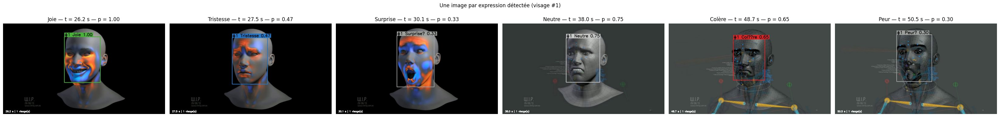

In [31]:
# Une image de la vidéo annotée pour chaque expression détectée (utile pour la présentation)
if len(log):
    main_id = log["id"].value_counts().index[0]                 # le visage suivi le plus longtemps
    d = log[log["id"] == main_id]
    picks = []
    for e in d["expression lissée"].unique():                    # expressions affichées au moins une fois
        de = d[d["expression lissée"] == e]
        best = de.loc[de[f"lisse_{e}"].idxmax()]                 # moment où cette expression est la plus sûre
        picks.append((e, int(best["image"]), float(best[f"lisse_{e}"])))
    picks.sort(key=lambda t: t[1])                               # ordre chronologique
    cap = cv2.VideoCapture(out_h264)
    fig, axes = plt.subplots(1, len(picks), figsize=(5.5 * len(picks), 4.2), squeeze=False)
    for ax, (e, k, p) in zip(axes[0], picks):
        cap.set(cv2.CAP_PROP_POS_FRAMES, k); ok, fr = cap.read()
        if ok:
            ax.imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{e} — t = {k / fps:.1f} s — p = {p:.2f}"); ax.axis("off")
    cap.release()
    plt.suptitle(f"Une image par expression détectée (visage #{main_id})"); plt.tight_layout(); plt.show()
else:
    print("Aucun visage détecté dans la vidéo.")

### 9.6 Évolution des expressions dans le temps et effet du lissage

Pour chaque visage suivi, on trace la probabilité de chaque expression au cours de la vidéo.
En haut : prédictions **brutes** image par image ; en bas : prédictions **lissées**.

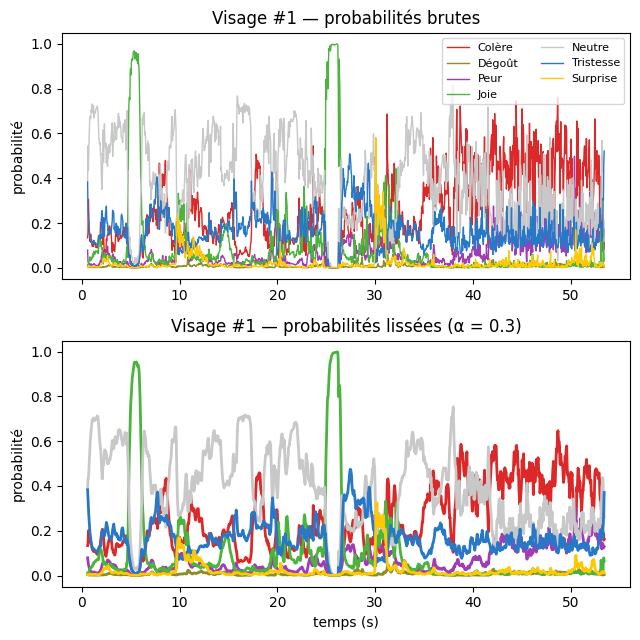

,durée suivie (s),changements d'expression (brut),changements d'expression (lissé),expression dominante
id,,,,
1,52.8,197,65,Neutre


In [32]:
if len(log):
    main_ids = log["id"].value_counts().index[:3]          # les 3 visages suivis le plus longtemps
    colors = {c: np.array(COLORS[c][::-1]) / 255 for c in CLASSES_FR}
    fig, axes = plt.subplots(2, len(main_ids), figsize=(6.5 * len(main_ids), 6.5), squeeze=False, sharey=True)
    for j, tid in enumerate(main_ids):
        d = log[log["id"] == tid]
        for c in CLASSES_FR:
            axes[0, j].plot(d["temps (s)"], d[f"brut_{c}"], color=colors[c], lw=1, label=c)
            axes[1, j].plot(d["temps (s)"], d[f"lisse_{c}"], color=colors[c], lw=2, label=c)
        axes[0, j].set_title(f"Visage #{tid} — probabilités brutes")
        axes[1, j].set_title(f"Visage #{tid} — probabilités lissées (α = {ALPHA})")
        axes[1, j].set_xlabel("temps (s)")
    axes[0, 0].legend(fontsize=8, ncol=2); axes[0, 0].set_ylabel("probabilité"); axes[1, 0].set_ylabel("probabilité")
    plt.tight_layout(); plt.show()

    changes = log.sort_values("image").groupby("id").agg(
        **{"durée suivie (s)": ("temps (s)", lambda t: t.max() - t.min()),
           "changements d'expression (brut)": ("expression brute", lambda s: int((s != s.shift()).sum() - 1)),
           "changements d'expression (lissé)": ("expression lissée", lambda s: int((s != s.shift()).sum() - 1)),
           "expression dominante": ("expression lissée", lambda s: s.value_counts().index[0])})
    display(changes.round(1)) if "display" in globals() else print(changes)
else:
    print("Aucun visage détecté dans la vidéo.")

Le nombre de **changements d'expression affichés** baisse nettement avec le lissage : l'affichage est plus
stable et plus lisible, sans masquer les vrais changements d'expression (qui durent plusieurs dixièmes de seconde).

### 9.7 Bilan de la vidéo : répartition des expressions

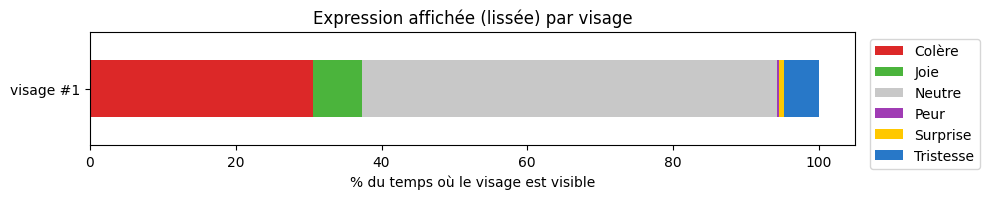

Prédictions image par image enregistrées dans /content/drive/MyDrive/projet_dl/partie9/predictions_video.csv


In [33]:
if len(log):
    dist = (pd.crosstab(log["id"], log["expression lissée"], normalize="index") * 100).round(1)
    dist.index = [f"visage #{i}" for i in dist.index]
    ax = dist.plot(kind="barh", stacked=True, figsize=(10, 0.6 * len(dist) + 1.5),
                   color=[np.array(COLORS[c][::-1]) / 255 for c in dist.columns])
    ax.set_xlabel("% du temps où le visage est visible"); ax.set_title("Expression affichée (lissée) par visage")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); plt.tight_layout(); plt.show()
    log.to_csv(os.path.join(WORK_DIR, "predictions_video.csv"), index=False)
    print("Prédictions image par image enregistrées dans", os.path.join(WORK_DIR, "predictions_video.csv"))

### 9.8 Analyse et limites

**La vidéo testée** : *Face Test.mp4*, 53,9 s, 1920 × 1080 (réduite à 1280 × 720 pour le traitement), 25 images/s,
soit 1 348 images. Il s'agit d'une **tête de synthèse en 3D** animée, qui enchaîne différentes expressions : en
couleurs (ombrage orange et bleu) dans la première moitié, puis en gris, avec un maillage d'animation superposé,
dans la seconde moitié. La seconde vidéo du dossier (*The 7 basic emotions…*) n'a pas été analysée : le notebook
traite la première vidéo de la liste.

**Suivi** : un seul identifiant (#1) pendant 52,8 s : ByteTrack n'a jamais perdu ni renuméroté le visage, malgré les
changements de rendu.

**Expressions affichées** (courbes 9.6 et bilan 9.7)
- Répartition du temps : **Neutre ≈ 57 %**, **Colère ≈ 31 %**, Joie ≈ 7 %, Tristesse ≈ 5 %, Surprise et Peur
  moins de 1 % chacune.
- **Joie** : deux pics très nets, vers 5 s (≈ 0,95) et vers 26 s (**1,00**). À 26 s, la tête affiche un grand
  sourire : la reconnaissance est franche et correcte.
- **Colère** : dominante de ≈ 40 s à la fin (probabilité 0,4 à 0,6), sur la partie grise avec maillage ; l'image
  extraite à 48,7 s montre bien des sourcils froncés (0,65).
- **Tristesse** à 27,5 s (0,47) : sourcils froncés, bouche tombante.
- **Surprise** à 30,1 s : seulement 0,33 (marquée « ? »), alors que la bouche est grande ouverte ; comme sur les
  photos, une bouche grande ouverte est ambiguë entre surprise, peur et colère.
- **À 38 s**, le visage semble triste (sourcils relevés au centre, coins de la bouche tombants) mais il est classé
  **Neutre** avec 0,75 : la tristesse marquée sur un visage de synthèse n'est pas reconnue.
- **Peur** n'apparaît qu'une fois, avec une confiance faible (0,30).

**Effet du lissage** : sans lissage, l'expression prédite change **197 fois** en 52,8 s ; avec le lissage
(α = 0,3), **65 fois**, soit 3 fois moins. L'affichage reste toutefois instable : sur une grande partie de la vidéo,
les probabilités de Neutre et de Colère sont proches (0,3 à 0,5) et se croisent sans cesse. Un lissage plus fort
(α ≈ 0,1) ou un seuil de changement (ne changer d'expression que si la nouvelle dépasse l'ancienne d'une marge)
stabiliserait l'affichage.

**Performances** : **131 ms par image**, soit **7,6 images/s** pour une vidéo à 25 images/s : le système ne
fonctionne **pas en temps réel** (environ 3 fois trop lent ; 197 s de calcul pour 54 s de vidéo). Le coût principal
est la classification par MobileNetV2. Pour approcher le temps réel : utiliser notre petit CNN (E1) à la place, ne
traiter qu'une image sur 3, ou réduire la résolution.

**Limites**
- **Visage de synthèse** : textures, éclairage et maillage superposé sont très éloignés des photos de FER-2013 ;
  c'est un cas extrême de changement de domaine, qui explique sans doute une partie des hésitations.
- expressions intermédiaires (transitions entre deux expressions) : probabilités proches, donc changements fréquents ;
- flou de bougé et tête qui tourne : le modèle, entraîné sur des visages de face nets, se trompe davantage ;
- quand un visage disparaît puis réapparaît, le tracker peut lui donner un nouvel identifiant ;
- le lissage introduit un léger retard (≈ 0,2 à 0,3 s avec α = 0,3) : α est un compromis entre réactivité et stabilité.

---
## Fin du notebook

Fichiers produits dans `MyDrive/projet_dl/` : données préparées, modèles (`modele_reference.keras`, `cnn_base.keras`,
`experiences/`, `partie7/`, `modele_final.keras`), tableaux de résultats (CSV), images annotées (`partie8/`) et
vidéo annotée (`partie9/`).
